# 02 — Image Preprocessing

**Origin:** Existing Notebook 02  
**Refactor status:** In progress  
**Validation status:** Pending  
**Completion gate passed:** No  
**Output root:** `outputs/02_image_preprocessing/`  
**Depends on:** Notebook 01 — Dataset Verification

## Purpose

Create standardized clean reference images and authoritative painting-content geometry for every accepted artwork.

This notebook will:

- produce deterministic 768 × 768 RGB PNG images;
- preserve source-image aspect ratio without cropping or distortion;
- use source-pixel median RGB padding;
- record exclusive-maximum content bounding boxes;
- record source dimensions, resize scale, resized dimensions, and all padding values;
- preserve one clean reference image per accepted painting;
- enforce the EXIF-orientation and ICC-profile policies justified by Notebook 01;
- reload and verify every saved image;
- detect missing, stale, duplicate, and orphaned outputs;
- calculate content and padding areas;
- record preprocessing runtime evidence;
- render representative before/after/padding previews;
- persist normalized tables, manifests, and consolidated validation evidence.

## Scope

The current execution profile is `controlled_50`.

The implementation is configuration-driven through `config/preprocessing/canonical_768.yaml`. Scaling to another approved dataset profile must use the same preprocessing implementation with a separately validated configuration.

## Colour and orientation policy

Notebook 01 established that:

- all 50 accepted source images use EXIF orientation `1`;
- 14 images contain an embedded sRGB profile;
- 36 images have no embedded ICC profile;
- no accepted image has a known non-sRGB profile.

Therefore:

- non-default EXIF orientation is blocking;
- missing ICC profiles are treated as sRGB without pixel conversion;
- embedded sRGB pixel values are preserved without conversion;
- non-sRGB profiles are blocking;
- output PNG metadata is stripped to produce deterministic model inputs.

## Exclusions

This notebook does not:

- modify source images;
- crop painting content;
- distort aspect ratios;
- generate damage masks or damaged images;
- run restoration models;
- compute restoration-quality metrics;
- propagate descriptive artwork metadata into the normalized preprocessing table;
- claim that technical preprocessing establishes historical or conservation validity.

Descriptive metadata remains owned by `artworks.v1` and is joined downstream through `painting_id`.

## Coordinate convention

All content bounding boxes use zero-based `xyxy` coordinates with exclusive maximum values:

```text
(content_x_min, content_y_min, content_x_max, content_y_max)
```

This convention is enforced through the canonical region helper.

## Batch 1 — Bootstrap, Contracts, and Output Preflight

This batch:
- initializes the notebook execution identity;
- loads the approved preprocessing configuration;
- resolves the explicit Notebook 01 handoff paths;
- loads the current project inventory and artifact registry;
- declares the complete input and output contracts;
- performs exactly 10 consolidated preflight checks;
- rejects legacy, stale, or incorrectly owned outputs;
- creates only the required Notebook 02 output directories.

No scientific artifact is written in this batch.

In [1]:
### Cell 2 — Code

from pathlib import Path
import json
import platform
import re
import sys

import pandas as pd
import PIL
import yaml


# ---------------------------------------------------------------------------
# Minimal import bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_CANDIDATES = [
    CURRENT_DIRECTORY,
    *CURRENT_DIRECTORY.parents,
]

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in PROJECT_ROOT_CANDIDATES
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    PROJECT_PATHS_MARKDOWN_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.preprocessing import (
    PREPROCESSING_CONFIG_SCHEMA_VERSION,
    PREPROCESSING_MODULE_VERSION,
    load_preprocessing_config,
    resolve_preprocessing_inputs,
    validate_preprocessing_config,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    ARTWORKS_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    PREPROCESSING_AUDIT_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "02"
NOTEBOOK_STEM = "02_image_preprocessing"
NOTEBOOK_NAME = "Image Preprocessing"
ORIGIN = "Existing Notebook 02"

UPSTREAM_NOTEBOOK_STEM = "01_dataset_verification"

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "regions": REGIONS_MODULE_VERSION,
    "preprocessing": PREPROCESSING_MODULE_VERSION,
}

print("Notebook:", f"{NOTEBOOK_ID} — {NOTEBOOK_NAME}")
print("Repository root:", PROJECT_ROOT)
print("Run started:", RUN_STARTED_AT_UTC)
print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("Pillow:", PIL.__version__)
print("PyYAML:", yaml.__version__)

Notebook: 02 — Image Preprocessing
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-17T13:20:20.968813Z
Python: 3.12.6
pandas: 2.3.3
Pillow: 9.5.0
PyYAML: 6.0.3


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and explicit upstream paths
# ---------------------------------------------------------------------------

PREPROCESSING_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "preprocessing"
    / "canonical_768.yaml"
)

preprocessing_config = load_preprocessing_config(
    PREPROCESSING_CONFIG_PATH
)

preprocessing_input_paths = resolve_preprocessing_inputs(
    preprocessing_config,
    PROJECT_ROOT,
    must_exist=True,
)

UPSTREAM_ARTWORKS_PATH = preprocessing_input_paths[
    "artworks_path"
]

UPSTREAM_ARTIFACT_MANIFEST_PATH = preprocessing_input_paths[
    "artifacts_path"
]

UPSTREAM_RUN_MANIFEST_PATH = preprocessing_input_paths[
    "run_manifest_path"
]

RAW_IMAGE_DIRECTORY = PROJECT_ROOT / "data" / "raw" / "images"

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "02_image_preprocessing.ipynb"
)


# ---------------------------------------------------------------------------
# Current inventory and global artifact registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_run_file:
    inventory_run = json.load(inventory_run_file)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

CLEAN_IMAGE_DIRECTORY = (
    OUTPUT_ROOT
    / preprocessing_config["output"]["image_directory"]
)

OUTPUT_PATHS = {
    "preprocessed_images": (
        OUTPUT_ROOT
        / preprocessing_config["output"]["table_path"]
    ),
    "clean_images": CLEAN_IMAGE_DIRECTORY,
    "preprocessing_audit": (
        OUTPUT_ROOT
        / preprocessing_config["output"]["audit_path"]
    ),
    "preprocessing_preview": (
        OUTPUT_ROOT
        / preprocessing_config["output"]["preview_path"]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / "validation"
        / "checks.csv"
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "artifacts.csv"
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / "manifests"
        / "run_manifest.json"
    ),
}

POST_GATE_PATHS = {
    "project_paths_json": PROJECT_PATHS_JSON_PATH,
    "project_paths_markdown": PROJECT_PATHS_MARKDOWN_PATH,
}


# ---------------------------------------------------------------------------
# Complete explicit input contract
# ---------------------------------------------------------------------------

EXPECTED_PAINTING_COUNT = int(
    preprocessing_config["expected"]["accepted_input_count"]
)

INPUTS = {
    "preprocessing_config": {
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            PREPROCESSING_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": PREPROCESSING_CONFIG_SCHEMA_VERSION,
        "expected_cardinality": 1,
    },
    "upstream_artworks": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_ARTWORKS_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": ARTWORKS_SCHEMA.version,
        "expected_cardinality": EXPECTED_PAINTING_COUNT,
    },
    "upstream_artifact_manifest": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_ARTIFACT_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "expected_cardinality": 5,
    },
    "upstream_run_manifest": {
        "producer": UPSTREAM_NOTEBOOK_STEM,
        "relative_path": to_repo_relative(
            UPSTREAM_RUN_MANIFEST_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
    },
    "raw_images": {
        "producer": "source dataset via artworks.raw_image_path",
        "relative_path": to_repo_relative(
            RAW_IMAGE_DIRECTORY,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "jpeg_collection",
        "schema_version": "raw_image_collection.v1",
        "expected_cardinality": EXPECTED_PAINTING_COUNT,
    },
    "project_inventory": {
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            PROJECT_FILE_INVENTORY_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": "project_file_inventory.v1",
        "expected_cardinality": int(len(inventory_df)),
    },
    "inventory_run": {
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INVENTORY_RUN_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "expected_cardinality": 1,
    },
    "project_paths_registry": {
        "producer": "validated notebook handoffs",
        "relative_path": to_repo_relative(
            PROJECT_PATHS_JSON_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "expected_cardinality": 1,
    },
}


# ---------------------------------------------------------------------------
# Complete explicit output contract
# ---------------------------------------------------------------------------

OUTPUTS = {
    "preprocessed_images": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["preprocessed_images"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "expected_cardinality": EXPECTED_PAINTING_COUNT,
        "artifact_role": "primary_downstream",
    },
    "clean_images": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["clean_images"],
            PROJECT_ROOT,
        ),
        "format": "png_collection",
        "schema_version": "clean_image_collection.v1",
        "expected_cardinality": EXPECTED_PAINTING_COUNT,
        "artifact_role": "primary_downstream",
    },
    "preprocessing_audit": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["preprocessing_audit"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": PREPROCESSING_AUDIT_SCHEMA.version,
        "expected_cardinality": int(
            preprocessing_config["expected"]["audit_row_count"]
        ),
        "artifact_role": "audit_reporting",
    },
    "preprocessing_preview": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["preprocessing_preview"],
            PROJECT_ROOT,
        ),
        "format": "png",
        "schema_version": "figure.preprocessing_preview.v1",
        "expected_cardinality": 1,
        "artifact_role": "qa_reporting",
    },
    "validation_checks": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["validation_checks"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "expected_cardinality": 50,
        "artifact_role": "validation",
    },
    "artifact_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["artifact_manifest"],
            PROJECT_ROOT,
        ),
        "format": "csv",
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "expected_cardinality": 5,
        "artifact_role": "handoff",
    },
    "run_manifest": {
        "relative_path": to_repo_relative(
            OUTPUT_PATHS["run_manifest"],
            PROJECT_ROOT,
        ),
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
        "artifact_role": "reproducibility",
    },
}

print(
    "Dataset scope:",
    preprocessing_config["dataset"]["dataset_scope"],
)
print(
    "Execution profile:",
    preprocessing_config["dataset"]["execution_profile"],
)
print(
    "Preprocessing version:",
    preprocessing_config["processing"]["version"],
)
print("Inventory run:", inventory_run["inventory_run_id"])
print("Inventory records:", len(inventory_df))
print(
    "Registered upstream artifacts:",
    len(project_paths_registry["artifacts"]),
)
print("Notebook output root:", OUTPUT_ROOT)

Dataset scope: controlled_50
Execution profile: controlled_50
Preprocessing version: 2.0.0
Inventory run: inventory_20260817T130843Z_7e450297
Inventory records: 10974
Registered upstream artifacts: 5
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\02_image_preprocessing


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 preflight validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


# 1. Repository root

root_passed = (
    (PROJECT_ROOT / ".git").exists()
    and (PROJECT_ROOT / "src" / "restoration_eval").is_dir()
    and (PROJECT_ROOT / "notebooks").is_dir()
    and NOTEBOOK_PATH.is_file()
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="project_root",
    check_description=(
        "Repository root and the correctly named Notebook 02 file exist."
    ),
    severity="blocking",
    expected=True,
    observed=root_passed,
    passed=root_passed,
    details=to_repo_relative(NOTEBOOK_PATH, PROJECT_ROOT),
)


# 2. Python version

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

python_version_passed = (
    python_minor in SUPPORTED_PYTHON_MINORS
)

python_version_details = (
    "Python 3.11 is the provisional project default."
    if python_minor == (3, 11)
    else (
        "Python 3.12 is conditionally permitted; compatibility "
        "will continue to be verified during execution."
        if python_minor == (3, 12)
        else "Unsupported Python minor version."
    )
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="python_version",
    check_description=(
        "Python minor version is supported for Notebook 02."
    ),
    severity=(
        "warning"
        if python_minor == (3, 12)
        else "blocking"
    ),
    expected="3.11 provisional; 3.12 conditionally permitted",
    observed=platform.python_version(),
    passed=python_version_passed,
    details=python_version_details,
)


# 3. Preprocessing configuration

preprocessing_config_errors = validate_preprocessing_config(
    preprocessing_config
)

preprocessing_config_passed = (
    not preprocessing_config_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="preprocessing_config",
    check_description=(
        "Canonical preprocessing configuration satisfies "
        "preprocessing_config.v1."
    ),
    severity="blocking",
    expected="zero configuration errors",
    observed=len(preprocessing_config_errors),
    passed=preprocessing_config_passed,
    details=preprocessing_config_errors,
)


# 4. Inventory run and schema consistency

required_inventory_columns = {
    "inventory_schema_version",
    "inventory_run_id",
    "relative_path",
    "file_kind",
    "format",
    "size_bytes",
    "hash_mode",
    "hash_algorithm",
    "hash_value",
    "read_error_count",
}

missing_inventory_columns = sorted(
    required_inventory_columns
    - set(inventory_df.columns)
)

inventory_run_ids = (
    set(
        inventory_df["inventory_run_id"]
        .dropna()
        .astype(str)
    )
    if "inventory_run_id" in inventory_df.columns
    else set()
)

inventory_read_error_count = int(
    pd.to_numeric(
        inventory_df.get(
            "read_error_count",
            pd.Series(dtype="float64"),
        ),
        errors="coerce",
    )
    .fillna(0)
    .sum()
)

inventory_run_passed = (
    inventory_run.get("status") == "completed"
    and inventory_run.get(
        "inventory_schema_version"
    ) == "project_file_inventory.v1"
    and inventory_run.get(
        "run_schema_version"
    ) == "inventory_run.v1"
    and inventory_run_ids
    == {inventory_run["inventory_run_id"]}
    and not missing_inventory_columns
    and inventory_read_error_count == 0
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_run",
    check_description=(
        "Inventory run is completed, internally consistent, "
        "and contains no recorded read errors."
    ),
    severity="blocking",
    expected={
        "status": "completed",
        "inventory_schema": "project_file_inventory.v1",
        "run_schema": "inventory_run.v1",
        "read_errors": 0,
    },
    observed={
        "status": inventory_run.get("status"),
        "inventory_schema": inventory_run.get(
            "inventory_schema_version"
        ),
        "run_schema": inventory_run.get(
            "run_schema_version"
        ),
        "inventory_run_ids": sorted(inventory_run_ids),
        "missing_columns": missing_inventory_columns,
        "read_errors": inventory_read_error_count,
    },
    passed=inventory_run_passed,
)


# 5. Inventory checksum

observed_inventory_checksum = sha256_file(
    PROJECT_FILE_INVENTORY_PATH
)

expected_inventory_checksum = inventory_run.get(
    "inventory_sha256",
    "",
)

inventory_checksum_passed = (
    observed_inventory_checksum
    == expected_inventory_checksum
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_checksum",
    check_description=(
        "Inventory CSV checksum matches its run manifest."
    ),
    severity="blocking",
    expected=expected_inventory_checksum,
    observed=observed_inventory_checksum,
    passed=inventory_checksum_passed,
)


# 6. Declared file coverage in the inventory

known_inventory_paths = (
    set(
        inventory_df["relative_path"]
        .dropna()
        .astype(str)
    )
    if "relative_path" in inventory_df.columns
    else set()
)

declared_inventory_files = {
    to_repo_relative(
        PREPROCESSING_CONFIG_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_ARTWORKS_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        UPSTREAM_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        PROJECT_PATHS_JSON_PATH,
        PROJECT_ROOT,
    ),
    to_repo_relative(
        NOTEBOOK_PATH,
        PROJECT_ROOT,
    ),
    "src/restoration_eval/preprocessing.py",
    "src/restoration_eval/regions.py",
    "src/restoration_eval/schemas.py",
    "src/restoration_eval/paths.py",
    "src/restoration_eval/manifests.py",
    "src/restoration_eval/validation.py",
}

missing_declared_inventory_files = sorted(
    declared_inventory_files
    - known_inventory_paths
)

legacy_notebook_inventory_path = (
    "notebooks/02_preprocessing.ipynb"
)

legacy_notebook_still_indexed = (
    legacy_notebook_inventory_path
    in known_inventory_paths
)

inventory_coverage_passed = (
    not missing_declared_inventory_files
    and not legacy_notebook_still_indexed
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="inventory_input_coverage",
    check_description=(
        "The inventory contains every declared Notebook 02 input, "
        "helper, and notebook path and excludes the legacy notebook."
    ),
    severity="blocking",
    expected={
        "missing_declared_files": 0,
        "legacy_notebook_indexed": False,
    },
    observed={
        "missing_declared_files": (
            missing_declared_inventory_files
        ),
        "legacy_notebook_indexed": (
            legacy_notebook_still_indexed
        ),
    },
    passed=inventory_coverage_passed,
    details=(
        "The inventory CSV and inventory_run.json are intentionally "
        "excluded from inventory self-indexing and are validated directly."
    ),
)


# 7. Project paths registry structure

registry_errors = validate_project_paths_registry(
    project_paths_registry
)

registry_passed = not registry_errors

VALIDATION.add(
    validation_stage="preflight",
    check_id="registry_schema",
    check_description=(
        "The global project paths registry satisfies project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry errors",
    observed=len(registry_errors),
    passed=registry_passed,
    details=registry_errors,
)


# 8. Upstream output ownership

UPSTREAM_OUTPUT_ROOT = notebook_output_root(
    UPSTREAM_NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

upstream_ownership_errors = []

for input_key, upstream_path in {
    "upstream_artworks": UPSTREAM_ARTWORKS_PATH,
    "upstream_artifact_manifest": (
        UPSTREAM_ARTIFACT_MANIFEST_PATH
    ),
    "upstream_run_manifest": UPSTREAM_RUN_MANIFEST_PATH,
}.items():
    try:
        upstream_path.resolve().relative_to(
            UPSTREAM_OUTPUT_ROOT.resolve()
        )
    except ValueError:
        upstream_ownership_errors.append(
            {
                "input_key": input_key,
                "path": str(upstream_path),
                "expected_parent": str(
                    UPSTREAM_OUTPUT_ROOT
                ),
            }
        )

upstream_ownership_passed = (
    not upstream_ownership_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="upstream_output_ownership",
    check_description=(
        "Every declared Notebook 01 handoff remains inside the "
        "Notebook 01 output root."
    ),
    severity="blocking",
    expected="zero upstream ownership violations",
    observed=len(upstream_ownership_errors),
    passed=upstream_ownership_passed,
    details=upstream_ownership_errors,
)


# 9. Notebook 02 output ownership

output_ownership_errors = []

for artifact_key, output_path in OUTPUT_PATHS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exception:
        output_ownership_errors.append(
            {
                "artifact_key": artifact_key,
                "error": str(exception),
            }
        )

output_ownership_passed = (
    not output_ownership_errors
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="output_ownership",
    check_description=(
        "Every declared canonical output belongs to the exact "
        "Notebook 02 output root."
    ),
    severity="blocking",
    expected="zero ownership violations",
    observed=len(output_ownership_errors),
    passed=output_ownership_passed,
    details=output_ownership_errors,
)


# 10. Unexpected or legacy existing outputs

declared_output_files = {
    path.resolve()
    for output_key, path in OUTPUT_PATHS.items()
    if output_key != "clean_images"
}

clean_filename_pattern = re.compile(
    r"^p\d{3}\.png$"
)

existing_output_files = (
    {
        path.resolve()
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    }
    if OUTPUT_ROOT.exists()
    else set()
)

unexpected_existing_files = []

for existing_path in sorted(existing_output_files):
    if existing_path in declared_output_files:
        continue

    is_declared_clean_image = (
        existing_path.parent
        == CLEAN_IMAGE_DIRECTORY.resolve()
        and clean_filename_pattern.fullmatch(
            existing_path.name
        )
        is not None
    )

    if not is_declared_clean_image:
        unexpected_existing_files.append(
            to_repo_relative(
                existing_path,
                PROJECT_ROOT,
            )
        )

stale_output_passed = (
    not unexpected_existing_files
)

VALIDATION.add(
    validation_stage="preflight",
    check_id="stale_outputs",
    check_description=(
        "The Notebook 02 output root contains no undeclared, "
        "legacy-named, nested, or temporary files."
    ),
    severity="blocking",
    expected="zero undeclared existing files",
    observed=len(unexpected_existing_files),
    passed=stale_output_passed,
    details=unexpected_existing_files,
)


# ---------------------------------------------------------------------------
# Stop before creating folders if a blocking check failed
# ---------------------------------------------------------------------------

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Create only the required Notebook 02 directories
# ---------------------------------------------------------------------------

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "data",
        "images",
        "metrics",
        "figures",
        "manifests",
        "validation",
    ),
    PROJECT_ROOT,
)

require_notebook_output_path(
    CLEAN_IMAGE_DIRECTORY,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
).mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIRECTORIES["clean_images"] = (
    CLEAN_IMAGE_DIRECTORY
)


# ---------------------------------------------------------------------------
# Concise preflight and contract summaries
# ---------------------------------------------------------------------------

preflight_checks_df = VALIDATION.to_dataframe()

if len(preflight_checks_df) != 10:
    raise RuntimeError(
        "Batch 1 should produce exactly 10 preflight checks; "
        f"found {len(preflight_checks_df)}."
    )

print("Batch 1 preflight checks:")
display(
    preflight_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

input_contract_df = pd.DataFrame.from_dict(
    INPUTS,
    orient="index",
).reset_index(
    names="input_key"
)

output_contract_df = pd.DataFrame.from_dict(
    OUTPUTS,
    orient="index",
).reset_index(
    names="output_key"
)

print("\nDeclared inputs:")
display(
    input_contract_df[
        [
            "input_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
        ]
    ]
)

print("\nDeclared outputs:")
display(
    output_contract_df[
        [
            "output_key",
            "relative_path",
            "format",
            "schema_version",
            "expected_cardinality",
            "artifact_role",
        ]
    ]
)

print("\nCreated/verified output directories:")
for directory_key, directory_path in (
    OUTPUT_DIRECTORIES.items()
):
    print(
        f"  {directory_key}: "
        f"{to_repo_relative(directory_path, PROJECT_ROOT)}"
    )

print("\nBatch 1 completed successfully.")
print("Preflight checks:", len(preflight_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("No canonical scientific artifact has been written yet.")
print(
    "Next approved stage: Batch 2 — "
    "Notebook 01 handoff and configuration validation."
)

Batch 1 preflight checks:


,check_id,severity,expected,observed,passed
0,project_root,blocking,True,True,True
1,python_version,warning,3.11 provisional; 3.12 conditionally permitted,3.12.6,True
2,preprocessing_config,blocking,zero configuration errors,0,True
3,inventory_run,blocking,"{""inventory_schema"": ""project_file_inventory.v...","{""inventory_run_ids"": [""inventory_20260817T130...",True
4,inventory_checksum,blocking,74afde14913a8f4149ffe761e51a73fdc3ec4787f88d47...,74afde14913a8f4149ffe761e51a73fdc3ec4787f88d47...,True
5,inventory_input_coverage,blocking,"{""legacy_notebook_indexed"": false, ""missing_de...","{""legacy_notebook_indexed"": false, ""missing_de...",True
6,registry_schema,blocking,zero registry errors,0,True
7,upstream_output_ownership,blocking,zero upstream ownership violations,0,True
8,output_ownership,blocking,zero ownership violations,0,True
9,stale_outputs,blocking,zero undeclared existing files,0,True



Declared inputs:


,input_key,relative_path,format,schema_version,expected_cardinality
0,preprocessing_config,config/preprocessing/canonical_768.yaml,yaml,preprocessing_config.v1,1
1,upstream_artworks,outputs/01_dataset_verification/data/artworks.csv,csv,artworks.v1,50
2,upstream_artifact_manifest,outputs/01_dataset_verification/manifests/arti...,csv,artifact_manifest.v1,5
3,upstream_run_manifest,outputs/01_dataset_verification/manifests/run_...,json,run_manifest.v1,1
4,raw_images,data/raw/images,jpeg_collection,raw_image_collection.v1,50
5,project_inventory,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,10974
6,inventory_run,outputs/inventory/inventory_run.json,json,inventory_run.v1,1
7,project_paths_registry,outputs/inventory/project_paths.json,json,project_paths.v1,1



Declared outputs:


,output_key,relative_path,format,schema_version,expected_cardinality,artifact_role
0,preprocessed_images,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50,primary_downstream
1,clean_images,outputs/02_image_preprocessing/images/clean,png_collection,clean_image_collection.v1,50,primary_downstream
2,preprocessing_audit,outputs/02_image_preprocessing/metrics/preproc...,csv,preprocessing_audit.v1,45,audit_reporting
3,preprocessing_preview,outputs/02_image_preprocessing/figures/preproc...,png,figure.preprocessing_preview.v1,1,qa_reporting
4,validation_checks,outputs/02_image_preprocessing/validation/chec...,csv,validation_checks.v1,50,validation
5,artifact_manifest,outputs/02_image_preprocessing/manifests/artif...,csv,artifact_manifest.v1,5,handoff
6,run_manifest,outputs/02_image_preprocessing/manifests/run_m...,json,run_manifest.v1,1,reproducibility



Created/verified output directories:
  data: outputs/02_image_preprocessing/data
  images: outputs/02_image_preprocessing/images
  metrics: outputs/02_image_preprocessing/metrics
  figures: outputs/02_image_preprocessing/figures
  manifests: outputs/02_image_preprocessing/manifests
  validation: outputs/02_image_preprocessing/validation
  clean_images: outputs/02_image_preprocessing/images/clean

Batch 1 completed successfully.
Preflight checks: 10
Blocking failures: 0
No canonical scientific artifact has been written yet.
Next approved stage: Batch 2 — Notebook 01 handoff and configuration validation.


## Batch 2 — Notebook 01 Handoff and Source Contract Validation

This batch loads and validates the normalized Notebook 01 handoff before any image transformation occurs.

Validation covers:

- Notebook 01 run-manifest structure and completion status;
- upstream notebook identity, dataset version, scope, and schema declarations;
- upstream artifact-manifest schema and cardinality;
- the local `artworks` artifact record;
- the global `dataset.artworks` registry record;
- agreement between configured, manifested, and registered paths;
- full SHA-256 reconciliation of `artworks.csv`;
- exact `artworks.v1` schema compliance;
- the preprocessing helper’s normalized handoff contract;
- accepted-artwork cardinality and deterministic identities;
- safe, unique, existing raw-image paths;
- current raw-file size and SHA-256 reconciliation;
- source mode, format, dimensions, EXIF orientation, and ICC-profile policy.

This batch adds exactly 12 checks to the 10 Batch 1 checks, producing 22 cumulative validation checks.

No output artifact is written and no source image is transformed.

In [5]:
# ---------------------------------------------------------------------------
# Batch 2 imports
# ---------------------------------------------------------------------------

from restoration_eval.paths import (
    resolve_repo_path,
)

from restoration_eval.preprocessing import (
    validate_artworks_handoff,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
    validate_dataframe,
    validate_mapping_keys,
)


# ---------------------------------------------------------------------------
# Load the explicit Notebook 01 handoff
# ---------------------------------------------------------------------------

with UPSTREAM_RUN_MANIFEST_PATH.open(
    "r",
    encoding="utf-8-sig",
) as upstream_run_file:
    upstream_run_manifest = json.load(upstream_run_file)

upstream_artifacts_df = pd.read_csv(
    UPSTREAM_ARTIFACT_MANIFEST_PATH
)

artworks_df = pd.read_csv(
    UPSTREAM_ARTWORKS_PATH,
    dtype={
        "painting_id": "string",
        "raw_image_path": "string",
        "raw_filename": "string",
        "raw_sha256": "string",
    },
)

UPSTREAM_ARTWORKS_SHA256 = sha256_file(
    UPSTREAM_ARTWORKS_PATH
)

print("Notebook 01 handoff loaded.")
print(
    "Run manifest:",
    to_repo_relative(
        UPSTREAM_RUN_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Artifact manifest:",
    to_repo_relative(
        UPSTREAM_ARTIFACT_MANIFEST_PATH,
        PROJECT_ROOT,
    ),
)
print(
    "Artworks table:",
    to_repo_relative(
        UPSTREAM_ARTWORKS_PATH,
        PROJECT_ROOT,
    ),
)
print("Upstream run status:", upstream_run_manifest.get("run_status"))
print("Artifact records:", len(upstream_artifacts_df))
print("Artwork rows:", len(artworks_df))
print("Artworks SHA-256:", UPSTREAM_ARTWORKS_SHA256)

Notebook 01 handoff loaded.
Run manifest: outputs/01_dataset_verification/manifests/run_manifest.json
Artifact manifest: outputs/01_dataset_verification/manifests/artifacts.csv
Artworks table: outputs/01_dataset_verification/data/artworks.csv
Upstream run status: completed
Artifact records: 5
Artwork rows: 50
Artworks SHA-256: e6b9ed016a433edc227f5fe96422106956677138774001aa772d951dc401a5dd


In [6]:
# ---------------------------------------------------------------------------
# Batch 2 upstream-handoff validation
# ---------------------------------------------------------------------------

UPSTREAM_VALIDATION_STAGE = "upstream_handoff"


# 1. Upstream run-manifest schema

missing_upstream_run_keys = validate_mapping_keys(
    upstream_run_manifest,
    RUN_MANIFEST_REQUIRED_KEYS,
)

upstream_run_schema_passed = (
    not missing_upstream_run_keys
    and upstream_run_manifest.get(
        "manifest_schema_version"
    ) == "run_manifest.v1"
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_run_schema",
    check_description=(
        "Notebook 01 run manifest contains the universal required "
        "fields and declares run_manifest.v1."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": 0,
        "manifest_schema_version": "run_manifest.v1",
    },
    observed={
        "missing_required_keys": list(
            missing_upstream_run_keys
        ),
        "manifest_schema_version": (
            upstream_run_manifest.get(
                "manifest_schema_version"
            )
        ),
    },
    passed=upstream_run_schema_passed,
)


# 2. Upstream completion state

required_upstream_status = preprocessing_config[
    "inputs"
]["required_upstream_run_status"]

upstream_completion_passed = (
    upstream_run_manifest.get("run_status")
    == required_upstream_status
    and upstream_run_manifest.get(
        "validation_status"
    ) == "passed"
    and upstream_run_manifest.get(
        "completion_gate_passed"
    ) is True
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_run_completion",
    check_description=(
        "Notebook 01 completed successfully and passed its "
        "validation and completion gates."
    ),
    severity="blocking",
    expected={
        "run_status": required_upstream_status,
        "validation_status": "passed",
        "completion_gate_passed": True,
    },
    observed={
        "run_status": upstream_run_manifest.get(
            "run_status"
        ),
        "validation_status": upstream_run_manifest.get(
            "validation_status"
        ),
        "completion_gate_passed": (
            upstream_run_manifest.get(
                "completion_gate_passed"
            )
        ),
    },
    passed=upstream_completion_passed,
)


# 3. Upstream notebook and dataset identity

upstream_dataset_versions = upstream_run_manifest.get(
    "dataset_versions",
    {},
)

upstream_identity_passed = (
    upstream_run_manifest.get("notebook_id") == "01"
    and upstream_run_manifest.get("notebook_name")
    == "Dataset Verification"
    and upstream_dataset_versions.get("dataset_id")
    == preprocessing_config["dataset"]["dataset_id"]
    and upstream_dataset_versions.get("dataset_version")
    == preprocessing_config["dataset"]["dataset_version"]
    and upstream_dataset_versions.get("dataset_scope")
    == preprocessing_config["dataset"]["dataset_scope"]
    and upstream_dataset_versions.get("artworks_schema")
    == ARTWORKS_SCHEMA.version
    and bool(
        upstream_dataset_versions.get(
            "content_fingerprint"
        )
    )
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_run_identity_scope",
    check_description=(
        "Notebook 01 identity, dataset scope, version, and "
        "artwork schema match the preprocessing configuration."
    ),
    severity="blocking",
    expected={
        "notebook_id": "01",
        "notebook_name": "Dataset Verification",
        "dataset_id": preprocessing_config[
            "dataset"
        ]["dataset_id"],
        "dataset_version": preprocessing_config[
            "dataset"
        ]["dataset_version"],
        "dataset_scope": preprocessing_config[
            "dataset"
        ]["dataset_scope"],
        "artworks_schema": ARTWORKS_SCHEMA.version,
        "content_fingerprint_present": True,
    },
    observed={
        "notebook_id": upstream_run_manifest.get(
            "notebook_id"
        ),
        "notebook_name": upstream_run_manifest.get(
            "notebook_name"
        ),
        "dataset_id": upstream_dataset_versions.get(
            "dataset_id"
        ),
        "dataset_version": upstream_dataset_versions.get(
            "dataset_version"
        ),
        "dataset_scope": upstream_dataset_versions.get(
            "dataset_scope"
        ),
        "artworks_schema": upstream_dataset_versions.get(
            "artworks_schema"
        ),
        "content_fingerprint_present": bool(
            upstream_dataset_versions.get(
                "content_fingerprint"
            )
        ),
    },
    passed=upstream_identity_passed,
)


# 4. Upstream artifact-manifest schema

upstream_artifact_schema_result = validate_dataframe(
    upstream_artifacts_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)

upstream_artifact_schema_passed = (
    upstream_artifact_schema_result.passed
    and not upstream_artifact_schema_result.unexpected_columns
    and len(upstream_artifacts_df) == 5
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_artifact_schema",
    check_description=(
        "Notebook 01 artifact manifest satisfies "
        "artifact_manifest.v1 with five records."
    ),
    severity="blocking",
    expected={
        "schema_version": ARTIFACT_MANIFEST_SCHEMA.version,
        "row_count": 5,
        "missing_columns": [],
        "unexpected_columns": [],
    },
    observed={
        "schema_version": (
            upstream_artifact_schema_result.schema_version
        ),
        "row_count": len(upstream_artifacts_df),
        "missing_columns": list(
            upstream_artifact_schema_result.missing_columns
        ),
        "unexpected_columns": list(
            upstream_artifact_schema_result.unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            upstream_artifact_schema_result
            .duplicate_primary_key_rows
        ),
    },
    passed=upstream_artifact_schema_passed,
)


# 5. Local artwork artifact record

required_local_artifact_key = preprocessing_config[
    "inputs"
]["required_artifact_key"]

local_artwork_rows = upstream_artifacts_df.loc[
    upstream_artifacts_df["artifact_key"]
    .astype(str)
    .eq(required_local_artifact_key)
]

local_artwork_record = (
    local_artwork_rows.iloc[0].to_dict()
    if len(local_artwork_rows) == 1
    else {}
)

local_artwork_row_count = (
    int(float(local_artwork_record["row_count"]))
    if local_artwork_record
    and pd.notna(local_artwork_record.get("row_count"))
    else None
)

local_artwork_artifact_passed = (
    len(local_artwork_rows) == 1
    and local_artwork_record.get(
        "producer_notebook"
    ) == UPSTREAM_NOTEBOOK_STEM
    and local_artwork_record.get(
        "relative_path"
    ) == to_repo_relative(
        UPSTREAM_ARTWORKS_PATH,
        PROJECT_ROOT,
    )
    and local_artwork_record.get(
        "schema_version"
    ) == ARTWORKS_SCHEMA.version
    and local_artwork_record.get(
        "artifact_role"
    ) == "primary_downstream"
    and local_artwork_record.get(
        "validation_status"
    ) == "passed"
    and local_artwork_row_count
    == EXPECTED_PAINTING_COUNT
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="upstream_artwork_artifact",
    check_description=(
        "Notebook 01 declares exactly one valid local artworks "
        "artifact with the expected path and cardinality."
    ),
    severity="blocking",
    expected={
        "artifact_key": required_local_artifact_key,
        "record_count": 1,
        "schema_version": ARTWORKS_SCHEMA.version,
        "row_count": EXPECTED_PAINTING_COUNT,
        "validation_status": "passed",
    },
    observed={
        "artifact_key": local_artwork_record.get(
            "artifact_key"
        ),
        "record_count": len(local_artwork_rows),
        "schema_version": local_artwork_record.get(
            "schema_version"
        ),
        "row_count": local_artwork_row_count,
        "validation_status": local_artwork_record.get(
            "validation_status"
        ),
    },
    passed=local_artwork_artifact_passed,
)


# 6. Global registry artwork record

required_registry_key = preprocessing_config[
    "inputs"
]["required_registry_key"]

registry_artwork_rows = [
    dict(record)
    for record in project_paths_registry["artifacts"]
    if record.get("artifact_key")
    == required_registry_key
]

registry_artwork_record = (
    registry_artwork_rows[0]
    if len(registry_artwork_rows) == 1
    else {}
)

registry_artwork_artifact_passed = (
    len(registry_artwork_rows) == 1
    and registry_artwork_record.get(
        "producer_notebook"
    ) == UPSTREAM_NOTEBOOK_STEM
    and registry_artwork_record.get(
        "relative_path"
    ) == to_repo_relative(
        UPSTREAM_ARTWORKS_PATH,
        PROJECT_ROOT,
    )
    and registry_artwork_record.get(
        "schema_version"
    ) == ARTWORKS_SCHEMA.version
    and registry_artwork_record.get(
        "validation_status"
    ) == "passed"
    and int(
        registry_artwork_record.get(
            "row_count",
            -1,
        )
    ) == EXPECTED_PAINTING_COUNT
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="registry_artwork_artifact",
    check_description=(
        "The global registry contains exactly one passed "
        "dataset.artworks handoff from Notebook 01."
    ),
    severity="blocking",
    expected={
        "artifact_key": required_registry_key,
        "record_count": 1,
        "schema_version": ARTWORKS_SCHEMA.version,
        "row_count": EXPECTED_PAINTING_COUNT,
        "validation_status": "passed",
    },
    observed={
        "artifact_key": registry_artwork_record.get(
            "artifact_key"
        ),
        "record_count": len(registry_artwork_rows),
        "schema_version": registry_artwork_record.get(
            "schema_version"
        ),
        "row_count": registry_artwork_record.get(
            "row_count"
        ),
        "validation_status": registry_artwork_record.get(
            "validation_status"
        ),
    },
    passed=registry_artwork_artifact_passed,
)


# 7. Configured, manifested, and registered path agreement

configured_artwork_path = to_repo_relative(
    UPSTREAM_ARTWORKS_PATH,
    PROJECT_ROOT,
)

manifested_artwork_path = local_artwork_record.get(
    "relative_path"
)

registered_artwork_path = registry_artwork_record.get(
    "relative_path"
)

artifact_path_agreement_passed = (
    configured_artwork_path
    == manifested_artwork_path
    == registered_artwork_path
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="artifact_path_agreement",
    check_description=(
        "Configured, locally manifested, and globally registered "
        "artworks paths are identical."
    ),
    severity="blocking",
    expected=configured_artwork_path,
    observed={
        "configured": configured_artwork_path,
        "manifested": manifested_artwork_path,
        "registered": registered_artwork_path,
    },
    passed=artifact_path_agreement_passed,
)


# 8. Full artwork-table checksum reconciliation

manifested_artwork_checksum = str(
    local_artwork_record.get(
        "checksum",
        "",
    )
)

registered_artwork_checksum = str(
    registry_artwork_record.get(
        "checksum",
        "",
    )
)

artwork_checksum_passed = (
    len(UPSTREAM_ARTWORKS_SHA256) == 64
    and UPSTREAM_ARTWORKS_SHA256
    == manifested_artwork_checksum
    == registered_artwork_checksum
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="artwork_checksum_reconciliation",
    check_description=(
        "Current artworks.csv SHA-256 matches both Notebook 01 "
        "artifact records."
    ),
    severity="blocking",
    expected=UPSTREAM_ARTWORKS_SHA256,
    observed={
        "manifest_checksum": (
            manifested_artwork_checksum
        ),
        "registry_checksum": (
            registered_artwork_checksum
        ),
    },
    passed=artwork_checksum_passed,
)


# 9. Exact artworks.v1 schema

artworks_schema_result = validate_dataframe(
    artworks_df,
    ARTWORKS_SCHEMA,
    allow_extra_columns=False,
)

artworks_schema_passed = (
    artworks_schema_result.passed
    and not artworks_schema_result.unexpected_columns
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="artworks_schema",
    check_description=(
        "Notebook 01 artwork rows satisfy the exact artworks.v1 schema."
    ),
    severity="blocking",
    expected={
        "schema_version": ARTWORKS_SCHEMA.version,
        "missing_columns": [],
        "unexpected_columns": [],
        "duplicate_primary_key_rows": 0,
    },
    observed={
        "schema_version": (
            artworks_schema_result.schema_version
        ),
        "row_count": artworks_schema_result.row_count,
        "column_count": (
            artworks_schema_result.column_count
        ),
        "missing_columns": list(
            artworks_schema_result.missing_columns
        ),
        "unexpected_columns": list(
            artworks_schema_result.unexpected_columns
        ),
        "duplicate_primary_key_rows": (
            artworks_schema_result
            .duplicate_primary_key_rows
        ),
        "null_counts": dict(
            artworks_schema_result.null_counts
        ),
        "invalid_value_counts": dict(
            artworks_schema_result.invalid_value_counts
        ),
    },
    passed=artworks_schema_passed,
)


# 10. Preprocessing-specific artwork handoff contract

artworks_handoff_errors = validate_artworks_handoff(
    artworks_df,
    preprocessing_config,
)

artworks_handoff_passed = (
    not artworks_handoff_errors
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="artworks_handoff_contract",
    check_description=(
        "Artwork rows satisfy the preprocessing-specific normalized "
        "handoff contract."
    ),
    severity="blocking",
    expected="zero handoff errors",
    observed=len(artworks_handoff_errors),
    passed=artworks_handoff_passed,
    details=artworks_handoff_errors,
)


# 11. Accepted artwork cardinality and deterministic identities

accepted_artworks_df = (
    artworks_df.loc[
        artworks_df["acceptance_status"] == "accepted"
    ]
    .sort_values(
        "dataset_sort_index",
        kind="stable",
    )
    .reset_index(drop=True)
)

excluded_artwork_count = int(
    (
        artworks_df["acceptance_status"]
        == "excluded"
    ).sum()
)

expected_sort_indexes = list(
    range(
        1,
        EXPECTED_PAINTING_COUNT + 1,
    )
)

observed_sort_indexes = (
    accepted_artworks_df["dataset_sort_index"]
    .astype(int)
    .tolist()
)

accepted_identity_passed = (
    len(accepted_artworks_df)
    == EXPECTED_PAINTING_COUNT
    and excluded_artwork_count == 0
    and not accepted_artworks_df[
        "painting_id"
    ].duplicated().any()
    and not accepted_artworks_df[
        "dataset_sort_index"
    ].duplicated().any()
    and observed_sort_indexes
    == expected_sort_indexes
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="accepted_artwork_identity",
    check_description=(
        "Accepted artwork cardinality, painting identifiers, and "
        "dataset ordering are complete and deterministic."
    ),
    severity="blocking",
    expected={
        "accepted_count": EXPECTED_PAINTING_COUNT,
        "excluded_count": 0,
        "duplicate_painting_ids": 0,
        "duplicate_sort_indexes": 0,
        "sort_index_range": [
            1,
            EXPECTED_PAINTING_COUNT,
        ],
    },
    observed={
        "accepted_count": len(
            accepted_artworks_df
        ),
        "excluded_count": excluded_artwork_count,
        "duplicate_painting_ids": int(
            accepted_artworks_df[
                "painting_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "duplicate_sort_indexes": int(
            accepted_artworks_df[
                "dataset_sort_index"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "sort_index_range": (
            [
                min(observed_sort_indexes),
                max(observed_sort_indexes),
            ]
            if observed_sort_indexes
            else []
        ),
    },
    passed=accepted_identity_passed,
)


# 12. Current raw-source files and technical policy

raw_source_records = []

for artwork_row in accepted_artworks_df.to_dict(
    orient="records"
):
    painting_id = str(
        artwork_row["painting_id"]
    )

    source_record = {
        "painting_id": painting_id,
        "raw_image_path": str(
            artwork_row["raw_image_path"]
        ),
        "resolved_path": "",
        "file_exists": False,
        "size_matches": False,
        "sha256_matches": False,
        "actual_size_bytes": None,
        "actual_sha256": "",
        "issue": "",
    }

    try:
        resolved_source_path = resolve_repo_path(
            artwork_row["raw_image_path"],
            PROJECT_ROOT,
            must_exist=True,
        )

        source_record["resolved_path"] = (
            to_repo_relative(
                resolved_source_path,
                PROJECT_ROOT,
            )
        )
        source_record["file_exists"] = (
            resolved_source_path.is_file()
        )

        if source_record["file_exists"]:
            source_record["actual_size_bytes"] = int(
                resolved_source_path.stat().st_size
            )
            source_record["size_matches"] = (
                source_record["actual_size_bytes"]
                == int(
                    artwork_row["raw_size_bytes"]
                )
            )

            source_record["actual_sha256"] = (
                sha256_file(
                    resolved_source_path
                )
            )
            source_record["sha256_matches"] = (
                source_record["actual_sha256"]
                == str(
                    artwork_row["raw_sha256"]
                )
            )

    except (
        FileNotFoundError,
        ValueError,
        OSError,
    ) as exception:
        source_record["issue"] = (
            f"{type(exception).__name__}: {exception}"
        )

    raw_source_records.append(
        source_record
    )

raw_source_checks_df = pd.DataFrame(
    raw_source_records
)

raw_icc_present = (
    accepted_artworks_df[
        "raw_icc_profile_present"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin({"true", "1"})
)

embedded_icc_descriptions = (
    accepted_artworks_df.loc[
        raw_icc_present,
        "raw_icc_profile_description",
    ]
    .fillna("")
    .astype(str)
    .str.lower()
)

embedded_srgb_count = int(
    embedded_icc_descriptions.str.contains(
        "srgb",
        regex=False,
    ).sum()
)

embedded_non_srgb_count = int(
    raw_icc_present.sum()
    - embedded_srgb_count
)

missing_icc_count = int(
    (~raw_icc_present).sum()
)

raw_mode_values = sorted(
    accepted_artworks_df["raw_mode"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

raw_format_values = sorted(
    accepted_artworks_df["raw_format"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

raw_orientation_values = sorted(
    pd.to_numeric(
        accepted_artworks_df[
            "raw_exif_orientation"
        ],
        errors="coerce",
    )
    .dropna()
    .astype(int)
    .unique()
    .tolist()
)

raw_source_contract_passed = (
    len(raw_source_checks_df)
    == EXPECTED_PAINTING_COUNT
    and raw_source_checks_df[
        "raw_image_path"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and raw_source_checks_df[
        "resolved_path"
    ].nunique()
    == EXPECTED_PAINTING_COUNT
    and raw_source_checks_df[
        "file_exists"
    ].all()
    and raw_source_checks_df[
        "size_matches"
    ].all()
    and raw_source_checks_df[
        "sha256_matches"
    ].all()
    and not raw_source_checks_df[
        "issue"
    ].astype(bool).any()
    and raw_mode_values == ["RGB"]
    and raw_format_values == ["JPEG"]
    and raw_orientation_values == [1]
    and embedded_non_srgb_count == 0
    and (
        embedded_srgb_count
        + missing_icc_count
        == EXPECTED_PAINTING_COUNT
    )
    and (
        pd.to_numeric(
            accepted_artworks_df["raw_width"],
            errors="coerce",
        )
        > 0
    ).all()
    and (
        pd.to_numeric(
            accepted_artworks_df["raw_height"],
            errors="coerce",
        )
        > 0
    ).all()
)

VALIDATION.add(
    validation_stage=UPSTREAM_VALIDATION_STAGE,
    check_id="raw_source_contract",
    check_description=(
        "All accepted raw-image paths remain safe, unique, present, "
        "checksum-stable, and compatible with the approved source policy."
    ),
    severity="blocking",
    expected={
        "source_count": EXPECTED_PAINTING_COUNT,
        "unique_paths": EXPECTED_PAINTING_COUNT,
        "missing_files": 0,
        "size_mismatches": 0,
        "sha256_mismatches": 0,
        "source_modes": ["RGB"],
        "source_formats": ["JPEG"],
        "exif_orientations": [1],
        "embedded_non_srgb_profiles": 0,
    },
    observed={
        "source_count": len(
            raw_source_checks_df
        ),
        "unique_paths": int(
            raw_source_checks_df[
                "resolved_path"
            ].nunique()
        ),
        "missing_files": int(
            (
                ~raw_source_checks_df[
                    "file_exists"
                ]
            ).sum()
        ),
        "size_mismatches": int(
            (
                ~raw_source_checks_df[
                    "size_matches"
                ]
            ).sum()
        ),
        "sha256_mismatches": int(
            (
                ~raw_source_checks_df[
                    "sha256_matches"
                ]
            ).sum()
        ),
        "source_modes": raw_mode_values,
        "source_formats": raw_format_values,
        "exif_orientations": (
            raw_orientation_values
        ),
        "embedded_srgb_profiles": (
            embedded_srgb_count
        ),
        "missing_icc_profiles": (
            missing_icc_count
        ),
        "embedded_non_srgb_profiles": (
            embedded_non_srgb_count
        ),
        "issues": raw_source_checks_df.loc[
            raw_source_checks_df[
                "issue"
            ].astype(bool),
            [
                "painting_id",
                "issue",
            ],
        ].to_dict(
            orient="records"
        ),
    },
    passed=raw_source_contract_passed,
)


# ---------------------------------------------------------------------------
# Batch 2 validation and compact handoff summaries
# ---------------------------------------------------------------------------

cumulative_checks_df = VALIDATION.to_dataframe()

batch2_checks_df = cumulative_checks_df.loc[
    cumulative_checks_df["validation_stage"]
    == UPSTREAM_VALIDATION_STAGE
].reset_index(drop=True)

if len(batch2_checks_df) != 12:
    raise RuntimeError(
        "Batch 2 should add exactly 12 upstream-handoff checks; "
        f"found {len(batch2_checks_df)}."
    )

if len(cumulative_checks_df) != 22:
    raise RuntimeError(
        "Batches 1 and 2 should contain exactly 22 cumulative checks; "
        f"found {len(cumulative_checks_df)}."
    )

print("Batch 2 upstream-handoff checks:")
display(
    batch2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nNormalized artwork handoff preview:")
display(
    accepted_artworks_df[
        [
            "dataset_sort_index",
            "painting_id",
            "category",
            "raw_image_path",
            "raw_width",
            "raw_height",
            "raw_mode",
            "raw_format",
            "raw_exif_orientation",
            "raw_icc_profile_present",
            "acceptance_status",
        ]
    ].head(10)
)

print("\nRaw-source reconciliation summary:")
display(
    pd.DataFrame(
        [
            {
                "source_count": len(
                    raw_source_checks_df
                ),
                "unique_paths": (
                    raw_source_checks_df[
                        "resolved_path"
                    ].nunique()
                ),
                "missing_files": (
                    ~raw_source_checks_df[
                        "file_exists"
                    ]
                ).sum(),
                "size_mismatches": (
                    ~raw_source_checks_df[
                        "size_matches"
                    ]
                ).sum(),
                "sha256_mismatches": (
                    ~raw_source_checks_df[
                        "sha256_matches"
                    ]
                ).sum(),
                "embedded_srgb_profiles": (
                    embedded_srgb_count
                ),
                "missing_icc_profiles": (
                    missing_icc_count
                ),
                "embedded_non_srgb_profiles": (
                    embedded_non_srgb_count
                ),
            }
        ]
    )
)

VALIDATION.raise_for_blocking()

print("\nBatch 2 completed successfully.")
print("Batch 2 checks:", len(batch2_checks_df))
print("Cumulative checks:", len(cumulative_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("No canonical artifact has been written.")
print(
    "Next approved stage: Batch 3 — "
    "deterministic in-memory preprocessing smoke test."
)

Batch 2 upstream-handoff checks:


,check_id,severity,expected,observed,passed
0,upstream_run_schema,blocking,"{""manifest_schema_version"": ""run_manifest.v1"",...","{""manifest_schema_version"": ""run_manifest.v1"",...",True
1,upstream_run_completion,blocking,"{""completion_gate_passed"": true, ""run_status"":...","{""completion_gate_passed"": true, ""run_status"":...",True
2,upstream_run_identity_scope,blocking,"{""artworks_schema"": ""artworks.v1"", ""content_fi...","{""artworks_schema"": ""artworks.v1"", ""content_fi...",True
3,upstream_artifact_schema,blocking,"{""missing_columns"": [], ""row_count"": 5, ""schem...","{""duplicate_primary_key_rows"": 0, ""missing_col...",True
4,upstream_artwork_artifact,blocking,"{""artifact_key"": ""artworks"", ""record_count"": 1...","{""artifact_key"": ""artworks"", ""record_count"": 1...",True
5,registry_artwork_artifact,blocking,"{""artifact_key"": ""dataset.artworks"", ""record_c...","{""artifact_key"": ""dataset.artworks"", ""record_c...",True
6,artifact_path_agreement,blocking,outputs/01_dataset_verification/data/artworks.csv,"{""configured"": ""outputs/01_dataset_verificatio...",True
7,artwork_checksum_reconciliation,blocking,e6b9ed016a433edc227f5fe96422106956677138774001...,"{""manifest_checksum"": ""e6b9ed016a433edc227f5fe...",True
8,artworks_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 36, ""duplicate_primary_key_ro...",True
9,artworks_handoff_contract,blocking,zero handoff errors,0,True



Normalized artwork handoff preview:


,dataset_sort_index,painting_id,category,raw_image_path,raw_width,raw_height,raw_mode,raw_format,raw_exif_orientation,raw_icc_profile_present,acceptance_status
0,1,p001,portrait_figure,data/raw/images/p001.jpg,3427,3968,RGB,JPEG,1,True,accepted
1,2,p002,portrait_figure,data/raw/images/p002.jpg,2336,4000,RGB,JPEG,1,False,accepted
2,3,p003,portrait_figure,data/raw/images/p003.jpg,3098,3872,RGB,JPEG,1,True,accepted
3,4,p004,portrait_figure,data/raw/images/p004.jpg,4000,3254,RGB,JPEG,1,True,accepted
4,5,p005,portrait_figure,data/raw/images/p005.jpg,2884,3894,RGB,JPEG,1,True,accepted
5,6,p006,portrait_figure,data/raw/images/p006.jpg,3000,4000,RGB,JPEG,1,False,accepted
6,7,p007,portrait_figure,data/raw/images/p007.jpg,3019,4000,RGB,JPEG,1,True,accepted
7,8,p008,portrait_figure,data/raw/images/p008.jpg,2855,3873,RGB,JPEG,1,False,accepted
8,9,p009,portrait_figure,data/raw/images/p009.jpg,2987,3721,RGB,JPEG,1,False,accepted
9,10,p010,portrait_figure,data/raw/images/p010.jpg,4000,3622,RGB,JPEG,1,True,accepted



Raw-source reconciliation summary:


,source_count,unique_paths,missing_files,size_mismatches,sha256_mismatches,embedded_srgb_profiles,missing_icc_profiles,embedded_non_srgb_profiles
0,50,50,0,0,0,14,36,0



Batch 2 completed successfully.
Batch 2 checks: 12
Cumulative checks: 22
Blocking failures: 0
No canonical artifact has been written.
Next approved stage: Batch 3 — deterministic in-memory preprocessing smoke test.


## Batch 3 — Deterministic In-Memory Preprocessing Smoke Test

This batch selects exactly one accepted painting from each configured category and preprocesses the five images entirely in memory.

The bounded smoke test verifies:

1. deterministic representative selection;
2. source loading and EXIF/ICC policy compatibility;
3. 768 × 768 RGB canvas construction;
4. aspect-ratio, resize, padding, and exclusive-maximum geometry reconciliation;
5. median-RGB padding values and padding pixels;
6. deterministic metadata and pixel output across repeated transformations.

The six smoke checks are retained separately from the final 50-row consolidated validation table.

A three-column diagnostic is rendered for every selected painting:

- original source image;
- processed 768 × 768 clean image;
- processed image with padding highlighted and the content boundary drawn.

The diagnostic is displayed only in the notebook. No image, table, or other artifact is persisted.

In [7]:
# ---------------------------------------------------------------------------
# Batch 3 imports
# ---------------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Rectangle
from PIL import Image

from restoration_eval.preprocessing import (
    build_preprocessed_image,
    compute_median_rgb,
    round_half_up,
    select_smoke_rows,
)

from restoration_eval.regions import (
    content_region,
)


# ---------------------------------------------------------------------------
# Deterministic representative selection
# ---------------------------------------------------------------------------

smoke_selection_df = select_smoke_rows(
    artworks_df,
    preprocessing_config,
)

repeated_smoke_selection_df = select_smoke_rows(
    artworks_df,
    preprocessing_config,
)

smoke_selection_deterministic = (
    smoke_selection_df["painting_id"].tolist()
    == repeated_smoke_selection_df[
        "painting_id"
    ].tolist()
)

expected_smoke_categories = sorted(
    preprocessing_config["expected"]["categories"]
)

observed_smoke_categories = sorted(
    smoke_selection_df["category"]
    .astype(str)
    .tolist()
)

smoke_selection_passed = (
    len(smoke_selection_df)
    == len(expected_smoke_categories)
    and smoke_selection_df[
        "painting_id"
    ].nunique()
    == len(expected_smoke_categories)
    and smoke_selection_df[
        "category"
    ].nunique()
    == len(expected_smoke_categories)
    and observed_smoke_categories
    == expected_smoke_categories
    and smoke_selection_deterministic
)


# ---------------------------------------------------------------------------
# Process every selected image twice in memory
# ---------------------------------------------------------------------------

target_width = int(
    preprocessing_config["processing"]["target_width"]
)

target_height = int(
    preprocessing_config["processing"]["target_height"]
)

smoke_records = []
smoke_visuals = []

for artwork_row in smoke_selection_df.to_dict(
    orient="records"
):
    painting_id = str(
        artwork_row["painting_id"]
    )
    category = str(
        artwork_row["category"]
    )

    source_path = resolve_repo_path(
        artwork_row["raw_image_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    try:
        with Image.open(source_path) as source_image:
            source_image.load()

            actual_source_width = source_image.width
            actual_source_height = source_image.height
            actual_source_mode = source_image.mode
            actual_source_format = source_image.format
            actual_source_orientation = int(
                source_image.getexif().get(
                    274,
                    1,
                )
            )
            actual_icc_present = bool(
                source_image.info.get(
                    "icc_profile"
                )
            )

            source_preview = source_image.copy()
            source_preview.thumbnail(
                (
                    target_width,
                    target_height,
                ),
                Image.Resampling.LANCZOS,
            )

            processed_image_a, metadata_a = (
                build_preprocessed_image(
                    source_image,
                    artwork_row,
                    preprocessing_config,
                )
            )

            processed_image_b, metadata_b = (
                build_preprocessed_image(
                    source_image,
                    artwork_row,
                    preprocessing_config,
                )
            )

            expected_padding_color = (
                compute_median_rgb(
                    source_image
                )
            )

    except Exception as exception:
        raise RuntimeError(
            "In-memory preprocessing failed for "
            f"{painting_id} ({category}): {exception}"
        ) from exception

    processed_array_a = np.asarray(
        processed_image_a
    )
    processed_array_b = np.asarray(
        processed_image_b
    )

    expected_scale = min(
        target_width / actual_source_width,
        target_height / actual_source_height,
    )

    expected_resized_width = min(
        target_width,
        max(
            1,
            round_half_up(
                actual_source_width
                * expected_scale
            ),
        ),
    )

    expected_resized_height = min(
        target_height,
        max(
            1,
            round_half_up(
                actual_source_height
                * expected_scale
            ),
        ),
    )

    expected_pad_left = (
        target_width
        - expected_resized_width
    ) // 2

    expected_pad_top = (
        target_height
        - expected_resized_height
    ) // 2

    expected_pad_right = (
        target_width
        - expected_resized_width
        - expected_pad_left
    )

    expected_pad_bottom = (
        target_height
        - expected_resized_height
        - expected_pad_top
    )

    content_bbox = (
        int(metadata_a["content_x_min"]),
        int(metadata_a["content_y_min"]),
        int(metadata_a["content_x_max"]),
        int(metadata_a["content_y_max"]),
    )

    smoke_content_region = content_region(
        (
            target_height,
            target_width,
        ),
        content_bbox,
    )

    padding_mask = (
        ~smoke_content_region.mask
    )

    observed_padding_color = np.array(
        [
            int(metadata_a["padding_color_r"]),
            int(metadata_a["padding_color_g"]),
            int(metadata_a["padding_color_b"]),
        ],
        dtype=np.uint8,
    )

    padding_pixels_match = (
        bool(
            np.all(
                processed_array_a[
                    padding_mask
                ]
                == observed_padding_color
            )
        )
        if padding_mask.any()
        else int(
            metadata_a[
                "padding_area_pixels"
            ]
        ) == 0
    )

    declared_icc_present = (
        str(
            artwork_row[
                "raw_icc_profile_present"
            ]
        )
        .strip()
        .lower()
        in {
            "true",
            "1",
        }
    )

    source_contract_passed = (
        actual_source_width
        == int(artwork_row["raw_width"])
        and actual_source_height
        == int(artwork_row["raw_height"])
        and actual_source_mode == "RGB"
        and actual_source_format == "JPEG"
        and actual_source_orientation == 1
        and actual_icc_present
        == declared_icc_present
    )

    source_policy_passed = (
        metadata_a["source_orientation"] == 1
        and metadata_a["orientation_policy"]
        == preprocessing_config[
            "orientation"
        ]["policy_label"]
        and metadata_a[
            "input_icc_profile_status"
        ]
        in {
            "embedded_srgb",
            "missing_assumed_srgb",
        }
        and metadata_a[
            "color_space_policy"
        ]
        in {
            preprocessing_config[
                "color"
            ]["missing_icc_action"],
            preprocessing_config[
                "color"
            ]["embedded_srgb_action"],
        }
        and metadata_a[
            "output_icc_profile_present"
        ]
        is False
    )

    canvas_contract_passed = (
        processed_image_a.size
        == (
            target_width,
            target_height,
        )
        and processed_image_a.mode == "RGB"
        and metadata_a["width"]
        == target_width
        and metadata_a["height"]
        == target_height
        and metadata_a["mode"] == "RGB"
        and metadata_a["format"] == "PNG"
        and metadata_a["interpolation"]
        == "lanczos"
        and metadata_a[
            "preprocessing_version"
        ] == PREPROCESSING_MODULE_VERSION
    )

    geometry_reconciles = (
        np.isclose(
            metadata_a["resize_scale"],
            expected_scale,
            rtol=0,
            atol=1e-12,
        )
        and metadata_a["resized_width"]
        == expected_resized_width
        and metadata_a["resized_height"]
        == expected_resized_height
        and metadata_a["pad_left"]
        == expected_pad_left
        and metadata_a["pad_top"]
        == expected_pad_top
        and metadata_a["pad_right"]
        == expected_pad_right
        and metadata_a["pad_bottom"]
        == expected_pad_bottom
        and content_bbox
        == (
            expected_pad_left,
            expected_pad_top,
            expected_pad_left
            + expected_resized_width,
            expected_pad_top
            + expected_resized_height,
        )
        and smoke_content_region.bbox
        == content_bbox
        and smoke_content_region.pixel_count
        == metadata_a[
            "content_area_pixels"
        ]
        and metadata_a[
            "content_area_pixels"
        ]
        + metadata_a[
            "padding_area_pixels"
        ]
        == metadata_a[
            "canvas_area_pixels"
        ]
        == target_width * target_height
        and np.isclose(
            metadata_a[
                "content_area_fraction"
            ]
            + metadata_a[
                "padding_area_fraction"
            ],
            1.0,
            rtol=0,
            atol=1e-12,
        )
    )

    median_padding_passed = (
        tuple(
            observed_padding_color.tolist()
        )
        == expected_padding_color
        and padding_pixels_match
    )

    pixel_determinism_passed = (
        np.array_equal(
            processed_array_a,
            processed_array_b,
        )
    )

    metadata_determinism_passed = (
        metadata_a == metadata_b
    )

    smoke_records.append(
        {
            "painting_id": painting_id,
            "category": category,
            "source_path": to_repo_relative(
                source_path,
                PROJECT_ROOT,
            ),
            "source_width": actual_source_width,
            "source_height": actual_source_height,
            "resized_width": metadata_a[
                "resized_width"
            ],
            "resized_height": metadata_a[
                "resized_height"
            ],
            "pad_left": metadata_a[
                "pad_left"
            ],
            "pad_top": metadata_a[
                "pad_top"
            ],
            "pad_right": metadata_a[
                "pad_right"
            ],
            "pad_bottom": metadata_a[
                "pad_bottom"
            ],
            "content_bbox": content_bbox,
            "content_area_fraction": (
                metadata_a[
                    "content_area_fraction"
                ]
            ),
            "padding_area_fraction": (
                metadata_a[
                    "padding_area_fraction"
                ]
            ),
            "padding_color": tuple(
                observed_padding_color.tolist()
            ),
            "icc_status": metadata_a[
                "input_icc_profile_status"
            ],
            "source_contract_passed": (
                source_contract_passed
            ),
            "source_policy_passed": (
                source_policy_passed
            ),
            "canvas_contract_passed": (
                canvas_contract_passed
            ),
            "geometry_reconciles": (
                geometry_reconciles
            ),
            "median_padding_passed": (
                median_padding_passed
            ),
            "pixel_determinism_passed": (
                pixel_determinism_passed
            ),
            "metadata_determinism_passed": (
                metadata_determinism_passed
            ),
        }
    )

    smoke_visuals.append(
        {
            "painting_id": painting_id,
            "category": category,
            "source_preview": source_preview,
            "processed_image": (
                processed_image_a.copy()
            ),
            "metadata": dict(metadata_a),
        }
    )

smoke_results_df = pd.DataFrame(
    smoke_records
)

print("In-memory preprocessing completed.")
print("Selected paintings:", len(smoke_results_df))
print(
    "Painting IDs:",
    smoke_results_df["painting_id"].tolist(),
)
print(
    "Categories:",
    smoke_results_df["category"].tolist(),
)

In-memory preprocessing completed.
Selected paintings: 5
Painting IDs: ['p031', 'p021', 'p041', 'p011', 'p001']
Categories: ['abstraction_surrealism', 'architecture_structured', 'high_texture_brushwork', 'landscape_natural', 'portrait_figure']


Batch 3 representative smoke checks:


,check_id,severity,expected,observed,passed
0,deterministic_selection,blocking,"{""categories"": [""abstraction_surrealism"", ""arc...","{""categories"": [""abstraction_surrealism"", ""arc...",True
1,source_policy,blocking,zero source-policy failures,0,True
2,canvas_contract,blocking,zero canvas-contract failures,0,True
3,geometry_reconciliation,blocking,zero geometry failures,0,True
4,median_rgb_padding,blocking,zero median-padding failures,0,True
5,deterministic_repeat,blocking,zero deterministic-repeat failures,0,True



Per-painting preprocessing geometry:


,painting_id,category,source_width,source_height,resized_width,resized_height,pad_left,pad_top,pad_right,pad_bottom,content_area_fraction,padding_area_fraction,padding_color,icc_status
0,p031,abstraction_surrealism,2987,3000,765,768,1,0,2,0,0.996094,0.003906,"(150, 133, 116)",missing_assumed_srgb
1,p021,architecture_structured,4435,5246,649,768,59,0,60,0,0.845052,0.154948,"(80, 67, 43)",missing_assumed_srgb
2,p041,high_texture_brushwork,4000,3184,768,611,0,78,0,79,0.795573,0.204427,"(113, 121, 96)",embedded_srgb
3,p011,landscape_natural,3811,2618,768,528,0,120,0,120,0.687500,0.312500,"(120, 117, 101)",missing_assumed_srgb
4,p001,portrait_figure,3427,3968,663,768,52,0,53,0,0.863281,0.136719,"(33, 28, 20)",embedded_srgb


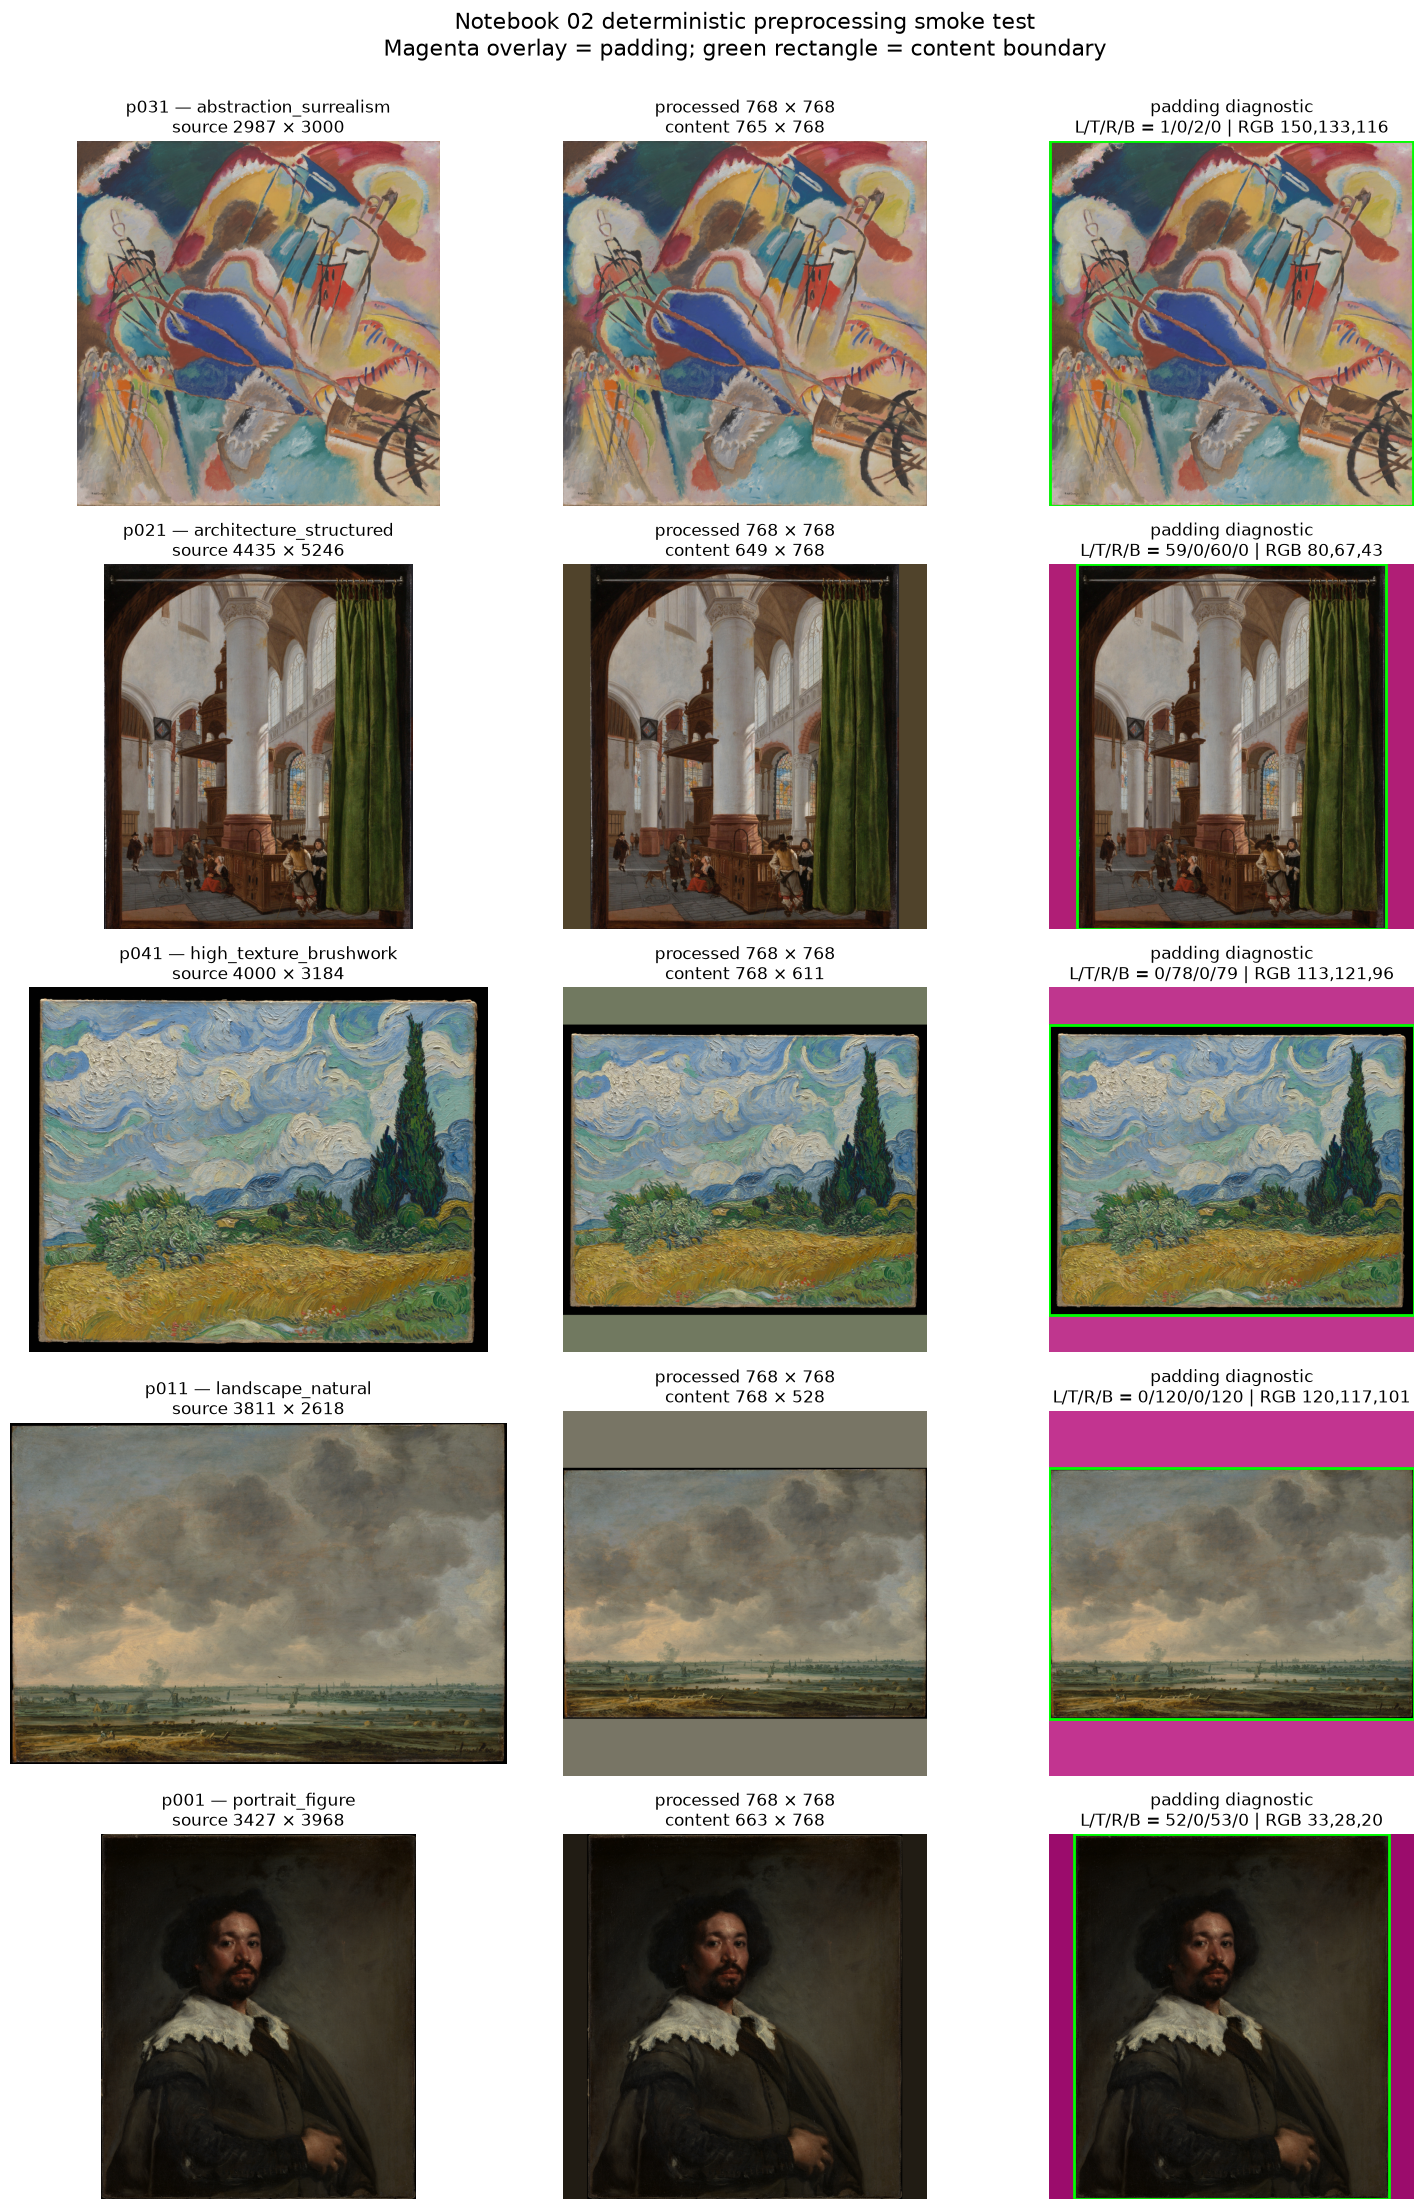

Batch 3 completed successfully.
Separate smoke checks: 6
Consolidated checks remain: 22
No output artifact has been written.
Next approved stage: Batch 4 — full 50-image preprocessing execution.


In [8]:
# ---------------------------------------------------------------------------
# Six separate smoke-test checks
# ---------------------------------------------------------------------------

SMOKE_VALIDATION = ValidationCollector()
SMOKE_VALIDATION_STAGE = "representative_smoke"


# 1. Deterministic selection

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="deterministic_selection",
    check_description=(
        "Smoke selection contains exactly one deterministic "
        "painting per configured category."
    ),
    severity="blocking",
    expected={
        "painting_count": len(
            expected_smoke_categories
        ),
        "categories": expected_smoke_categories,
        "unique_painting_ids": len(
            expected_smoke_categories
        ),
        "repeat_selection_matches": True,
    },
    observed={
        "painting_count": len(
            smoke_selection_df
        ),
        "categories": (
            observed_smoke_categories
        ),
        "painting_ids": (
            smoke_selection_df[
                "painting_id"
            ].tolist()
        ),
        "unique_painting_ids": int(
            smoke_selection_df[
                "painting_id"
            ].nunique()
        ),
        "repeat_selection_matches": (
            smoke_selection_deterministic
        ),
    },
    passed=smoke_selection_passed,
)


# 2. Source loading and policy

source_failures = (
    smoke_results_df.loc[
        ~(
            smoke_results_df[
                "source_contract_passed"
            ]
            & smoke_results_df[
                "source_policy_passed"
            ]
        ),
        [
            "painting_id",
            "category",
            "source_contract_passed",
            "source_policy_passed",
            "icc_status",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="source_policy",
    check_description=(
        "Every smoke source reloads with matching dimensions, "
        "RGB/JPEG format, EXIF orientation 1, and accepted ICC policy."
    ),
    severity="blocking",
    expected="zero source-policy failures",
    observed=len(source_failures),
    passed=not source_failures,
    details=source_failures,
)


# 3. Canvas technical contract

canvas_failures = (
    smoke_results_df.loc[
        ~smoke_results_df[
            "canvas_contract_passed"
        ],
        [
            "painting_id",
            "category",
            "canvas_contract_passed",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="canvas_contract",
    check_description=(
        "Every in-memory result is a 768 × 768 RGB canvas "
        "with PNG and Lanczos preprocessing metadata."
    ),
    severity="blocking",
    expected="zero canvas-contract failures",
    observed=len(canvas_failures),
    passed=not canvas_failures,
    details=canvas_failures,
)


# 4. Aspect ratio and canonical geometry

geometry_failures = (
    smoke_results_df.loc[
        ~smoke_results_df[
            "geometry_reconciles"
        ],
        [
            "painting_id",
            "category",
            "source_width",
            "source_height",
            "resized_width",
            "resized_height",
            "pad_left",
            "pad_top",
            "pad_right",
            "pad_bottom",
            "content_bbox",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="geometry_reconciliation",
    check_description=(
        "Resize dimensions, padding, content areas, and canonical "
        "exclusive-maximum bounding boxes reconcile exactly."
    ),
    severity="blocking",
    expected="zero geometry failures",
    observed=len(geometry_failures),
    passed=not geometry_failures,
    details=geometry_failures,
)


# 5. Median-RGB padding

padding_failures = (
    smoke_results_df.loc[
        ~smoke_results_df[
            "median_padding_passed"
        ],
        [
            "painting_id",
            "category",
            "padding_color",
            "padding_area_fraction",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="median_rgb_padding",
    check_description=(
        "Configured median-RGB values match the source medians "
        "and every padding pixel matches the recorded colour."
    ),
    severity="blocking",
    expected="zero median-padding failures",
    observed=len(padding_failures),
    passed=not padding_failures,
    details=padding_failures,
)


# 6. Deterministic repeated transformation

determinism_failures = (
    smoke_results_df.loc[
        ~(
            smoke_results_df[
                "pixel_determinism_passed"
            ]
            & smoke_results_df[
                "metadata_determinism_passed"
            ]
        ),
        [
            "painting_id",
            "category",
            "pixel_determinism_passed",
            "metadata_determinism_passed",
        ],
    ]
    .to_dict(
        orient="records"
    )
)

SMOKE_VALIDATION.add(
    validation_stage=SMOKE_VALIDATION_STAGE,
    check_id="deterministic_repeat",
    check_description=(
        "Repeated in-memory preprocessing produces identical "
        "pixel arrays and metadata."
    ),
    severity="blocking",
    expected="zero deterministic-repeat failures",
    observed=len(determinism_failures),
    passed=not determinism_failures,
    details=determinism_failures,
)


# ---------------------------------------------------------------------------
# Validate and display smoke evidence
# ---------------------------------------------------------------------------

smoke_checks_df = (
    SMOKE_VALIDATION.to_dataframe()
)

if len(smoke_checks_df) != 6:
    raise RuntimeError(
        "Batch 3 should produce exactly six separate smoke checks; "
        f"found {len(smoke_checks_df)}."
    )

print("Batch 3 representative smoke checks:")
display(
    smoke_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nPer-painting preprocessing geometry:")
display(
    smoke_results_df[
        [
            "painting_id",
            "category",
            "source_width",
            "source_height",
            "resized_width",
            "resized_height",
            "pad_left",
            "pad_top",
            "pad_right",
            "pad_bottom",
            "content_area_fraction",
            "padding_area_fraction",
            "padding_color",
            "icc_status",
        ]
    ]
)

SMOKE_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# In-notebook before/after/padding diagnostic
# ---------------------------------------------------------------------------

smoke_figure, smoke_axes = plt.subplots(
    nrows=len(smoke_visuals),
    ncols=3,
    figsize=(
        15,
        4.4 * len(smoke_visuals),
    ),
    squeeze=False,
)

for row_index, visual in enumerate(
    smoke_visuals
):
    source_preview = visual[
        "source_preview"
    ]
    processed_image = visual[
        "processed_image"
    ]
    metadata = visual["metadata"]

    processed_array = np.asarray(
        processed_image
    )

    content_bbox = (
        int(metadata["content_x_min"]),
        int(metadata["content_y_min"]),
        int(metadata["content_x_max"]),
        int(metadata["content_y_max"]),
    )

    diagnostic_region = content_region(
        processed_array.shape[:2],
        content_bbox,
    )

    padding_mask = (
        ~diagnostic_region.mask
    )

    diagnostic_array = (
        processed_array.astype(
            np.float32
        )
        .copy()
    )

    diagnostic_array[
        padding_mask
    ] = (
        0.45
        * diagnostic_array[
            padding_mask
        ]
        + 0.55
        * np.array(
            [
                255,
                0,
                180,
            ],
            dtype=np.float32,
        )
    )

    diagnostic_array = np.clip(
        diagnostic_array,
        0,
        255,
    ).astype(
        np.uint8
    )

    source_axis = smoke_axes[
        row_index,
        0,
    ]
    processed_axis = smoke_axes[
        row_index,
        1,
    ]
    diagnostic_axis = smoke_axes[
        row_index,
        2,
    ]

    source_axis.imshow(
        source_preview
    )
    source_axis.set_title(
        f"{visual['painting_id']} — {visual['category']}\n"
        f"source {metadata['original_width']} × "
        f"{metadata['original_height']}"
    )

    processed_axis.imshow(
        processed_image
    )
    processed_axis.set_title(
        "processed 768 × 768\n"
        f"content {metadata['resized_width']} × "
        f"{metadata['resized_height']}"
    )

    diagnostic_axis.imshow(
        diagnostic_array
    )

    x_min, y_min, x_max, y_max = (
        content_bbox
    )

    diagnostic_axis.add_patch(
        Rectangle(
            (
                x_min,
                y_min,
            ),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor="lime",
            linewidth=2.0,
        )
    )

    diagnostic_axis.set_title(
        "padding diagnostic\n"
        f"L/T/R/B = "
        f"{metadata['pad_left']}/"
        f"{metadata['pad_top']}/"
        f"{metadata['pad_right']}/"
        f"{metadata['pad_bottom']} | "
        f"RGB {metadata['padding_color_r']},"
        f"{metadata['padding_color_g']},"
        f"{metadata['padding_color_b']}"
    )

    for axis in (
        source_axis,
        processed_axis,
        diagnostic_axis,
    ):
        axis.set_axis_off()

smoke_figure.suptitle(
    "Notebook 02 deterministic preprocessing smoke test\n"
    "Magenta overlay = padding; green rectangle = content boundary",
    fontsize=16,
    y=1.002,
)

smoke_figure.tight_layout()
plt.show()
plt.close(smoke_figure)

print("Batch 3 completed successfully.")
print("Separate smoke checks:", len(smoke_checks_df))
print(
    "Consolidated checks remain:",
    len(VALIDATION.to_dataframe()),
)
print("No output artifact has been written.")
print(
    "Next approved stage: Batch 4 — "
    "full 50-image preprocessing execution."
)

## Batch 4 — Full Controlled-50 Preprocessing Execution

This batch applies the validated deterministic preprocessing implementation to all 50 accepted paintings.

For each painting, it will:

- reload the declared raw source image;
- verify the current source SHA-256 against Notebook 01;
- enforce the approved EXIF and ICC-profile policy;
- resize with Lanczos interpolation while preserving aspect ratio;
- calculate the source-pixel median RGB padding colour;
- create a 768 × 768 RGB canvas without cropping or distortion;
- save `images/clean/<painting_id>.png` atomically;
- strip output image metadata;
- immediately reload the saved PNG;
- record normalized preprocessing geometry and file evidence;
- record runtime separately from the deterministic primary table.

The in-memory `preprocessed_images.v1` table contains only preprocessing-owned information. Artwork descriptions and grouping metadata remain owned by `artworks.v1` and are joined through `painting_id`.

The 50 PNG files created here are provisional until the full reload, pixel, geometry, duplicate, stale, and orphan validation in Batch 5 passes.

No CSV, figure, manifest, or final validation artifact is persisted in this batch.

In [9]:
# ---------------------------------------------------------------------------
# Batch 4 import and execution gates
# ---------------------------------------------------------------------------

from restoration_eval.preprocessing import (
    preprocess_artworks,
)


VALIDATION.raise_for_blocking()
SMOKE_VALIDATION.raise_for_blocking()

FULL_PREPROCESSING_STARTED_AT_UTC = (
    utc_now_iso()
)

print("Starting full controlled-50 preprocessing.")
print("Accepted paintings:", len(accepted_artworks_df))
print(
    "Clean-image directory:",
    to_repo_relative(
        CLEAN_IMAGE_DIRECTORY,
        PROJECT_ROOT,
    ),
)


# ---------------------------------------------------------------------------
# Execute deterministic full preprocessing
# ---------------------------------------------------------------------------

preprocessing_run_result = preprocess_artworks(
    artworks_df,
    preprocessing_config,
    PROJECT_ROOT,
)

preprocessed_images_df = (
    preprocessing_run_result.images.copy()
)

preprocessing_runtimes_df = (
    preprocessing_run_result.runtimes.copy()
)

FULL_PREPROCESSING_COMPLETED_AT_UTC = (
    utc_now_iso()
)


# ---------------------------------------------------------------------------
# Immediate execution reconciliation
# ---------------------------------------------------------------------------

expected_processed_ids = (
    accepted_artworks_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
)

observed_processed_ids = (
    preprocessed_images_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
)

expected_clean_paths = {
    (
        CLEAN_IMAGE_DIRECTORY
        / f"{painting_id}.png"
    ).resolve()
    for painting_id in expected_processed_ids
}

observed_clean_paths = {
    path.resolve()
    for path in CLEAN_IMAGE_DIRECTORY.glob(
        "*.png"
    )
    if path.is_file()
}

missing_after_execution = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        expected_clean_paths
        - observed_clean_paths
    )
)

unexpected_after_execution = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        observed_clean_paths
        - expected_clean_paths
    )
)

execution_reconciles = (
    len(preprocessed_images_df)
    == EXPECTED_PAINTING_COUNT
    and len(preprocessing_runtimes_df)
    == EXPECTED_PAINTING_COUNT
    and observed_processed_ids
    == expected_processed_ids
    and not preprocessed_images_df[
        "painting_id"
    ].duplicated().any()
    and not preprocessing_runtimes_df[
        "painting_id"
    ].duplicated().any()
    and not missing_after_execution
    and not unexpected_after_execution
)

if not execution_reconciles:
    raise RuntimeError(
        "Full preprocessing execution did not reconcile: "
        f"image_rows={len(preprocessed_images_df)}, "
        f"runtime_rows={len(preprocessing_runtimes_df)}, "
        f"missing={missing_after_execution}, "
        f"unexpected={unexpected_after_execution}."
    )

print("Full preprocessing execution completed.")
print(
    "Started:",
    FULL_PREPROCESSING_STARTED_AT_UTC,
)
print(
    "Completed:",
    FULL_PREPROCESSING_COMPLETED_AT_UTC,
)
print(
    "Normalized rows:",
    len(preprocessed_images_df),
)
print(
    "Runtime rows:",
    len(preprocessing_runtimes_df),
)
print(
    "Clean PNG files:",
    len(observed_clean_paths),
)
print(
    "Missing expected files:",
    len(missing_after_execution),
)
print(
    "Unexpected PNG files:",
    len(unexpected_after_execution),
)

Starting full controlled-50 preprocessing.
Accepted paintings: 50
Clean-image directory: outputs/02_image_preprocessing/images/clean
Full preprocessing execution completed.
Started: 2026-08-17T21:21:38.402260Z
Completed: 2026-08-17T21:22:44.722415Z
Normalized rows: 50
Runtime rows: 50
Clean PNG files: 50
Missing expected files: 0
Unexpected PNG files: 0


In [10]:
# ---------------------------------------------------------------------------
# Compact provisional execution summaries
# ---------------------------------------------------------------------------

runtime_values = pd.to_numeric(
    preprocessing_runtimes_df[
        "runtime_seconds"
    ],
    errors="raise",
)

runtime_summary_df = pd.DataFrame(
    [
        {
            "painting_count": len(
                preprocessing_runtimes_df
            ),
            "total_runtime_seconds": float(
                runtime_values.sum()
            ),
            "mean_runtime_seconds": float(
                runtime_values.mean()
            ),
            "median_runtime_seconds": float(
                runtime_values.median()
            ),
            "p95_runtime_seconds": float(
                runtime_values.quantile(
                    0.95
                )
            ),
            "minimum_runtime_seconds": float(
                runtime_values.min()
            ),
            "maximum_runtime_seconds": float(
                runtime_values.max()
            ),
        }
    ]
)

geometry_summary_df = (
    preprocessed_images_df[
        [
            "resize_scale",
            "content_area_fraction",
            "padding_area_fraction",
            "content_width",
            "content_height",
        ]
    ]
    .describe(
        percentiles=[
            0.25,
            0.5,
            0.75,
            0.95,
        ]
    )
    .transpose()
    .reset_index(
        names="field"
    )
)

padding_orientation = np.select(
    [
        (
            preprocessed_images_df[
                "pad_left"
            ]
            + preprocessed_images_df[
                "pad_right"
            ]
        )
        > 0,
        (
            preprocessed_images_df[
                "pad_top"
            ]
            + preprocessed_images_df[
                "pad_bottom"
            ]
        )
        > 0,
    ],
    [
        "left_right",
        "top_bottom",
    ],
    default="none",
)

padding_orientation_summary_df = (
    pd.Series(
        padding_orientation,
        name="padding_orientation",
    )
    .value_counts()
    .rename_axis(
        "padding_orientation"
    )
    .reset_index(
        name="painting_count"
    )
)

print("Provisional preprocessed-images preview:")
display(
    preprocessed_images_df[
        [
            "dataset_sort_index",
            "processed_image_id",
            "painting_id",
            "source_path",
            "processed_path",
            "original_width",
            "original_height",
            "width",
            "height",
            "resize_scale",
            "resized_width",
            "resized_height",
            "pad_left",
            "pad_top",
            "pad_right",
            "pad_bottom",
            "content_area_fraction",
            "padding_area_fraction",
            "input_icc_profile_status",
            "status",
        ]
    ].head(10)
)

print("\nRuntime summary:")
display(runtime_summary_df)

print("\nGeometry summary:")
display(geometry_summary_df)

print("\nPadding orientation summary:")
display(
    padding_orientation_summary_df
)

print("Batch 4 completed successfully.")
print(
    "Provisional clean images written:",
    len(observed_clean_paths),
)
print(
    "Consolidated validation checks remain:",
    len(VALIDATION.to_dataframe()),
)
print(
    "No CSV, figure, manifest, or validation artifact "
    "has been persisted."
)
print(
    "Next approved stage: Batch 5 — "
    "full saved-image reload and reconciliation validation."
)

Provisional preprocessed-images preview:


,dataset_sort_index,processed_image_id,painting_id,source_path,processed_path,original_width,original_height,width,height,resize_scale,resized_width,resized_height,pad_left,pad_top,pad_right,pad_bottom,content_area_fraction,padding_area_fraction,input_icc_profile_status,status
0,1,clean_p001,p001,data/raw/images/p001.jpg,outputs/02_image_preprocessing/images/clean/p0...,3427,3968,768,768,0.193548,663,768,52,0,53,0,0.863281,0.136719,embedded_srgb,passed
1,2,clean_p002,p002,data/raw/images/p002.jpg,outputs/02_image_preprocessing/images/clean/p0...,2336,4000,768,768,0.192000,449,768,159,0,160,0,0.584635,0.415365,missing_assumed_srgb,passed
2,3,clean_p003,p003,data/raw/images/p003.jpg,outputs/02_image_preprocessing/images/clean/p0...,3098,3872,768,768,0.198347,614,768,77,0,77,0,0.799479,0.200521,embedded_srgb,passed
3,4,clean_p004,p004,data/raw/images/p004.jpg,outputs/02_image_preprocessing/images/clean/p0...,4000,3254,768,768,0.192000,768,625,0,71,0,72,0.813802,0.186198,embedded_srgb,passed
4,5,clean_p005,p005,data/raw/images/p005.jpg,outputs/02_image_preprocessing/images/clean/p0...,2884,3894,768,768,0.197227,569,768,99,0,100,0,0.740885,0.259115,embedded_srgb,passed
5,6,clean_p006,p006,data/raw/images/p006.jpg,outputs/02_image_preprocessing/images/clean/p0...,3000,4000,768,768,0.192000,576,768,96,0,96,0,0.750000,0.250000,missing_assumed_srgb,passed
6,7,clean_p007,p007,data/raw/images/p007.jpg,outputs/02_image_preprocessing/images/clean/p0...,3019,4000,768,768,0.192000,580,768,94,0,94,0,0.755208,0.244792,embedded_srgb,passed
7,8,clean_p008,p008,data/raw/images/p008.jpg,outputs/02_image_preprocessing/images/clean/p0...,2855,3873,768,768,0.198296,566,768,101,0,101,0,0.736979,0.263021,missing_assumed_srgb,passed
8,9,clean_p009,p009,data/raw/images/p009.jpg,outputs/02_image_preprocessing/images/clean/p0...,2987,3721,768,768,0.206396,617,768,75,0,76,0,0.803385,0.196615,missing_assumed_srgb,passed
9,10,clean_p010,p010,data/raw/images/p010.jpg,outputs/02_image_preprocessing/images/clean/p0...,4000,3622,768,768,0.192000,768,695,0,36,0,37,0.904948,0.095052,embedded_srgb,passed



Runtime summary:


,painting_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,minimum_runtime_seconds,maximum_runtime_seconds
0,50,66.285188,1.325704,1.212536,2.151011,0.597361,2.428334



Geometry summary:


,field,count,mean,std,min,25%,50%,75%,95%,max
0,resize_scale,50.0,0.203642,0.055020,0.104918,0.192000,0.196671,0.216130,0.293118,0.392437
1,content_area_fraction,50.0,0.770833,0.103772,0.566406,0.692383,0.756510,0.828451,0.982943,1.000000
2,padding_area_fraction,50.0,0.229167,0.103772,0.000000,0.171549,0.243490,0.307617,0.369922,0.433594
3,content_width,50.0,695.540000,96.643297,449.000000,602.000000,768.000000,768.000000,768.000000,768.000000
4,content_height,50.0,664.460000,111.008404,435.000000,570.000000,705.000000,768.000000,768.000000,768.000000



Padding orientation summary:


,padding_orientation,painting_count
0,top_bottom,26
1,left_right,23
2,none,1


Batch 4 completed successfully.
Provisional clean images written: 50
Consolidated validation checks remain: 22
No CSV, figure, manifest, or validation artifact has been persisted.
Next approved stage: Batch 5 — full saved-image reload and reconciliation validation.


## Batch 5 — Full Saved-Image Reload and Reconciliation Validation

This batch formally validates all 50 provisional clean images and the normalized in-memory preprocessing table.

Every saved image is reloaded and checked against its declared record. The batch adds exactly 20 checks covering:

1. `preprocessed_images.v1` schema compliance;
2. table cardinality, identity, and deterministic ordering;
3. runtime-table completeness and validity;
4. filename and repository-relative path contracts;
5. missing and orphaned output detection;
6. complete Pillow reloadability;
7. output dimensions;
8. output colour mode;
9. output format;
10. saved-file checksum reconciliation and stale-output detection;
11. duplicate output-image hashes;
12. Notebook 01 source-reference reconciliation;
13. resize-scale reconciliation;
14. resized-dimension and aspect-ratio reconciliation;
15. padding-dimension and odd-remainder reconciliation;
16. canonical exclusive-maximum content bounding boxes;
17. content, padding, canvas-area, and fraction accounting;
18. median-colour padding pixels;
19. orientation, ICC, colour-space, and metadata-stripping policy;
20. preprocessing method, version, coordinate, and status fields.

These 20 checks extend the 22 existing consolidated checks to 42.

The six representative smoke checks remain separate. No CSV, figure, manifest, or validation artifact is persisted in this batch.

In [11]:
# ---------------------------------------------------------------------------
# Batch 5 import and full saved-output reload
# ---------------------------------------------------------------------------

from restoration_eval.preprocessing import (
    validate_preprocessed_outputs,
)


VALIDATION.raise_for_blocking()
SMOKE_VALIDATION.raise_for_blocking()

preprocessing_validation_result = (
    validate_preprocessed_outputs(
        preprocessed_images_df,
        preprocessing_config,
        PROJECT_ROOT,
    )
)

saved_image_checks_df = (
    preprocessing_validation_result
    .image_checks
    .copy()
)

saved_image_validation_summary = dict(
    preprocessing_validation_result.summary
)


# ---------------------------------------------------------------------------
# Derived reconciliation frames
# ---------------------------------------------------------------------------

source_reference_df = (
    preprocessed_images_df.merge(
        accepted_artworks_df[
            [
                "painting_id",
                "dataset_id",
                "dataset_version",
                "dataset_scope",
                "dataset_sort_index",
                "raw_image_path",
                "raw_sha256",
                "raw_width",
                "raw_height",
            ]
        ],
        on="painting_id",
        how="left",
        validate="one_to_one",
        suffixes=(
            "_processed",
            "_artwork",
        ),
    )
)

source_reference_mask = (
    source_reference_df[
        "dataset_id_processed"
    ].astype(str)
    == source_reference_df[
        "dataset_id_artwork"
    ].astype(str)
) & (
    source_reference_df[
        "dataset_version_processed"
    ].astype(str)
    == source_reference_df[
        "dataset_version_artwork"
    ].astype(str)
) & (
    source_reference_df[
        "dataset_scope_processed"
    ].astype(str)
    == source_reference_df[
        "dataset_scope_artwork"
    ].astype(str)
) & (
    source_reference_df[
        "dataset_sort_index_processed"
    ].astype(int)
    == source_reference_df[
        "dataset_sort_index_artwork"
    ].astype(int)
) & (
    source_reference_df[
        "source_path"
    ].astype(str)
    == source_reference_df[
        "raw_image_path"
    ].astype(str)
) & (
    source_reference_df[
        "source_sha256"
    ].astype(str)
    == source_reference_df[
        "raw_sha256"
    ].astype(str)
) & (
    source_reference_df[
        "original_width"
    ].astype(int)
    == source_reference_df[
        "raw_width"
    ].astype(int)
) & (
    source_reference_df[
        "original_height"
    ].astype(int)
    == source_reference_df[
        "raw_height"
    ].astype(int)
)


geometry_validation_df = (
    preprocessed_images_df.copy()
)

geometry_validation_df[
    "expected_resize_scale"
] = [
    min(
        target_width / int(original_width),
        target_height / int(original_height),
    )
    for original_width, original_height in zip(
        geometry_validation_df[
            "original_width"
        ],
        geometry_validation_df[
            "original_height"
        ],
    )
]

geometry_validation_df[
    "expected_resized_width"
] = [
    min(
        target_width,
        max(
            1,
            round_half_up(
                int(original_width)
                * float(expected_scale)
            ),
        ),
    )
    for original_width, expected_scale in zip(
        geometry_validation_df[
            "original_width"
        ],
        geometry_validation_df[
            "expected_resize_scale"
        ],
    )
]

geometry_validation_df[
    "expected_resized_height"
] = [
    min(
        target_height,
        max(
            1,
            round_half_up(
                int(original_height)
                * float(expected_scale)
            ),
        ),
    )
    for original_height, expected_scale in zip(
        geometry_validation_df[
            "original_height"
        ],
        geometry_validation_df[
            "expected_resize_scale"
        ],
    )
]

geometry_validation_df[
    "expected_pad_left"
] = (
    (
        target_width
        - geometry_validation_df[
            "expected_resized_width"
        ]
    )
    // 2
)

geometry_validation_df[
    "expected_pad_top"
] = (
    (
        target_height
        - geometry_validation_df[
            "expected_resized_height"
        ]
    )
    // 2
)

geometry_validation_df[
    "expected_pad_right"
] = (
    target_width
    - geometry_validation_df[
        "expected_resized_width"
    ]
    - geometry_validation_df[
        "expected_pad_left"
    ]
)

geometry_validation_df[
    "expected_pad_bottom"
] = (
    target_height
    - geometry_validation_df[
        "expected_resized_height"
    ]
    - geometry_validation_df[
        "expected_pad_top"
    ]
)

geometry_validation_df[
    "expected_content_area"
] = (
    geometry_validation_df[
        "resized_width"
    ].astype(int)
    * geometry_validation_df[
        "resized_height"
    ].astype(int)
)

geometry_validation_df[
    "expected_canvas_area"
] = (
    target_width
    * target_height
)

geometry_validation_df[
    "expected_padding_area"
] = (
    geometry_validation_df[
        "expected_canvas_area"
    ]
    - geometry_validation_df[
        "expected_content_area"
    ]
)


def failure_records(
    dataframe,
    passed_mask,
    columns,
):
    """Return compact failure records for one validation check."""
    normalized_mask = pd.Series(
        passed_mask,
        index=dataframe.index,
    ).fillna(False)

    return (
        dataframe.loc[
            ~normalized_mask,
            columns,
        ]
        .to_dict(
            orient="records"
        )
    )


print("Full saved-image reload completed.")
print(
    "Validation passed:",
    preprocessing_validation_result.passed,
)
print("Reloaded records:", len(saved_image_checks_df))
print(
    "Helper validation summary:",
    saved_image_validation_summary,
)

Full saved-image reload completed.
Validation passed: True
Reloaded records: 50
Helper validation summary: {'missing_output_count': 0, 'stale_output_count': 0, 'duplicate_sha256_group_count': 0, 'orphan_output_count': 0, 'reload_failure_count': 0, 'output_width_nonconforming_count': 0, 'output_height_nonconforming_count': 0, 'output_mode_nonconforming_count': 0, 'output_format_nonconforming_count': 0, 'invalid_content_bbox_count': 0, 'geometry_reconciliation_failure_count': 0, 'padding_pixel_mismatch_count': 0, 'output_icc_present_count': 0}


In [12]:
# ---------------------------------------------------------------------------
# Twenty consolidated full-output checks
# ---------------------------------------------------------------------------

FULL_OUTPUT_VALIDATION_STAGE = (
    "full_output_validation"
)


# 1. Normalized table schema

preprocessed_schema_result = validate_dataframe(
    preprocessed_images_df,
    PREPROCESSED_IMAGES_SCHEMA,
    allow_extra_columns=False,
)

preprocessed_schema_passed = (
    preprocessed_schema_result.passed
    and not preprocessed_schema_result.unexpected_columns
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="preprocessed_table_schema",
    check_description=(
        "The normalized preprocessing table satisfies the exact "
        "preprocessed_images.v1 schema."
    ),
    severity="blocking",
    expected={
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "missing_columns": [],
        "unexpected_columns": [],
        "duplicate_primary_key_rows": 0,
    },
    observed=preprocessed_schema_result.to_dict(),
    passed=preprocessed_schema_passed,
)


# 2. Table cardinality, identities, and ordering

table_identity_passed = (
    len(preprocessed_images_df)
    == EXPECTED_PAINTING_COUNT
    and preprocessed_images_df[
        "painting_id"
    ].astype(str).tolist()
    == expected_processed_ids
    and preprocessed_images_df[
        "processed_image_id"
    ].astype(str).tolist()
    == [
        f"clean_{painting_id}"
        for painting_id
        in expected_processed_ids
    ]
    and preprocessed_images_df[
        "dataset_sort_index"
    ].astype(int).tolist()
    == expected_sort_indexes
    and not preprocessed_images_df[
        "painting_id"
    ].duplicated().any()
    and not preprocessed_images_df[
        "processed_image_id"
    ].duplicated().any()
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="preprocessed_table_identity",
    check_description=(
        "The preprocessing table contains one deterministically "
        "ordered row per accepted painting."
    ),
    severity="blocking",
    expected={
        "row_count": EXPECTED_PAINTING_COUNT,
        "duplicate_painting_ids": 0,
        "duplicate_processed_image_ids": 0,
        "ordered_painting_ids": expected_processed_ids,
    },
    observed={
        "row_count": len(
            preprocessed_images_df
        ),
        "duplicate_painting_ids": int(
            preprocessed_images_df[
                "painting_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "duplicate_processed_image_ids": int(
            preprocessed_images_df[
                "processed_image_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "ordered_painting_ids": (
            preprocessed_images_df[
                "painting_id"
            ].astype(str).tolist()
        ),
    },
    passed=table_identity_passed,
)


# 3. Runtime table

runtime_numeric = pd.to_numeric(
    preprocessing_runtimes_df[
        "runtime_seconds"
    ],
    errors="coerce",
)

runtime_contract_passed = (
    list(preprocessing_runtimes_df.columns)
    == [
        "painting_id",
        "runtime_seconds",
    ]
    and len(preprocessing_runtimes_df)
    == EXPECTED_PAINTING_COUNT
    and preprocessing_runtimes_df[
        "painting_id"
    ].astype(str).tolist()
    == expected_processed_ids
    and not preprocessing_runtimes_df[
        "painting_id"
    ].duplicated().any()
    and runtime_numeric.notna().all()
    and np.isfinite(runtime_numeric).all()
    and (runtime_numeric > 0).all()
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="runtime_table_contract",
    check_description=(
        "Runtime evidence contains one positive finite value per painting "
        "without entering the deterministic primary table."
    ),
    severity="blocking",
    expected={
        "row_count": EXPECTED_PAINTING_COUNT,
        "columns": [
            "painting_id",
            "runtime_seconds",
        ],
        "duplicate_painting_ids": 0,
        "invalid_runtime_values": 0,
    },
    observed={
        "row_count": len(
            preprocessing_runtimes_df
        ),
        "columns": list(
            preprocessing_runtimes_df.columns
        ),
        "duplicate_painting_ids": int(
            preprocessing_runtimes_df[
                "painting_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
        "invalid_runtime_values": int(
            (
                runtime_numeric.isna()
                | ~np.isfinite(runtime_numeric)
                | (runtime_numeric <= 0)
            ).sum()
        ),
    },
    passed=runtime_contract_passed,
)


# 4. Filenames and repository-relative paths

expected_processed_filenames = [
    f"{painting_id}.png"
    for painting_id in expected_processed_ids
]

expected_processed_paths = [
    to_repo_relative(
        CLEAN_IMAGE_DIRECTORY
        / filename,
        PROJECT_ROOT,
    )
    for filename in expected_processed_filenames
]

filename_path_mask = (
    preprocessed_images_df[
        "processed_filename"
    ].astype(str).tolist()
    == expected_processed_filenames
) and (
    preprocessed_images_df[
        "processed_path"
    ].astype(str).tolist()
    == expected_processed_paths
) and all(
    not Path(path).is_absolute()
    and "\\" not in path
    for path in preprocessed_images_df[
        "processed_path"
    ].astype(str)
) and all(
    not Path(path).is_absolute()
    and "\\" not in path
    for path in preprocessed_images_df[
        "source_path"
    ].astype(str)
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="filename_path_contract",
    check_description=(
        "Every output uses <painting_id>.png and every stored source "
        "and output path is normalized and repository-relative."
    ),
    severity="blocking",
    expected={
        "filename_mismatches": 0,
        "processed_path_mismatches": 0,
        "absolute_or_backslash_paths": 0,
    },
    observed={
        "filename_mismatches": int(
            sum(
                observed != expected
                for observed, expected in zip(
                    preprocessed_images_df[
                        "processed_filename"
                    ].astype(str),
                    expected_processed_filenames,
                )
            )
        ),
        "processed_path_mismatches": int(
            sum(
                observed != expected
                for observed, expected in zip(
                    preprocessed_images_df[
                        "processed_path"
                    ].astype(str),
                    expected_processed_paths,
                )
            )
        ),
        "absolute_or_backslash_paths": int(
            sum(
                Path(path).is_absolute()
                or "\\" in path
                for path in pd.concat(
                    [
                        preprocessed_images_df[
                            "source_path"
                        ],
                        preprocessed_images_df[
                            "processed_path"
                        ],
                    ]
                ).astype(str)
            )
        ),
    },
    passed=filename_path_mask,
)


# 5. Missing and orphaned files

file_set_passed = (
    saved_image_validation_summary[
        "missing_output_count"
    ] == 0
    and saved_image_validation_summary[
        "orphan_output_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="file_set_reconciliation",
    check_description=(
        "The clean-image directory contains every declared output "
        "and no orphaned PNG files."
    ),
    severity="blocking",
    expected={
        "missing_outputs": 0,
        "orphan_outputs": 0,
    },
    observed={
        "missing_outputs": (
            saved_image_validation_summary[
                "missing_output_count"
            ]
        ),
        "orphan_outputs": (
            saved_image_validation_summary[
                "orphan_output_count"
            ]
        ),
        "orphan_paths": list(
            preprocessing_validation_result
            .orphan_paths
        ),
    },
    passed=file_set_passed,
)


# 6. Complete image reload

reload_passed = (
    saved_image_validation_summary[
        "reload_failure_count"
    ] == 0
    and saved_image_checks_df[
        "reload_passed"
    ].all()
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="saved_image_reload",
    check_description=(
        "Every saved clean image reloads successfully through Pillow."
    ),
    severity="blocking",
    expected="zero reload failures",
    observed=saved_image_validation_summary[
        "reload_failure_count"
    ],
    passed=reload_passed,
    details=(
        saved_image_checks_df.loc[
            ~saved_image_checks_df[
                "reload_passed"
            ],
            [
                "painting_id",
                "processed_path",
                "issue",
            ],
        ].to_dict(
            orient="records"
        )
    ),
)


# 7. Output dimensions

dimension_passed = (
    saved_image_validation_summary[
        "output_width_nonconforming_count"
    ] == 0
    and saved_image_validation_summary[
        "output_height_nonconforming_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="output_dimensions",
    check_description=(
        "Every reloaded output is exactly 768 × 768 pixels."
    ),
    severity="blocking",
    expected={
        "width": target_width,
        "height": target_height,
        "nonconforming_outputs": 0,
    },
    observed={
        "width_failures": (
            saved_image_validation_summary[
                "output_width_nonconforming_count"
            ]
        ),
        "height_failures": (
            saved_image_validation_summary[
                "output_height_nonconforming_count"
            ]
        ),
    },
    passed=dimension_passed,
)


# 8. Output mode

mode_passed = (
    saved_image_validation_summary[
        "output_mode_nonconforming_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="output_mode",
    check_description=(
        "Every reloaded output uses RGB colour mode."
    ),
    severity="blocking",
    expected={
        "mode": "RGB",
        "nonconforming_outputs": 0,
    },
    observed={
        "nonconforming_outputs": (
            saved_image_validation_summary[
                "output_mode_nonconforming_count"
            ]
        ),
        "declared_modes": sorted(
            preprocessed_images_df[
                "mode"
            ].astype(str).unique().tolist()
        ),
    },
    passed=mode_passed,
)


# 9. Output format

format_passed = (
    saved_image_validation_summary[
        "output_format_nonconforming_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="output_format",
    check_description=(
        "Every reloaded output is a PNG file."
    ),
    severity="blocking",
    expected={
        "format": "PNG",
        "nonconforming_outputs": 0,
    },
    observed={
        "nonconforming_outputs": (
            saved_image_validation_summary[
                "output_format_nonconforming_count"
            ]
        ),
        "declared_formats": sorted(
            preprocessed_images_df[
                "format"
            ].astype(str).unique().tolist()
        ),
    },
    passed=format_passed,
)


# 10. Saved-file checksums and stale outputs

checksum_passed = (
    saved_image_validation_summary[
        "stale_output_count"
    ] == 0
    and saved_image_checks_df[
        "sha256_matches"
    ].all()
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="saved_checksum_reconciliation",
    check_description=(
        "Every saved PNG SHA-256 matches its normalized table record."
    ),
    severity="blocking",
    expected="zero stale checksum mismatches",
    observed=saved_image_validation_summary[
        "stale_output_count"
    ],
    passed=checksum_passed,
    details=(
        saved_image_checks_df.loc[
            saved_image_checks_df[
                "file_exists"
            ]
            & ~saved_image_checks_df[
                "sha256_matches"
            ],
            [
                "painting_id",
                "processed_path",
                "issue",
            ],
        ].to_dict(
            orient="records"
        )
    ),
)


# 11. Duplicate output hashes

duplicate_hash_passed = (
    saved_image_validation_summary[
        "duplicate_sha256_group_count"
    ] == 0
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="duplicate_output_hashes",
    check_description=(
        "No two clean outputs share the same full-file SHA-256."
    ),
    severity="blocking",
    expected="zero duplicate SHA-256 groups",
    observed=saved_image_validation_summary[
        "duplicate_sha256_group_count"
    ],
    passed=duplicate_hash_passed,
    details=list(
        preprocessing_validation_result
        .duplicate_sha256_groups
    ),
)


# 12. Notebook 01 source references

source_reference_failures = failure_records(
    source_reference_df,
    source_reference_mask,
    [
        "painting_id",
        "source_path",
        "raw_image_path",
        "source_sha256",
        "raw_sha256",
        "original_width",
        "raw_width",
        "original_height",
        "raw_height",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="source_reference_reconciliation",
    check_description=(
        "Every preprocessing row retains the exact Notebook 01 "
        "dataset identity, source path, checksum, and dimensions."
    ),
    severity="blocking",
    expected="zero source-reference mismatches",
    observed=len(source_reference_failures),
    passed=not source_reference_failures,
    details=source_reference_failures,
)


# 13. Resize scale

resize_scale_mask = np.isclose(
    geometry_validation_df[
        "resize_scale"
    ].astype(float),
    geometry_validation_df[
        "expected_resize_scale"
    ].astype(float),
    rtol=0,
    atol=1e-12,
)

resize_scale_failures = failure_records(
    geometry_validation_df,
    resize_scale_mask,
    [
        "painting_id",
        "original_width",
        "original_height",
        "resize_scale",
        "expected_resize_scale",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="resize_scale_reconciliation",
    check_description=(
        "Every recorded scale equals the configured fit-inside scale."
    ),
    severity="blocking",
    expected="zero resize-scale mismatches",
    observed=len(resize_scale_failures),
    passed=not resize_scale_failures,
    details=resize_scale_failures,
)


# 14. Resized dimensions and aspect preservation

resized_dimension_mask = (
    geometry_validation_df[
        "resized_width"
    ].astype(int)
    == geometry_validation_df[
        "expected_resized_width"
    ].astype(int)
) & (
    geometry_validation_df[
        "resized_height"
    ].astype(int)
    == geometry_validation_df[
        "expected_resized_height"
    ].astype(int)
) & (
    (
        geometry_validation_df[
            "resized_width"
        ].astype(int)
        == target_width
    )
    | (
        geometry_validation_df[
            "resized_height"
        ].astype(int)
        == target_height
    )
)

resized_dimension_failures = failure_records(
    geometry_validation_df,
    resized_dimension_mask,
    [
        "painting_id",
        "original_width",
        "original_height",
        "resized_width",
        "expected_resized_width",
        "resized_height",
        "expected_resized_height",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="resized_dimension_reconciliation",
    check_description=(
        "Round-half-up resized dimensions match the configured scale "
        "and fit one canvas dimension exactly."
    ),
    severity="blocking",
    expected="zero resized-dimension mismatches",
    observed=len(resized_dimension_failures),
    passed=not resized_dimension_failures,
    details=resized_dimension_failures,
)


# 15. Padding dimensions and odd remainders

padding_dimension_mask = (
    geometry_validation_df[
        "pad_left"
    ].astype(int)
    == geometry_validation_df[
        "expected_pad_left"
    ].astype(int)
) & (
    geometry_validation_df[
        "pad_top"
    ].astype(int)
    == geometry_validation_df[
        "expected_pad_top"
    ].astype(int)
) & (
    geometry_validation_df[
        "pad_right"
    ].astype(int)
    == geometry_validation_df[
        "expected_pad_right"
    ].astype(int)
) & (
    geometry_validation_df[
        "pad_bottom"
    ].astype(int)
    == geometry_validation_df[
        "expected_pad_bottom"
    ].astype(int)
) & (
    geometry_validation_df[
        "pad_right"
    ].astype(int)
    - geometry_validation_df[
        "pad_left"
    ].astype(int)
).isin(
    [0, 1]
) & (
    geometry_validation_df[
        "pad_bottom"
    ].astype(int)
    - geometry_validation_df[
        "pad_top"
    ].astype(int)
).isin(
    [0, 1]
)

padding_dimension_failures = failure_records(
    geometry_validation_df,
    padding_dimension_mask,
    [
        "painting_id",
        "resized_width",
        "resized_height",
        "pad_left",
        "pad_top",
        "pad_right",
        "pad_bottom",
        "expected_pad_left",
        "expected_pad_top",
        "expected_pad_right",
        "expected_pad_bottom",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="padding_dimension_reconciliation",
    check_description=(
        "Padding dimensions reconcile with the canvas and odd "
        "remainders are assigned to the right or bottom."
    ),
    severity="blocking",
    expected="zero padding-dimension mismatches",
    observed=len(padding_dimension_failures),
    passed=not padding_dimension_failures,
    details=padding_dimension_failures,
)


# 16. Canonical exclusive-maximum content boxes

content_bbox_mask = (
    geometry_validation_df[
        "content_x_min"
    ].astype(int)
    == geometry_validation_df[
        "pad_left"
    ].astype(int)
) & (
    geometry_validation_df[
        "content_y_min"
    ].astype(int)
    == geometry_validation_df[
        "pad_top"
    ].astype(int)
) & (
    geometry_validation_df[
        "content_x_max"
    ].astype(int)
    == (
        geometry_validation_df[
            "pad_left"
        ].astype(int)
        + geometry_validation_df[
            "resized_width"
        ].astype(int)
    )
) & (
    geometry_validation_df[
        "content_y_max"
    ].astype(int)
    == (
        geometry_validation_df[
            "pad_top"
        ].astype(int)
        + geometry_validation_df[
            "resized_height"
        ].astype(int)
    )
) & (
    geometry_validation_df[
        "content_x_min"
    ].astype(int)
    >= 0
) & (
    geometry_validation_df[
        "content_y_min"
    ].astype(int)
    >= 0
) & (
    geometry_validation_df[
        "content_x_max"
    ].astype(int)
    <= target_width
) & (
    geometry_validation_df[
        "content_y_max"
    ].astype(int)
    <= target_height
) & (
    saved_image_validation_summary[
        "invalid_content_bbox_count"
    ] == 0
)

content_bbox_failures = failure_records(
    geometry_validation_df,
    content_bbox_mask,
    [
        "painting_id",
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
        "resized_width",
        "resized_height",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="content_bbox_reconciliation",
    check_description=(
        "Every zero-based exclusive-maximum content box is valid "
        "and matches the resized content extent."
    ),
    severity="blocking",
    expected="zero content-box mismatches",
    observed=len(content_bbox_failures),
    passed=not content_bbox_failures,
    details=content_bbox_failures,
)


# 17. Area and fraction accounting

area_fraction_mask = (
    geometry_validation_df[
        "content_area_pixels"
    ].astype(int)
    == geometry_validation_df[
        "expected_content_area"
    ].astype(int)
) & (
    geometry_validation_df[
        "padding_area_pixels"
    ].astype(int)
    == geometry_validation_df[
        "expected_padding_area"
    ].astype(int)
) & (
    geometry_validation_df[
        "canvas_area_pixels"
    ].astype(int)
    == geometry_validation_df[
        "expected_canvas_area"
    ].astype(int)
) & np.isclose(
    geometry_validation_df[
        "content_area_fraction"
    ].astype(float),
    (
        geometry_validation_df[
            "expected_content_area"
        ].astype(float)
        / geometry_validation_df[
            "expected_canvas_area"
        ].astype(float)
    ),
    rtol=0,
    atol=1e-12,
) & np.isclose(
    geometry_validation_df[
        "padding_area_fraction"
    ].astype(float),
    (
        geometry_validation_df[
            "expected_padding_area"
        ].astype(float)
        / geometry_validation_df[
            "expected_canvas_area"
        ].astype(float)
    ),
    rtol=0,
    atol=1e-12,
) & np.isclose(
    geometry_validation_df[
        "content_area_fraction"
    ].astype(float)
    + geometry_validation_df[
        "padding_area_fraction"
    ].astype(float),
    1.0,
    rtol=0,
    atol=1e-12,
)

area_fraction_failures = failure_records(
    geometry_validation_df,
    area_fraction_mask,
    [
        "painting_id",
        "content_area_pixels",
        "expected_content_area",
        "padding_area_pixels",
        "expected_padding_area",
        "canvas_area_pixels",
        "expected_canvas_area",
        "content_area_fraction",
        "padding_area_fraction",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="area_fraction_reconciliation",
    check_description=(
        "Content, padding, and canvas areas and fractions reconcile exactly."
    ),
    severity="blocking",
    expected="zero area or fraction mismatches",
    observed=len(area_fraction_failures),
    passed=not area_fraction_failures,
    details=area_fraction_failures,
)


# 18. Padding pixels

padding_pixel_passed = (
    saved_image_validation_summary[
        "padding_pixel_mismatch_count"
    ] == 0
    and saved_image_checks_df[
        "padding_pixels_match"
    ].all()
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="padding_pixel_reconciliation",
    check_description=(
        "Every saved padding pixel matches its recorded median-RGB colour."
    ),
    severity="blocking",
    expected="zero padding-pixel mismatches",
    observed=saved_image_validation_summary[
        "padding_pixel_mismatch_count"
    ],
    passed=padding_pixel_passed,
    details=(
        saved_image_checks_df.loc[
            saved_image_checks_df[
                "reload_passed"
            ]
            & ~saved_image_checks_df[
                "padding_pixels_match"
            ],
            [
                "painting_id",
                "processed_path",
                "issue",
            ],
        ].to_dict(
            orient="records"
        )
    ),
)


# 19. Orientation, ICC, colour, and metadata policy

expected_color_policy = (
    preprocessed_images_df[
        "input_icc_profile_status"
    ].map(
        {
            "missing_assumed_srgb": (
                preprocessing_config[
                    "color"
                ]["missing_icc_action"]
            ),
            "embedded_srgb": (
                preprocessing_config[
                    "color"
                ]["embedded_srgb_action"]
            ),
        }
    )
)

color_orientation_mask = (
    preprocessed_images_df[
        "source_orientation"
    ].astype(int)
    == 1
) & (
    preprocessed_images_df[
        "orientation_policy"
    ].astype(str)
    == preprocessing_config[
        "orientation"
    ]["policy_label"]
) & (
    preprocessed_images_df[
        "input_icc_profile_status"
    ].isin(
        {
            "missing_assumed_srgb",
            "embedded_srgb",
        }
    )
) & (
    preprocessed_images_df[
        "color_space_policy"
    ].astype(str)
    == expected_color_policy.astype(str)
) & (
    ~preprocessed_images_df[
        "output_icc_profile_present"
    ].astype(bool)
)

color_orientation_failures = failure_records(
    preprocessed_images_df,
    color_orientation_mask,
    [
        "painting_id",
        "source_orientation",
        "orientation_policy",
        "input_icc_profile_status",
        "color_space_policy",
        "output_icc_profile_present",
    ],
)

color_orientation_passed = (
    not color_orientation_failures
    and saved_image_validation_summary[
        "output_icc_present_count"
    ] == 0
    and int(
        (
            preprocessed_images_df[
                "input_icc_profile_status"
            ] == "embedded_srgb"
        ).sum()
    ) == embedded_srgb_count
    and int(
        (
            preprocessed_images_df[
                "input_icc_profile_status"
            ] == "missing_assumed_srgb"
        ).sum()
    ) == missing_icc_count
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="color_orientation_policy",
    check_description=(
        "Source orientation and ICC handling match the approved policy "
        "and saved PNG metadata is stripped."
    ),
    severity="blocking",
    expected={
        "orientation": 1,
        "embedded_srgb_count": embedded_srgb_count,
        "missing_icc_count": missing_icc_count,
        "non_srgb_count": 0,
        "outputs_with_icc": 0,
    },
    observed={
        "orientation_values": sorted(
            preprocessed_images_df[
                "source_orientation"
            ].astype(int).unique().tolist()
        ),
        "embedded_srgb_count": int(
            (
                preprocessed_images_df[
                    "input_icc_profile_status"
                ] == "embedded_srgb"
            ).sum()
        ),
        "missing_icc_count": int(
            (
                preprocessed_images_df[
                    "input_icc_profile_status"
                ] == "missing_assumed_srgb"
            ).sum()
        ),
        "policy_failures": len(
            color_orientation_failures
        ),
        "outputs_with_icc": (
            saved_image_validation_summary[
                "output_icc_present_count"
            ]
        ),
    },
    passed=color_orientation_passed,
    details=color_orientation_failures,
)


# 20. Preprocessing method and terminal status

method_status_mask = (
    preprocessed_images_df[
        "interpolation"
    ].astype(str)
    == preprocessing_config[
        "processing"
    ]["interpolation"]
) & (
    preprocessed_images_df[
        "padding_method"
    ].astype(str)
    == preprocessing_config[
        "processing"
    ]["padding_method"]
) & (
    preprocessed_images_df[
        "coordinate_convention"
    ].astype(str)
    == preprocessing_config[
        "processing"
    ]["coordinate_convention"]
) & (
    preprocessed_images_df[
        "preprocessing_method"
    ].astype(str)
    == preprocessing_config[
        "processing"
    ]["method"]
) & (
    preprocessed_images_df[
        "preprocessing_version"
    ].astype(str)
    == preprocessing_config[
        "processing"
    ]["version"]
) & (
    preprocessed_images_df[
        "status"
    ].astype(str)
    == "passed"
)

method_status_failures = failure_records(
    preprocessed_images_df,
    method_status_mask,
    [
        "painting_id",
        "interpolation",
        "padding_method",
        "coordinate_convention",
        "preprocessing_method",
        "preprocessing_version",
        "status",
    ],
)

VALIDATION.add(
    validation_stage=FULL_OUTPUT_VALIDATION_STAGE,
    check_id="preprocessing_method_status",
    check_description=(
        "Every row records the approved interpolation, padding, "
        "coordinate, method, version, and passed status."
    ),
    severity="blocking",
    expected="zero method or status mismatches",
    observed=len(method_status_failures),
    passed=not method_status_failures,
    details=method_status_failures,
)


# ---------------------------------------------------------------------------
# Batch 5 consolidated validation summary
# ---------------------------------------------------------------------------

cumulative_checks_df = VALIDATION.to_dataframe()

batch5_checks_df = cumulative_checks_df.loc[
    cumulative_checks_df[
        "validation_stage"
    ] == FULL_OUTPUT_VALIDATION_STAGE
].reset_index(drop=True)

if len(batch5_checks_df) != 20:
    raise RuntimeError(
        "Batch 5 should add exactly 20 full-output checks; "
        f"found {len(batch5_checks_df)}."
    )

if len(cumulative_checks_df) != 42:
    raise RuntimeError(
        "Batches 1, 2, and 5 should contain exactly 42 "
        f"cumulative checks; found {len(cumulative_checks_df)}."
    )

print("Batch 5 full-output checks:")
display(
    batch5_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nPer-image reload evidence preview:")
display(
    saved_image_checks_df.head(10)
)

print("\nSaved-image validation summary:")
display(
    pd.DataFrame(
        [
            {
                **saved_image_validation_summary,
                "validated_image_count": len(
                    saved_image_checks_df
                ),
                "overall_passed": (
                    preprocessing_validation_result
                    .passed
                ),
            }
        ]
    )
)

VALIDATION.raise_for_blocking()

print("\nBatch 5 completed successfully.")
print("Batch 5 checks:", len(batch5_checks_df))
print("Cumulative consolidated checks:", len(cumulative_checks_df))
print("Separate smoke checks:", len(smoke_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("No CSV, figure, manifest, or validation artifact has been persisted.")
print(
    "Next approved stage: Batch 6 — "
    "preprocessing audit and canonical preview generation."
)

Batch 5 full-output checks:


,check_id,severity,expected,observed,passed
0,preprocessed_table_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 50, ""duplicate_primary_key_ro...",True
1,preprocessed_table_identity,blocking,"{""duplicate_painting_ids"": 0, ""duplicate_proce...","{""duplicate_painting_ids"": 0, ""duplicate_proce...",True
2,runtime_table_contract,blocking,"{""columns"": [""painting_id"", ""runtime_seconds""]...","{""columns"": [""painting_id"", ""runtime_seconds""]...",True
3,filename_path_contract,blocking,"{""absolute_or_backslash_paths"": 0, ""filename_m...","{""absolute_or_backslash_paths"": 0, ""filename_m...",True
4,file_set_reconciliation,blocking,"{""missing_outputs"": 0, ""orphan_outputs"": 0}","{""missing_outputs"": 0, ""orphan_outputs"": 0, ""o...",True
5,saved_image_reload,blocking,zero reload failures,0,True
6,output_dimensions,blocking,"{""height"": 768, ""nonconforming_outputs"": 0, ""w...","{""height_failures"": 0, ""width_failures"": 0}",True
7,output_mode,blocking,"{""mode"": ""RGB"", ""nonconforming_outputs"": 0}","{""declared_modes"": [""RGB""], ""nonconforming_out...",True
8,output_format,blocking,"{""format"": ""PNG"", ""nonconforming_outputs"": 0}","{""declared_formats"": [""PNG""], ""nonconforming_o...",True
9,saved_checksum_reconciliation,blocking,zero stale checksum mismatches,0,True



Per-image reload evidence preview:


,painting_id,processed_path,file_exists,reload_passed,sha256_matches,width_matches,height_matches,mode_matches,format_matches,output_icc_absent,geometry_reconciles,content_bbox_valid,padding_pixels_match,issue
0,p001,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
1,p002,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
2,p003,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
3,p004,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
4,p005,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
5,p006,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
6,p007,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
7,p008,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
8,p009,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,
9,p010,outputs/02_image_preprocessing/images/clean/p0...,True,True,True,True,True,True,True,True,True,True,True,



Saved-image validation summary:


,missing_output_count,stale_output_count,duplicate_sha256_group_count,orphan_output_count,reload_failure_count,output_width_nonconforming_count,output_height_nonconforming_count,output_mode_nonconforming_count,output_format_nonconforming_count,invalid_content_bbox_count,geometry_reconciliation_failure_count,padding_pixel_mismatch_count,output_icc_present_count,validated_image_count,overall_passed
0,0,0,0,0,0,0,0,0,0,0,0,0,0,50,True



Batch 5 completed successfully.
Batch 5 checks: 20
Cumulative consolidated checks: 42
Separate smoke checks: 6
Blocking failures: 0
No CSV, figure, manifest, or validation artifact has been persisted.
Next approved stage: Batch 6 — preprocessing audit and canonical preview generation.


## Batch 6 — Preprocessing Audit and Canonical Preview

This batch constructs the remaining canonical scientific evidence in memory.

It produces:

- the 45-row `preprocessing_audit.v1` table;
- 25 global technical, integrity, colour-policy, and runtime metrics;
- four grouped metrics for each of the five configured categories;
- one deterministic preview painting per category;
- a canonical before/after/padding diagnostic figure.

The category-level audit metrics are:

- processed painting count;
- mean content-area fraction;
- mean padding-area fraction;
- median resize scale.

Eight final consolidated checks validate:

1. preprocessing-audit schema compliance;
2. audit row identities and section structure;
3. global audit reconciliation;
4. category audit reconciliation;
5. deterministic preview selection;
6. preview source-image reload;
7. preview clean-image and geometry reconciliation;
8. canonical figure rendering.

These checks extend the 42 existing consolidated checks to the final planned total of 50.

The audit table and preview figure remain in memory until the atomic persistence stage. No artifact is written in this batch.

In [13]:
# ---------------------------------------------------------------------------
# Batch 6 imports
# ---------------------------------------------------------------------------

from restoration_eval.preprocessing import (
    GLOBAL_AUDIT_METRIC_COUNT,
    GROUPED_AUDIT_METRICS,
    build_preprocessing_audit,
    select_preview_rows,
)


VALIDATION.raise_for_blocking()
SMOKE_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Build the normalized 45-row audit
# ---------------------------------------------------------------------------

preprocessing_audit_df = (
    build_preprocessing_audit(
        preprocessed_images_df,
        artworks_df,
        preprocessing_runtimes_df,
        preprocessing_validation_result,
        preprocessing_config,
    )
)

global_audit_df = (
    preprocessing_audit_df.loc[
        preprocessing_audit_df[
            "audit_section"
        ] == "global"
    ]
    .reset_index(drop=True)
)

category_audit_df = (
    preprocessing_audit_df.loc[
        preprocessing_audit_df[
            "audit_section"
        ] == "category"
    ]
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Build independent expected global audit values
# ---------------------------------------------------------------------------

expected_global_audit_values = {
    "accepted_input_count": int(
        (
            artworks_df[
                "acceptance_status"
            ] == "accepted"
        ).sum()
    ),
    "processed_output_count": int(
        len(preprocessed_images_df)
    ),
    "failed_output_count": int(
        (
            preprocessed_images_df[
                "status"
            ] != "passed"
        ).sum()
    ),
    "missing_output_count": int(
        saved_image_validation_summary[
            "missing_output_count"
        ]
    ),
    "stale_output_count": int(
        saved_image_validation_summary[
            "stale_output_count"
        ]
    ),
    "duplicate_sha256_group_count": int(
        saved_image_validation_summary[
            "duplicate_sha256_group_count"
        ]
    ),
    "orphan_output_count": int(
        saved_image_validation_summary[
            "orphan_output_count"
        ]
    ),
    "reload_failure_count": int(
        saved_image_validation_summary[
            "reload_failure_count"
        ]
    ),
    "output_width_nonconforming_count": int(
        saved_image_validation_summary[
            "output_width_nonconforming_count"
        ]
    ),
    "output_height_nonconforming_count": int(
        saved_image_validation_summary[
            "output_height_nonconforming_count"
        ]
    ),
    "output_mode_nonconforming_count": int(
        saved_image_validation_summary[
            "output_mode_nonconforming_count"
        ]
    ),
    "output_format_nonconforming_count": int(
        saved_image_validation_summary[
            "output_format_nonconforming_count"
        ]
    ),
    "invalid_content_bbox_count": int(
        saved_image_validation_summary[
            "invalid_content_bbox_count"
        ]
    ),
    "geometry_reconciliation_failure_count": int(
        saved_image_validation_summary[
            "geometry_reconciliation_failure_count"
        ]
    ),
    "padding_pixel_mismatch_count": int(
        saved_image_validation_summary[
            "padding_pixel_mismatch_count"
        ]
    ),
    "source_sha256_mismatch_count": int(
        (
            source_reference_df[
                "source_sha256"
            ].astype(str)
            != source_reference_df[
                "raw_sha256"
            ].astype(str)
        ).sum()
    ),
    "source_orientation_nonconforming_count": int(
        (
            preprocessed_images_df[
                "source_orientation"
            ].astype(int)
            != 1
        ).sum()
    ),
    "source_icc_missing_count": int(
        (
            preprocessed_images_df[
                "input_icc_profile_status"
            ] == "missing_assumed_srgb"
        ).sum()
    ),
    "source_icc_srgb_count": int(
        (
            preprocessed_images_df[
                "input_icc_profile_status"
            ] == "embedded_srgb"
        ).sum()
    ),
    "source_icc_nonsrgb_count": int(
        (
            ~preprocessed_images_df[
                "input_icc_profile_status"
            ].isin(
                {
                    "missing_assumed_srgb",
                    "embedded_srgb",
                }
            )
        ).sum()
    ),
    "output_icc_present_count": int(
        saved_image_validation_summary[
            "output_icc_present_count"
        ]
    ),
    "total_runtime_seconds": float(
        runtime_values.sum()
    ),
    "mean_runtime_seconds": float(
        runtime_values.mean()
    ),
    "median_runtime_seconds": float(
        runtime_values.median()
    ),
    "p95_runtime_seconds": float(
        runtime_values.quantile(0.95)
    ),
}


# ---------------------------------------------------------------------------
# Build independent expected category audit values
# ---------------------------------------------------------------------------

category_evidence_df = (
    preprocessed_images_df.merge(
        artworks_df[
            [
                "painting_id",
                "category",
            ]
        ],
        on="painting_id",
        how="left",
        validate="one_to_one",
    )
)

expected_category_records = []

for category in preprocessing_config[
    "expected"
]["categories"]:
    category_subset = (
        category_evidence_df.loc[
            category_evidence_df[
                "category"
            ] == category
        ]
    )

    expected_category_records.extend(
        [
            {
                "group_value": category,
                "metric_name": (
                    "processed_count"
                ),
                "expected_metric_value": float(
                    len(category_subset)
                ),
                "expected_denominator": int(
                    len(category_subset)
                ),
            },
            {
                "group_value": category,
                "metric_name": (
                    "mean_content_area_fraction"
                ),
                "expected_metric_value": float(
                    category_subset[
                        "content_area_fraction"
                    ].mean()
                ),
                "expected_denominator": int(
                    len(category_subset)
                ),
            },
            {
                "group_value": category,
                "metric_name": (
                    "mean_padding_area_fraction"
                ),
                "expected_metric_value": float(
                    category_subset[
                        "padding_area_fraction"
                    ].mean()
                ),
                "expected_denominator": int(
                    len(category_subset)
                ),
            },
            {
                "group_value": category,
                "metric_name": (
                    "median_resize_scale"
                ),
                "expected_metric_value": float(
                    category_subset[
                        "resize_scale"
                    ].median()
                ),
                "expected_denominator": int(
                    len(category_subset)
                ),
            },
        ]
    )

expected_category_audit_df = pd.DataFrame(
    expected_category_records
)

category_audit_reconciliation_df = (
    category_audit_df.merge(
        expected_category_audit_df,
        on=[
            "group_value",
            "metric_name",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

category_audit_reconciliation_df[
    "metric_value_matches"
] = np.isclose(
    pd.to_numeric(
        category_audit_reconciliation_df[
            "metric_value"
        ],
        errors="coerce",
    ),
    pd.to_numeric(
        category_audit_reconciliation_df[
            "expected_metric_value"
        ],
        errors="coerce",
    ),
    rtol=0,
    atol=1e-12,
    equal_nan=False,
)

category_audit_reconciliation_df[
    "denominator_matches"
] = (
    pd.to_numeric(
        category_audit_reconciliation_df[
            "denominator"
        ],
        errors="coerce",
    )
    == pd.to_numeric(
        category_audit_reconciliation_df[
            "expected_denominator"
        ],
        errors="coerce",
    )
)


# ---------------------------------------------------------------------------
# Deterministic canonical preview selection
# ---------------------------------------------------------------------------

preview_selection_df = select_preview_rows(
    artworks_df,
    preprocessing_config,
)

repeated_preview_selection_df = (
    select_preview_rows(
        artworks_df,
        preprocessing_config,
    )
)

preview_selection_deterministic = (
    preview_selection_df[
        "painting_id"
    ].tolist()
    == repeated_preview_selection_df[
        "painting_id"
    ].tolist()
)

preview_records = []
canonical_preview_visuals = []

for preview_artwork in (
    preview_selection_df.to_dict(
        orient="records"
    )
):
    painting_id = str(
        preview_artwork["painting_id"]
    )
    category = str(
        preview_artwork["category"]
    )

    processed_matches = (
        preprocessed_images_df.loc[
            preprocessed_images_df[
                "painting_id"
            ] == painting_id
        ]
    )

    if len(processed_matches) != 1:
        raise RuntimeError(
            "Expected exactly one preprocessing row for "
            f"preview painting {painting_id}; "
            f"found {len(processed_matches)}."
        )

    processed_record = (
        processed_matches.iloc[0].to_dict()
    )

    source_path = resolve_repo_path(
        preview_artwork[
            "raw_image_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    )

    clean_path = resolve_repo_path(
        processed_record[
            "processed_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    )

    try:
        with Image.open(
            source_path
        ) as source_image:
            source_image.load()

            source_reload_passed = (
                source_image.width
                == int(
                    preview_artwork[
                        "raw_width"
                    ]
                )
                and source_image.height
                == int(
                    preview_artwork[
                        "raw_height"
                    ]
                )
                and source_image.mode == "RGB"
                and source_image.format == "JPEG"
            )

            source_preview = (
                source_image.copy()
            )

            source_preview.thumbnail(
                (
                    target_width,
                    target_height,
                ),
                Image.Resampling.LANCZOS,
            )

        with Image.open(
            clean_path
        ) as clean_image:
            clean_image.load()

            clean_reload_passed = (
                clean_image.size
                == (
                    target_width,
                    target_height,
                )
                and clean_image.mode == "RGB"
                and clean_image.format == "PNG"
                and not bool(
                    clean_image.info.get(
                        "icc_profile"
                    )
                )
            )

            clean_preview = (
                clean_image.copy()
            )

    except Exception as exception:
        raise RuntimeError(
            "Canonical preview reload failed for "
            f"{painting_id}: {exception}"
        ) from exception

    clean_array = np.asarray(
        clean_preview
    )

    preview_content_bbox = (
        int(
            processed_record[
                "content_x_min"
            ]
        ),
        int(
            processed_record[
                "content_y_min"
            ]
        ),
        int(
            processed_record[
                "content_x_max"
            ]
        ),
        int(
            processed_record[
                "content_y_max"
            ]
        ),
    )

    preview_content_region = content_region(
        clean_array.shape[:2],
        preview_content_bbox,
    )

    preview_padding_mask = (
        ~preview_content_region.mask
    )

    preview_padding_color = np.array(
        [
            int(
                processed_record[
                    "padding_color_r"
                ]
            ),
            int(
                processed_record[
                    "padding_color_g"
                ]
            ),
            int(
                processed_record[
                    "padding_color_b"
                ]
            ),
        ],
        dtype=np.uint8,
    )

    preview_padding_pixels_match = (
        bool(
            np.all(
                clean_array[
                    preview_padding_mask
                ]
                == preview_padding_color
            )
        )
        if preview_padding_mask.any()
        else int(
            processed_record[
                "padding_area_pixels"
            ]
        ) == 0
    )

    preview_geometry_passed = (
        preview_content_region.bbox
        == preview_content_bbox
        and preview_content_region.pixel_count
        == int(
            processed_record[
                "content_area_pixels"
            ]
        )
        and (
            preview_content_bbox[2]
            - preview_content_bbox[0]
        )
        == int(
            processed_record[
                "content_width"
            ]
        )
        and (
            preview_content_bbox[3]
            - preview_content_bbox[1]
        )
        == int(
            processed_record[
                "content_height"
            ]
        )
        and preview_padding_pixels_match
    )

    preview_records.append(
        {
            "painting_id": painting_id,
            "category": category,
            "source_reload_passed": (
                source_reload_passed
            ),
            "clean_reload_passed": (
                clean_reload_passed
            ),
            "geometry_passed": (
                preview_geometry_passed
            ),
            "content_bbox": (
                preview_content_bbox
            ),
            "content_area_fraction": float(
                processed_record[
                    "content_area_fraction"
                ]
            ),
            "padding_area_fraction": float(
                processed_record[
                    "padding_area_fraction"
                ]
            ),
            "padding_color": tuple(
                preview_padding_color.tolist()
            ),
        }
    )

    canonical_preview_visuals.append(
        {
            "painting_id": painting_id,
            "category": category,
            "source_preview": (
                source_preview
            ),
            "clean_preview": (
                clean_preview
            ),
            "processed_record": (
                processed_record
            ),
        }
    )

canonical_preview_records_df = pd.DataFrame(
    preview_records
)

print("Preprocessing audit and preview evidence built.")
print("Audit rows:", len(preprocessing_audit_df))
print("Global audit rows:", len(global_audit_df))
print("Category audit rows:", len(category_audit_df))
print(
    "Preview painting IDs:",
    preview_selection_df[
        "painting_id"
    ].tolist(),
)

Preprocessing audit and preview evidence built.
Audit rows: 45
Global audit rows: 25
Category audit rows: 20
Preview painting IDs: ['p031', 'p021', 'p041', 'p011', 'p001']


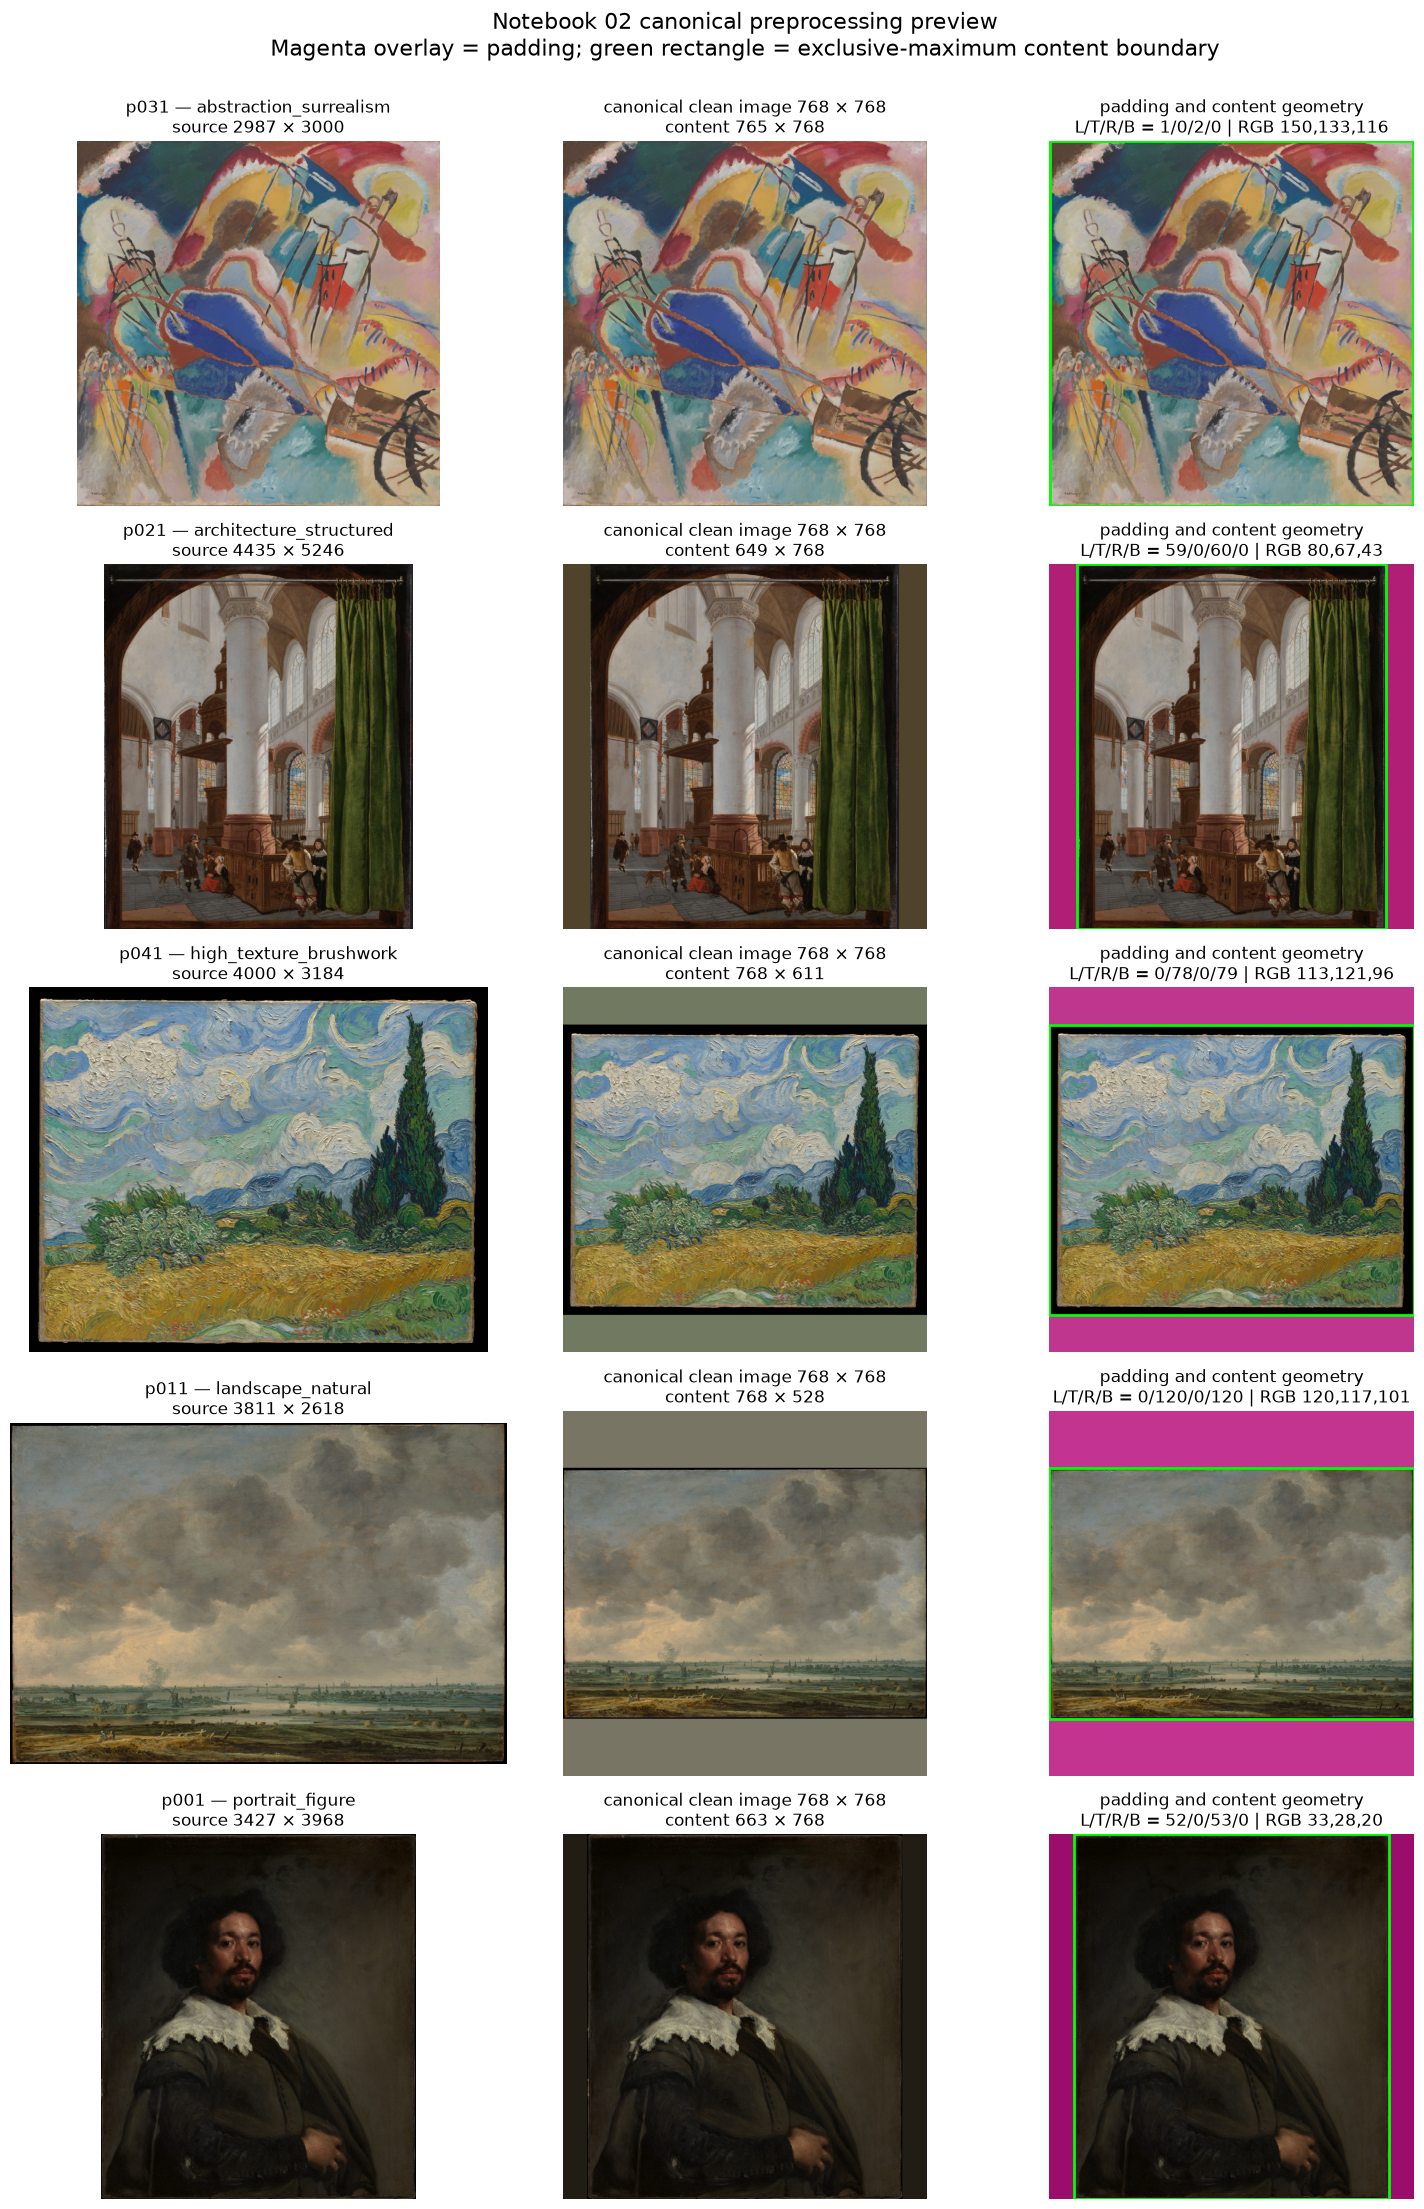

In [14]:
# ---------------------------------------------------------------------------
# Construct and render the canonical preview figure in memory
# ---------------------------------------------------------------------------

canonical_preview_figure, canonical_preview_axes = (
    plt.subplots(
        nrows=len(
            canonical_preview_visuals
        ),
        ncols=3,
        figsize=(
            15,
            4.4
            * len(
                canonical_preview_visuals
            ),
        ),
        squeeze=False,
    )
)

for row_index, preview_visual in enumerate(
    canonical_preview_visuals
):
    source_preview = preview_visual[
        "source_preview"
    ]
    clean_preview = preview_visual[
        "clean_preview"
    ]
    processed_record = preview_visual[
        "processed_record"
    ]

    clean_array = np.asarray(
        clean_preview
    )

    content_bbox = (
        int(
            processed_record[
                "content_x_min"
            ]
        ),
        int(
            processed_record[
                "content_y_min"
            ]
        ),
        int(
            processed_record[
                "content_x_max"
            ]
        ),
        int(
            processed_record[
                "content_y_max"
            ]
        ),
    )

    diagnostic_region = content_region(
        clean_array.shape[:2],
        content_bbox,
    )

    padding_mask = (
        ~diagnostic_region.mask
    )

    diagnostic_array = (
        clean_array.astype(
            np.float32
        )
        .copy()
    )

    diagnostic_array[
        padding_mask
    ] = (
        0.45
        * diagnostic_array[
            padding_mask
        ]
        + 0.55
        * np.array(
            [
                255,
                0,
                180,
            ],
            dtype=np.float32,
        )
    )

    diagnostic_array = np.clip(
        diagnostic_array,
        0,
        255,
    ).astype(
        np.uint8
    )

    source_axis = canonical_preview_axes[
        row_index,
        0,
    ]

    clean_axis = canonical_preview_axes[
        row_index,
        1,
    ]

    diagnostic_axis = (
        canonical_preview_axes[
            row_index,
            2,
        ]
    )

    source_axis.imshow(
        source_preview
    )

    source_axis.set_title(
        f"{preview_visual['painting_id']} — "
        f"{preview_visual['category']}\n"
        f"source "
        f"{processed_record['original_width']} × "
        f"{processed_record['original_height']}"
    )

    clean_axis.imshow(
        clean_preview
    )

    clean_axis.set_title(
        "canonical clean image 768 × 768\n"
        f"content "
        f"{processed_record['content_width']} × "
        f"{processed_record['content_height']}"
    )

    diagnostic_axis.imshow(
        diagnostic_array
    )

    x_min, y_min, x_max, y_max = (
        content_bbox
    )

    diagnostic_axis.add_patch(
        Rectangle(
            (
                x_min,
                y_min,
            ),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            edgecolor="lime",
            linewidth=2.0,
        )
    )

    diagnostic_axis.set_title(
        "padding and content geometry\n"
        f"L/T/R/B = "
        f"{processed_record['pad_left']}/"
        f"{processed_record['pad_top']}/"
        f"{processed_record['pad_right']}/"
        f"{processed_record['pad_bottom']} | "
        f"RGB "
        f"{processed_record['padding_color_r']},"
        f"{processed_record['padding_color_g']},"
        f"{processed_record['padding_color_b']}"
    )

    for axis in (
        source_axis,
        clean_axis,
        diagnostic_axis,
    ):
        axis.set_axis_off()

canonical_preview_figure.suptitle(
    "Notebook 02 canonical preprocessing preview\n"
    "Magenta overlay = padding; "
    "green rectangle = exclusive-maximum content boundary",
    fontsize=16,
    y=1.002,
)

canonical_preview_figure.tight_layout()

# Force an in-memory canvas draw before validating the figure.
canonical_preview_figure.canvas.draw()

canonical_preview_canvas_size = (
    canonical_preview_figure
    .canvas
    .get_width_height()
)

plt.show()

In [15]:
# ---------------------------------------------------------------------------
# Eight final consolidated checks
# ---------------------------------------------------------------------------

AUDIT_PREVIEW_VALIDATION_STAGE = (
    "audit_and_preview"
)


# 1. Audit schema

preprocessing_audit_schema_result = (
    validate_dataframe(
        preprocessing_audit_df,
        PREPROCESSING_AUDIT_SCHEMA,
        allow_extra_columns=False,
    )
)

preprocessing_audit_schema_passed = (
    preprocessing_audit_schema_result.passed
    and not preprocessing_audit_schema_result
    .unexpected_columns
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="preprocessing_audit_schema",
    check_description=(
        "The preprocessing audit satisfies the exact "
        "preprocessing_audit.v1 schema."
    ),
    severity="blocking",
    expected={
        "schema_version": PREPROCESSING_AUDIT_SCHEMA.version,
        "missing_columns": [],
        "unexpected_columns": [],
        "duplicate_primary_key_rows": 0,
    },
    observed=(
        preprocessing_audit_schema_result
        .to_dict()
    ),
    passed=preprocessing_audit_schema_passed,
)


# 2. Audit row identities and structure

expected_audit_row_count = int(
    preprocessing_config[
        "expected"
    ]["audit_row_count"]
)

expected_audit_ids = [
    f"preprocess_audit_{index:03d}"
    for index in range(
        1,
        expected_audit_row_count + 1,
    )
]

audit_structure_passed = (
    len(preprocessing_audit_df)
    == expected_audit_row_count
    and len(global_audit_df)
    == GLOBAL_AUDIT_METRIC_COUNT
    and len(category_audit_df)
    == (
        len(
            preprocessing_config[
                "expected"
            ]["categories"]
        )
        * len(
            GROUPED_AUDIT_METRICS
        )
    )
    and preprocessing_audit_df[
        "audit_row_id"
    ].astype(str).tolist()
    == expected_audit_ids
    and not preprocessing_audit_df[
        "audit_row_id"
    ].duplicated().any()
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="preprocessing_audit_structure",
    check_description=(
        "Audit cardinality, sequential identifiers, global rows, "
        "and category rows match the approved 45-row design."
    ),
    severity="blocking",
    expected={
        "total_rows": expected_audit_row_count,
        "global_rows": GLOBAL_AUDIT_METRIC_COUNT,
        "category_rows": (
            len(
                preprocessing_config[
                    "expected"
                ]["categories"]
            )
            * len(
                GROUPED_AUDIT_METRICS
            )
        ),
        "duplicate_audit_ids": 0,
    },
    observed={
        "total_rows": len(
            preprocessing_audit_df
        ),
        "global_rows": len(
            global_audit_df
        ),
        "category_rows": len(
            category_audit_df
        ),
        "duplicate_audit_ids": int(
            preprocessing_audit_df[
                "audit_row_id"
            ].duplicated(
                keep=False
            ).sum()
        ),
    },
    passed=audit_structure_passed,
)


# 3. Global audit reconciliation

observed_global_metric_names = set(
    global_audit_df[
        "metric_name"
    ].astype(str)
)

expected_global_metric_names = set(
    expected_global_audit_values
)

global_metric_name_passed = (
    observed_global_metric_names
    == expected_global_metric_names
)

global_audit_failures = []

if global_metric_name_passed:
    observed_global_audit_values = {
        str(row.metric_name): float(
            row.metric_value
        )
        for row in global_audit_df.itertuples(
            index=False
        )
    }

    for metric_name, expected_value in (
        expected_global_audit_values.items()
    ):
        observed_value = (
            observed_global_audit_values[
                metric_name
            ]
        )

        if not np.isclose(
            observed_value,
            float(expected_value),
            rtol=0,
            atol=1e-12,
        ):
            global_audit_failures.append(
                {
                    "metric_name": metric_name,
                    "expected": float(
                        expected_value
                    ),
                    "observed": observed_value,
                }
            )
else:
    global_audit_failures.append(
        {
            "missing_metric_names": sorted(
                expected_global_metric_names
                - observed_global_metric_names
            ),
            "unexpected_metric_names": sorted(
                observed_global_metric_names
                - expected_global_metric_names
            ),
        }
    )

global_audit_passed = (
    not global_audit_failures
    and (
        global_audit_df[
            "status"
        ].astype(str)
        == "passed"
    ).all()
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="global_audit_reconciliation",
    check_description=(
        "All 25 global audit metrics reconcile with current "
        "tables, files, policies, validation, and runtimes."
    ),
    severity="blocking",
    expected={
        "metric_count": GLOBAL_AUDIT_METRIC_COUNT,
        "metric_failures": 0,
        "nonpassed_statuses": 0,
    },
    observed={
        "metric_count": len(
            global_audit_df
        ),
        "metric_failures": len(
            global_audit_failures
        ),
        "nonpassed_statuses": int(
            (
                global_audit_df[
                    "status"
                ].astype(str)
                != "passed"
            ).sum()
        ),
    },
    passed=global_audit_passed,
    details=global_audit_failures,
)


# 4. Category audit reconciliation

category_reconciliation_failures = (
    category_audit_reconciliation_df.loc[
        (
            category_audit_reconciliation_df[
                "_merge"
            ] != "both"
        )
        | ~category_audit_reconciliation_df[
            "metric_value_matches"
        ]
        | ~category_audit_reconciliation_df[
            "denominator_matches"
        ]
        | (
            category_audit_reconciliation_df[
                "group_field"
            ].astype(str)
            != "category"
        )
        | (
            category_audit_reconciliation_df[
                "status"
            ].astype(str)
            != "passed"
        ),
        [
            "group_value",
            "metric_name",
            "metric_value",
            "expected_metric_value",
            "denominator",
            "expected_denominator",
            "group_field",
            "status",
            "_merge",
        ],
    ].to_dict(
        orient="records"
    )
)

category_audit_passed = (
    len(
        category_audit_reconciliation_df
    )
    == (
        len(
            preprocessing_config[
                "expected"
            ]["categories"]
        )
        * len(
            GROUPED_AUDIT_METRICS
        )
    )
    and not category_reconciliation_failures
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="category_audit_reconciliation",
    check_description=(
        "All four audit metrics for every configured category "
        "reconcile with the normalized preprocessing table."
    ),
    severity="blocking",
    expected={
        "category_count": len(
            preprocessing_config[
                "expected"
            ]["categories"]
        ),
        "metrics_per_category": len(
            GROUPED_AUDIT_METRICS
        ),
        "reconciliation_failures": 0,
    },
    observed={
        "category_count": int(
            category_audit_df[
                "group_value"
            ].nunique()
        ),
        "metrics_per_category": int(
            category_audit_df[
                "metric_name"
            ].nunique()
        ),
        "reconciliation_failures": len(
            category_reconciliation_failures
        ),
    },
    passed=category_audit_passed,
    details=category_reconciliation_failures,
)


# 5. Deterministic preview selection

expected_preview_categories = sorted(
    preprocessing_config[
        "expected"
    ]["categories"]
)

observed_preview_categories = sorted(
    preview_selection_df[
        "category"
    ].astype(str).tolist()
)

preview_selection_passed = (
    len(preview_selection_df)
    == len(
        expected_preview_categories
    )
    and preview_selection_df[
        "painting_id"
    ].nunique()
    == len(
        expected_preview_categories
    )
    and preview_selection_df[
        "category"
    ].nunique()
    == len(
        expected_preview_categories
    )
    and observed_preview_categories
    == expected_preview_categories
    and preview_selection_deterministic
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="canonical_preview_selection",
    check_description=(
        "Canonical preview selection contains one deterministic "
        "painting per configured category."
    ),
    severity="blocking",
    expected={
        "painting_count": len(
            expected_preview_categories
        ),
        "categories": (
            expected_preview_categories
        ),
        "repeat_selection_matches": True,
    },
    observed={
        "painting_count": len(
            preview_selection_df
        ),
        "categories": (
            observed_preview_categories
        ),
        "painting_ids": (
            preview_selection_df[
                "painting_id"
            ].tolist()
        ),
        "repeat_selection_matches": (
            preview_selection_deterministic
        ),
    },
    passed=preview_selection_passed,
)


# 6. Preview source reload

preview_source_failures = (
    canonical_preview_records_df.loc[
        ~canonical_preview_records_df[
            "source_reload_passed"
        ],
        [
            "painting_id",
            "category",
            "source_reload_passed",
        ],
    ].to_dict(
        orient="records"
    )
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="canonical_preview_sources",
    check_description=(
        "Every canonical-preview source reloads with its "
        "declared dimensions, RGB mode, and JPEG format."
    ),
    severity="blocking",
    expected="zero preview source failures",
    observed=len(
        preview_source_failures
    ),
    passed=not preview_source_failures,
    details=preview_source_failures,
)


# 7. Preview clean-image and geometry reconciliation

preview_clean_geometry_failures = (
    canonical_preview_records_df.loc[
        ~(
            canonical_preview_records_df[
                "clean_reload_passed"
            ]
            & canonical_preview_records_df[
                "geometry_passed"
            ]
        ),
        [
            "painting_id",
            "category",
            "clean_reload_passed",
            "geometry_passed",
            "content_bbox",
            "padding_color",
        ],
    ].to_dict(
        orient="records"
    )
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="canonical_preview_geometry",
    check_description=(
        "Every canonical-preview clean image reloads and its "
        "content boundary and padding pixels reconcile."
    ),
    severity="blocking",
    expected="zero preview clean-image or geometry failures",
    observed=len(
        preview_clean_geometry_failures
    ),
    passed=not preview_clean_geometry_failures,
    details=preview_clean_geometry_failures,
)


# 8. Canonical figure render

canonical_figure_render_passed = (
    canonical_preview_figure is not None
    and canonical_preview_axes.shape
    == (
        len(
            canonical_preview_visuals
        ),
        3,
    )
    and len(
        canonical_preview_figure.axes
    )
    == (
        len(
            canonical_preview_visuals
        )
        * 3
    )
    and canonical_preview_canvas_size[0]
    > 0
    and canonical_preview_canvas_size[1]
    > 0
)

VALIDATION.add(
    validation_stage=AUDIT_PREVIEW_VALIDATION_STAGE,
    check_id="canonical_preview_render",
    check_description=(
        "The canonical three-panel preview renders one row "
        "per selected category with a valid canvas."
    ),
    severity="blocking",
    expected={
        "preview_rows": len(
            expected_preview_categories
        ),
        "columns": 3,
        "axes": (
            len(
                expected_preview_categories
            )
            * 3
        ),
        "positive_canvas_dimensions": True,
    },
    observed={
        "preview_rows": (
            canonical_preview_axes.shape[0]
        ),
        "columns": (
            canonical_preview_axes.shape[1]
        ),
        "axes": len(
            canonical_preview_figure.axes
        ),
        "canvas_size": (
            canonical_preview_canvas_size
        ),
    },
    passed=canonical_figure_render_passed,
)


# ---------------------------------------------------------------------------
# Final planned consolidated validation summary
# ---------------------------------------------------------------------------

cumulative_checks_df = VALIDATION.to_dataframe()

batch6_checks_df = cumulative_checks_df.loc[
    cumulative_checks_df[
        "validation_stage"
    ] == AUDIT_PREVIEW_VALIDATION_STAGE
].reset_index(drop=True)

if len(batch6_checks_df) != 8:
    raise RuntimeError(
        "Batch 6 should add exactly eight audit/preview checks; "
        f"found {len(batch6_checks_df)}."
    )

if len(cumulative_checks_df) != 50:
    raise RuntimeError(
        "The planned consolidated validation table should now "
        f"contain exactly 50 checks; found {len(cumulative_checks_df)}."
    )

print("Batch 6 audit and preview checks:")
display(
    batch6_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print("\nGlobal preprocessing audit:")
display(
    global_audit_df[
        [
            "audit_row_id",
            "metric_name",
            "metric_value",
            "metric_unit",
            "status",
        ]
    ]
)

print("\nCategory preprocessing audit:")
display(
    category_audit_df[
        [
            "group_value",
            "metric_name",
            "metric_value",
            "metric_unit",
            "denominator",
            "status",
        ]
    ]
)

print("\nCanonical preview records:")
display(
    canonical_preview_records_df
)

VALIDATION.raise_for_blocking()

print("\nBatch 6 completed successfully.")
print("Batch 6 checks:", len(batch6_checks_df))
print("Final consolidated checks:", len(cumulative_checks_df))
print("Separate smoke checks:", len(smoke_checks_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("Audit rows held in memory:", len(preprocessing_audit_df))
print("Canonical preview held in memory: True")
print("No new artifact has been persisted.")
print(
    "Next approved stage: Batch 7 — "
    "atomic canonical persistence and manifest generation."
)

Batch 6 audit and preview checks:


,check_id,severity,expected,observed,passed
0,preprocessing_audit_schema,blocking,"{""duplicate_primary_key_rows"": 0, ""missing_col...","{""column_count"": 14, ""duplicate_primary_key_ro...",True
1,preprocessing_audit_structure,blocking,"{""category_rows"": 20, ""duplicate_audit_ids"": 0...","{""category_rows"": 20, ""duplicate_audit_ids"": 0...",True
2,global_audit_reconciliation,blocking,"{""metric_count"": 25, ""metric_failures"": 0, ""no...","{""metric_count"": 25, ""metric_failures"": 0, ""no...",True
3,category_audit_reconciliation,blocking,"{""category_count"": 5, ""metrics_per_category"": ...","{""category_count"": 5, ""metrics_per_category"": ...",True
4,canonical_preview_selection,blocking,"{""categories"": [""abstraction_surrealism"", ""arc...","{""categories"": [""abstraction_surrealism"", ""arc...",True
5,canonical_preview_sources,blocking,zero preview source failures,0,True
6,canonical_preview_geometry,blocking,zero preview clean-image or geometry failures,0,True
7,canonical_preview_render,blocking,"{""axes"": 15, ""columns"": 3, ""positive_canvas_di...","{""axes"": 15, ""canvas_size"": [1500, 2200], ""col...",True



Global preprocessing audit:


,audit_row_id,metric_name,metric_value,metric_unit,status
0,preprocess_audit_001,accepted_input_count,50.000000,count,passed
1,preprocess_audit_002,processed_output_count,50.000000,count,passed
2,preprocess_audit_003,failed_output_count,0.000000,count,passed
3,preprocess_audit_004,missing_output_count,0.000000,count,passed
4,preprocess_audit_005,stale_output_count,0.000000,count,passed
5,preprocess_audit_006,duplicate_sha256_group_count,0.000000,count,passed
6,preprocess_audit_007,orphan_output_count,0.000000,count,passed
7,preprocess_audit_008,reload_failure_count,0.000000,count,passed
8,preprocess_audit_009,output_width_nonconforming_count,0.000000,count,passed
9,preprocess_audit_010,output_height_nonconforming_count,0.000000,count,passed



Category preprocessing audit:


,group_value,metric_name,metric_value,metric_unit,denominator,status
0,portrait_figure,processed_count,10.000000,count,10,passed
1,portrait_figure,mean_content_area_fraction,0.775260,fraction,10,passed
2,portrait_figure,mean_padding_area_fraction,0.224740,fraction,10,passed
3,portrait_figure,median_resize_scale,0.192774,ratio,10,passed
4,landscape_natural,processed_count,10.000000,count,10,passed
5,landscape_natural,mean_content_area_fraction,0.700260,fraction,10,passed
6,landscape_natural,mean_padding_area_fraction,0.299740,fraction,10,passed
7,landscape_natural,median_resize_scale,0.200191,ratio,10,passed
8,architecture_structured,processed_count,10.000000,count,10,passed
9,architecture_structured,mean_content_area_fraction,0.742188,fraction,10,passed



Canonical preview records:


,painting_id,category,source_reload_passed,clean_reload_passed,geometry_passed,content_bbox,content_area_fraction,padding_area_fraction,padding_color
0,p031,abstraction_surrealism,True,True,True,"(1, 0, 766, 768)",0.996094,0.003906,"(150, 133, 116)"
1,p021,architecture_structured,True,True,True,"(59, 0, 708, 768)",0.845052,0.154948,"(80, 67, 43)"
2,p041,high_texture_brushwork,True,True,True,"(0, 78, 768, 689)",0.795573,0.204427,"(113, 121, 96)"
3,p011,landscape_natural,True,True,True,"(0, 120, 768, 648)",0.687500,0.312500,"(120, 117, 101)"
4,p001,portrait_figure,True,True,True,"(52, 0, 715, 768)",0.863281,0.136719,"(33, 28, 20)"



Batch 6 completed successfully.
Batch 6 checks: 8
Final consolidated checks: 50
Separate smoke checks: 6
Blocking failures: 0
Audit rows held in memory: 45
Canonical preview held in memory: True
No new artifact has been persisted.
Next approved stage: Batch 7 — atomic canonical persistence and manifest generation.


## Batch 7 — Canonical Persistence and Manifest Handoff

This batch atomically persists the validated canonical outputs:

- `data/preprocessed_images.csv`
- `metrics/preprocessing_audit.csv`
- `figures/preprocessing_preview.png`
- `validation/checks.csv`

It then creates:

- the normalized five-row artifact manifest;
- the provisional reproducibility run manifest;
- immediate reload, checksum, ownership, and exact-output-set evidence.

The artifact manifest records the five externally meaningful scientific and validation artifacts:

1. the canonical preprocessing table;
2. the 50-image clean PNG collection;
3. the preprocessing audit;
4. the canonical preprocessing preview;
5. the consolidated validation table.

The artifact manifest does not recursively register itself or the run manifest.

The run manifest remains in `running` state with `completion_gate_passed: false` until Batch 8 verifies the complete notebook contract and updates the global project-path registry.

In [16]:
# ---------------------------------------------------------------------------
# Batch 7 helper imports
# ---------------------------------------------------------------------------

from restoration_eval.dataset_verification import (
    write_dataframe_atomic,
)

from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


# ---------------------------------------------------------------------------
# Pre-persistence gate
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The 50-check consolidated validation gate has not passed."
    )

if not SMOKE_VALIDATION.overall_passed:
    raise RuntimeError(
        "The separate representative smoke gate has not passed."
    )

validation_checks_df = VALIDATION.to_dataframe()

if len(validation_checks_df) != 50:
    raise RuntimeError(
        "Exactly 50 consolidated validation rows are required; "
        f"found {len(validation_checks_df)}."
    )

if len(preprocessed_images_df) != EXPECTED_PAINTING_COUNT:
    raise RuntimeError(
        "The canonical preprocessing table does not contain the "
        f"expected {EXPECTED_PAINTING_COUNT} rows."
    )

expected_audit_row_count = int(
    preprocessing_config["expected"]["audit_row_count"]
)

if len(preprocessing_audit_df) != expected_audit_row_count:
    raise RuntimeError(
        "The preprocessing audit does not contain the expected "
        f"{expected_audit_row_count} rows."
    )

if canonical_preview_figure is None:
    raise RuntimeError(
        "The canonical preprocessing preview is not available in memory."
    )


# ---------------------------------------------------------------------------
# Validate ownership of every declared output target
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in OUTPUT_PATHS.items():
    try:
        validated_path = require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        if validated_path != output_path.resolve():
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(output_path),
                    "issue": "resolved_path_mismatch",
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(output_path),
                "issue": f"{type(exc).__name__}: {exc}",
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more output paths violate notebook ownership: "
        f"{output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Atomic canonical table persistence
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    preprocessed_images_df,
    OUTPUT_PATHS["preprocessed_images"],
)

write_dataframe_atomic(
    preprocessing_audit_df,
    OUTPUT_PATHS["preprocessing_audit"],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUT_PATHS["validation_checks"],
)


# ---------------------------------------------------------------------------
# Atomic canonical preview persistence
# ---------------------------------------------------------------------------

preview_target = OUTPUT_PATHS["preprocessing_preview"]

preview_temporary = preview_target.with_name(
    f".{preview_target.stem}.tmp{preview_target.suffix}"
)

try:
    canonical_preview_figure.savefig(
        preview_temporary,
        dpi=int(
            preprocessing_config["preview"]["figure_dpi"]
        ),
        bbox_inches="tight",
        facecolor="white",
        metadata={
            "Title": (
                "Notebook 02 Canonical Preprocessing Preview"
            ),
            "Creator": NOTEBOOK_STEM,
        },
    )

    preview_temporary.replace(preview_target)

finally:
    preview_temporary.unlink(missing_ok=True)


# ---------------------------------------------------------------------------
# Immediate canonical reload
# ---------------------------------------------------------------------------

preprocessed_images_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["preprocessed_images"],
    low_memory=False,
)

preprocessing_audit_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["preprocessing_audit"],
    low_memory=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["validation_checks"],
    low_memory=False,
)

preprocessed_reload_schema_result = validate_dataframe(
    preprocessed_images_reloaded_df,
    PREPROCESSED_IMAGES_SCHEMA,
    allow_extra_columns=False,
)

preprocessing_audit_reload_schema_result = validate_dataframe(
    preprocessing_audit_reloaded_df,
    PREPROCESSING_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

validation_reload_schema_result = validate_dataframe(
    validation_checks_reloaded_df,
    VALIDATION_CHECKS_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Reloaded identity evidence
# ---------------------------------------------------------------------------

expected_processed_ids = set(
    preprocessed_images_df["processed_image_id"].astype(str)
)

reloaded_processed_ids = set(
    preprocessed_images_reloaded_df[
        "processed_image_id"
    ].astype(str)
)

expected_painting_ids = set(
    preprocessed_images_df["painting_id"].astype(str)
)

reloaded_painting_ids = set(
    preprocessed_images_reloaded_df[
        "painting_id"
    ].astype(str)
)

expected_audit_ids = set(
    preprocessing_audit_df["audit_row_id"].astype(str)
)

reloaded_audit_ids = set(
    preprocessing_audit_reloaded_df[
        "audit_row_id"
    ].astype(str)
)

expected_validation_keys = {
    (
        str(check.validation_stage),
        str(check.check_id),
    )
    for check in VALIDATION.checks
}

reloaded_validation_keys = {
    (
        str(row.validation_stage),
        str(row.check_id),
    )
    for row in validation_checks_reloaded_df.itertuples(
        index=False
    )
}

reloaded_passed_values = (
    validation_checks_reloaded_df["passed"]
    .astype(str)
    .str.strip()
    .str.lower()
)

all_reloaded_checks_passed = bool(
    reloaded_passed_values.eq("true").all()
)


# ---------------------------------------------------------------------------
# Reload canonical preview
# ---------------------------------------------------------------------------

with Image.open(preview_target) as preview_reloaded:
    preview_reloaded.load()

    preview_reload_evidence = {
        "format": str(preview_reloaded.format),
        "mode": str(preview_reloaded.mode),
        "width": int(preview_reloaded.width),
        "height": int(preview_reloaded.height),
    }

preview_checksum = sha256_file(preview_target)

preview_reload_passed = (
    preview_reload_evidence["format"] == "PNG"
    and preview_reload_evidence["mode"] in {"RGB", "RGBA"}
    and preview_reload_evidence["width"] > 0
    and preview_reload_evidence["height"] > 0
    and len(preview_checksum) == 64
)


# ---------------------------------------------------------------------------
# Separate persistence-validation gate
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = ValidationCollector()

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="output_path_ownership",
    check_description=(
        "Every declared output path remains inside the exact "
        "Notebook 02 output root."
    ),
    severity="blocking",
    expected="zero ownership failures",
    observed=output_ownership_failures,
    passed=not output_ownership_failures,
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="preprocessed_images_csv_reload",
    check_description=(
        "Persisted preprocessed_images.csv reloads under "
        "preprocessed_images.v1 with the expected identities."
    ),
    severity="blocking",
    expected={
        "rows": EXPECTED_PAINTING_COUNT,
        "schema_passed": True,
        "processed_ids_match": True,
        "painting_ids_match": True,
    },
    observed={
        "rows": len(preprocessed_images_reloaded_df),
        "schema": preprocessed_reload_schema_result.to_dict(),
        "processed_ids_match": (
            reloaded_processed_ids == expected_processed_ids
        ),
        "painting_ids_match": (
            reloaded_painting_ids == expected_painting_ids
        ),
    },
    passed=(
        preprocessed_reload_schema_result.passed
        and len(preprocessed_images_reloaded_df)
        == EXPECTED_PAINTING_COUNT
        and reloaded_processed_ids == expected_processed_ids
        and reloaded_painting_ids == expected_painting_ids
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="preprocessing_audit_csv_reload",
    check_description=(
        "Persisted preprocessing_audit.csv reloads under "
        "preprocessing_audit.v1 with all expected audit identities."
    ),
    severity="blocking",
    expected={
        "rows": expected_audit_row_count,
        "schema_passed": True,
        "audit_ids_match": True,
    },
    observed={
        "rows": len(preprocessing_audit_reloaded_df),
        "schema": (
            preprocessing_audit_reload_schema_result.to_dict()
        ),
        "audit_ids_match": (
            reloaded_audit_ids == expected_audit_ids
        ),
    },
    passed=(
        preprocessing_audit_reload_schema_result.passed
        and len(preprocessing_audit_reloaded_df)
        == expected_audit_row_count
        and reloaded_audit_ids == expected_audit_ids
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="validation_checks_csv_reload",
    check_description=(
        "Persisted checks.csv reloads under validation_checks.v1 "
        "with all 50 expected passing check identities."
    ),
    severity="blocking",
    expected={
        "rows": 50,
        "schema_passed": True,
        "keys_match": True,
        "all_passed": True,
    },
    observed={
        "rows": len(validation_checks_reloaded_df),
        "schema": validation_reload_schema_result.to_dict(),
        "keys_match": (
            reloaded_validation_keys == expected_validation_keys
        ),
        "all_passed": all_reloaded_checks_passed,
    },
    passed=(
        validation_reload_schema_result.passed
        and len(validation_checks_reloaded_df) == 50
        and reloaded_validation_keys == expected_validation_keys
        and all_reloaded_checks_passed
    ),
)

PERSISTENCE_VALIDATION.add(
    validation_stage="canonical_persistence",
    check_id="preprocessing_preview_reload",
    check_description=(
        "The canonical preprocessing preview reloads as a readable "
        "non-empty PNG with a stable SHA-256 checksum."
    ),
    severity="blocking",
    expected={
        "format": "PNG",
        "mode": ["RGB", "RGBA"],
        "positive_dimensions": True,
        "sha256_length": 64,
    },
    observed={
        **preview_reload_evidence,
        "sha256": preview_checksum,
    },
    passed=preview_reload_passed,
)

persistence_checks_df = (
    PERSISTENCE_VALIDATION.to_dataframe()
)

if len(persistence_checks_df) != 5:
    raise RuntimeError(
        "Batch 7 should produce exactly 5 separate persistence checks; "
        f"found {len(persistence_checks_df)}."
    )

PERSISTENCE_VALIDATION.raise_for_blocking()

if len(VALIDATION.checks) != 50:
    raise RuntimeError(
        "Persistence checks must not modify the approved "
        f"50 consolidated checks; found {len(VALIDATION.checks)}."
    )

plt.close(canonical_preview_figure)

print("Canonical tables and preview persisted and reloaded.")
print(
    "Persistence validation passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)

display(
    persistence_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Canonical tables and preview persisted and reloaded.
Persistence validation passed: True


,check_id,severity,passed
0,output_path_ownership,blocking,True
1,preprocessed_images_csv_reload,blocking,True
2,preprocessing_audit_csv_reload,blocking,True
3,validation_checks_csv_reload,blocking,True
4,preprocessing_preview_reload,blocking,True


In [17]:
# ---------------------------------------------------------------------------
# Five externally meaningful artifact records
# ---------------------------------------------------------------------------

dataset_scope = str(
    preprocessing_config["dataset"]["dataset_scope"]
)

artifact_specifications = [
    {
        "artifact_key": "preprocessed_images",
        "path": OUTPUT_PATHS["preprocessed_images"],
        "artifact_type": "dataset_table",
        "artifact_role": OUTPUTS[
            "preprocessed_images"
        ]["artifact_role"],
        "schema_version": PREPROCESSED_IMAGES_SCHEMA.version,
        "row_count": len(preprocessed_images_reloaded_df),
    },
    {
        "artifact_key": "clean_images",
        "path": OUTPUT_PATHS["clean_images"],
        "artifact_type": "image_collection",
        "artifact_role": OUTPUTS[
            "clean_images"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "clean_images"
        ]["schema_version"],
        "row_count": len(preprocessed_images_reloaded_df),
    },
    {
        "artifact_key": "preprocessing_audit",
        "path": OUTPUT_PATHS["preprocessing_audit"],
        "artifact_type": "audit_table",
        "artifact_role": OUTPUTS[
            "preprocessing_audit"
        ]["artifact_role"],
        "schema_version": PREPROCESSING_AUDIT_SCHEMA.version,
        "row_count": len(preprocessing_audit_reloaded_df),
    },
    {
        "artifact_key": "preprocessing_preview",
        "path": OUTPUT_PATHS["preprocessing_preview"],
        "artifact_type": "figure",
        "artifact_role": OUTPUTS[
            "preprocessing_preview"
        ]["artifact_role"],
        "schema_version": OUTPUTS[
            "preprocessing_preview"
        ]["schema_version"],
        "row_count": None,
    },
    {
        "artifact_key": "validation_checks",
        "path": OUTPUT_PATHS["validation_checks"],
        "artifact_type": "validation_table",
        "artifact_role": OUTPUTS[
            "validation_checks"
        ]["artifact_role"],
        "schema_version": VALIDATION_CHECKS_SCHEMA.version,
        "row_count": len(validation_checks_reloaded_df),
    },
]

artifact_records = [
    build_artifact_record(
        artifact_key=specification["artifact_key"],
        producer_notebook=NOTEBOOK_STEM,
        path=specification["path"],
        artifact_type=specification["artifact_type"],
        artifact_role=specification["artifact_role"],
        schema_version=specification["schema_version"],
        dataset_scope=dataset_scope,
        experiment_id="",
        validation_status="passed",
        row_count=specification["row_count"],
        project_root=PROJECT_ROOT,
    )
    for specification in artifact_specifications
]

artifact_manifest_df = artifact_records_dataframe(
    artifact_records
)

if len(artifact_manifest_df) != 5:
    raise RuntimeError(
        "The normalized artifact manifest must contain exactly "
        f"5 records; found {len(artifact_manifest_df)}."
    )

write_artifact_manifest(
    OUTPUT_PATHS["artifact_manifest"],
    artifact_records,
)


# ---------------------------------------------------------------------------
# Reproducibility and run-state evidence
# ---------------------------------------------------------------------------

configuration_paths = [
    to_repo_relative(
        PREPROCESSING_CONFIG_PATH,
        PROJECT_ROOT,
    )
]

configuration_checksums_by_path = configuration_checksums(
    [
        PREPROCESSING_CONFIG_PATH,
    ],
    PROJECT_ROOT,
)

run_inputs = [
    {
        "input_key": input_key,
        **input_contract,
    }
    for input_key, input_contract in INPUTS.items()
]

run_outputs = [
    {
        "output_key": output_key,
        **output_contract,
    }
    for output_key, output_contract in OUTPUTS.items()
]

expected_run_counts = {
    "accepted_input_rows": int(
        preprocessing_config["expected"]["accepted_input_count"]
    ),
    "processed_output_rows": int(
        preprocessing_config["expected"]["processed_output_count"]
    ),
    "clean_image_files": int(
        preprocessing_config["expected"]["processed_output_count"]
    ),
    "preprocessing_audit_rows": int(
        preprocessing_config["expected"]["audit_row_count"]
    ),
    "validation_rows": int(
        OUTPUTS["validation_checks"]["expected_cardinality"]
    ),
    "artifact_records": int(
        OUTPUTS["artifact_manifest"]["expected_cardinality"]
    ),
    "canonical_figures": 1,
}

global_metric_values = {
    str(row.metric_name): float(row.metric_value)
    for row in global_audit_df.itertuples(index=False)
}

observed_padding_orientations = {
    str(key): int(value)
    for key, value in (
        preprocessed_images_reloaded_df[
            [
                "pad_left",
                "pad_top",
                "pad_right",
                "pad_bottom",
            ]
        ]
        .apply(
            lambda row: (
                "none"
                if int(row.sum()) == 0
                else (
                    "left_right"
                    if int(row["pad_left"])
                    + int(row["pad_right"])
                    > 0
                    else "top_bottom"
                )
            ),
            axis=1,
        )
        .value_counts()
        .sort_index()
        .items()
    )
}

observed_run_counts = {
    "accepted_input_rows": len(accepted_artworks_df),
    "processed_output_rows": len(
        preprocessed_images_reloaded_df
    ),
    "clean_image_files": len(
        list(CLEAN_IMAGE_DIRECTORY.glob("*.png"))
    ),
    "preprocessing_audit_rows": len(
        preprocessing_audit_reloaded_df
    ),
    "validation_rows": len(validation_checks_reloaded_df),
    "artifact_records": len(artifact_manifest_df),
    "canonical_figures": 1,
    "failed_outputs": int(
        global_metric_values["failed_output_count"]
    ),
    "missing_outputs": int(
        global_metric_values["missing_output_count"]
    ),
    "stale_outputs": int(
        global_metric_values["stale_output_count"]
    ),
    "orphan_outputs": int(
        global_metric_values["orphan_output_count"]
    ),
    "source_icc_missing": int(
        global_metric_values["source_icc_missing_count"]
    ),
    "source_icc_srgb": int(
        global_metric_values["source_icc_srgb_count"]
    ),
    "source_icc_nonsrgb": int(
        global_metric_values["source_icc_nonsrgb_count"]
    ),
    "output_icc_present": int(
        global_metric_values["output_icc_present_count"]
    ),
    "total_runtime_seconds": float(
        global_metric_values["total_runtime_seconds"]
    ),
    "mean_runtime_seconds": float(
        global_metric_values["mean_runtime_seconds"]
    ),
    "padding_orientations": observed_padding_orientations,
}

known_limitations = [
    str(item)
    for item in upstream_run_manifest.get(
        "known_limitations",
        [],
    )
]

known_limitations.extend(
    [
        (
            "Images without embedded ICC profiles are processed under "
            "the configured sRGB assumption without pixel conversion."
        ),
        (
            "Median-RGB padding is technical model-canvas content and "
            "must be excluded from region-sensitive evaluation through "
            "the recorded content bounding box."
        ),
        (
            "Preprocessing verifies deterministic technical geometry; "
            "it does not certify historical, aesthetic, or conservation "
            "validity."
        ),
        (
            "Recorded preprocessing runtimes are specific to the current "
            "CPU, storage, Python environment, and system load."
        ),
    ]
)

known_limitations = list(
    dict.fromkeys(
        limitation
        for limitation in known_limitations
        if limitation.strip()
    )
)

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run["inventory_run_id"]
    ),
    dataset_versions={
        "dataset_id": preprocessing_config[
            "dataset"
        ]["dataset_id"],
        "dataset_version": preprocessing_config[
            "dataset"
        ]["dataset_version"],
        "dataset_scope": dataset_scope,
        "execution_profile": preprocessing_config[
            "dataset"
        ]["execution_profile"],
        "content_fingerprint": upstream_dataset_versions[
            "content_fingerprint"
        ],
        "fingerprint_version": upstream_dataset_versions.get(
            "fingerprint_version",
            "",
        ),
        "upstream_run_id": upstream_run_manifest["run_id"],
        "upstream_artworks_schema": ARTWORKS_SCHEMA.version,
        "preprocessed_images_schema": (
            PREPROCESSED_IMAGES_SCHEMA.version
        ),
        "preprocessing_audit_schema": (
            PREPROCESSING_AUDIT_SCHEMA.version
        ),
        "preprocessing_config_schema": (
            PREPROCESSING_CONFIG_SCHEMA_VERSION
        ),
        "clean_image_collection_schema": OUTPUTS[
            "clean_images"
        ]["schema_version"],
        "preprocessing_version": preprocessing_config[
            "processing"
        ]["version"],
    },
    configuration_paths=configuration_paths,
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": VALIDATION.summary(),
        "representative_smoke": (
            SMOKE_VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=known_limitations,
    project_root=PROJECT_ROOT,
    package_names=(
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
        "numpy",
    ),
    hardware={
        "execution_device": "CPU",
        "gpu_required": False,
    },
)

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": (
            "passed_pending_completion_gate"
        ),
        "depends_on": [
            "01_dataset_verification.artworks",
            "01_dataset_verification.artifacts",
            "01_dataset_verification.run_manifest",
            "raw images referenced by artworks",
            "canonical preprocessing configuration",
            "current inventory",
            "project paths registry",
        ],
        "applicable_dataset_scopes": [
            dataset_scope,
        ],
        "applicable_experiment_scopes": [],
        "expensive_execution": False,
        "completion_gate_passed": False,
    }
)

RUN_ID = str(run_manifest["run_id"])

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    run_manifest,
)

print(
    "Artifact manifest written:",
    to_repo_relative(
        OUTPUT_PATHS["artifact_manifest"],
        PROJECT_ROOT,
    ),
)
print(
    "Provisional run manifest written:",
    to_repo_relative(
        OUTPUT_PATHS["run_manifest"],
        PROJECT_ROOT,
    ),
)
print("Provisional run ID:", RUN_ID)
print("Run status:", run_manifest["run_status"])

Artifact manifest written: outputs/02_image_preprocessing/manifests/artifacts.csv
Provisional run manifest written: outputs/02_image_preprocessing/manifests/run_manifest.json
Provisional run ID: run_5e54b2de32934e1c9303e7250b932404
Run status: running


In [18]:
# ---------------------------------------------------------------------------
# Reload normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = pd.read_csv(
    OUTPUT_PATHS["artifact_manifest"],
    low_memory=False,
)

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )

artifact_manifest_reload_result = validate_dataframe(
    artifact_manifest_reloaded_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Artifact-manifest contract and checksum reconciliation
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "preprocessed_images",
    "clean_images",
    "preprocessing_audit",
    "preprocessing_preview",
    "validation_checks",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)

artifact_checksum_failures = []
artifact_path_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": str(
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Run-manifest contract
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)

run_manifest_matches_memory = (
    run_manifest_reloaded == run_manifest
)

run_manifest_state_passed = (
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded["run_status"]
    == "running"
    and not run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == inventory_run["inventory_run_id"]
    and run_manifest_reloaded[
        "dataset_versions"
    ]["content_fingerprint"]
    == upstream_dataset_versions[
        "content_fingerprint"
    ]
    and run_manifest_reloaded[
        "configuration_checksums"
    ]
    == configuration_checksums_by_path
)


# ---------------------------------------------------------------------------
# Exact 56-file Notebook 02 output contract
# ---------------------------------------------------------------------------

expected_clean_relative_paths = set(
    preprocessed_images_reloaded_df[
        "processed_path"
    ].astype(str)
)

expected_noncollection_relative_paths = {
    str(output_contract["relative_path"])
    for output_key, output_contract in OUTPUTS.items()
    if output_key != "clean_images"
}

expected_output_relative_paths = (
    expected_clean_relative_paths
    | expected_noncollection_relative_paths
)

observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

undeclared_output_paths = sorted(
    observed_output_relative_paths
    - expected_output_relative_paths
)

missing_output_paths = sorted(
    expected_output_relative_paths
    - observed_output_relative_paths
)

exact_output_set_passed = (
    not undeclared_output_paths
    and not missing_output_paths
    and len(observed_output_relative_paths)
    == EXPECTED_PAINTING_COUNT + 6
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation
# ---------------------------------------------------------------------------

HANDOFF_VALIDATION = ValidationCollector()

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_manifest_contract",
    check_description=(
        "artifacts.csv satisfies artifact_manifest.v1 and contains "
        "exactly the five declared externally meaningful artifacts."
    ),
    severity="blocking",
    expected=sorted(expected_artifact_keys),
    observed={
        "schema": (
            artifact_manifest_reload_result.to_dict()
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
    },
    passed=(
        artifact_manifest_reload_result.passed
        and len(artifact_manifest_reloaded_df) == 5
        and observed_artifact_keys
        == expected_artifact_keys
    ),
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="artifact_paths_and_checksums",
    check_description=(
        "Every artifact-manifest path is notebook-owned, exists, "
        "and matches its recorded file or directory checksum."
    ),
    severity="blocking",
    expected={
        "path_failures": [],
        "checksum_failures": [],
    },
    observed={
        "path_failures": artifact_path_failures,
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
    passed=(
        not artifact_path_failures
        and not artifact_checksum_failures
    ),
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="provisional_run_manifest",
    check_description=(
        "run_manifest.json reloads under run_manifest.v1 with the "
        "current inventory, dataset fingerprint, configuration "
        "checksum, and pending completion-gate state."
    ),
    severity="blocking",
    expected={
        "missing_required_keys": [],
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_in_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_in_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_passed,
)

HANDOFF_VALIDATION.add(
    validation_stage="manifest_handoff",
    check_id="exact_output_file_set",
    check_description=(
        "The Notebook 02 output root contains exactly the 50 clean "
        "PNGs and six declared canonical non-image outputs, with no "
        "temporary, stale, orphaned, or undeclared files."
    ),
    severity="blocking",
    expected={
        "file_count": EXPECTED_PAINTING_COUNT + 6,
        "undeclared": [],
        "missing": [],
    },
    observed={
        "file_count": len(
            observed_output_relative_paths
        ),
        "undeclared": undeclared_output_paths,
        "missing": missing_output_paths,
    },
    passed=exact_output_set_passed,
)

handoff_checks_df = (
    HANDOFF_VALIDATION.to_dataframe()
)

if len(handoff_checks_df) != 4:
    raise RuntimeError(
        "Batch 7 should produce exactly 4 separate handoff checks; "
        f"found {len(handoff_checks_df)}."
    )

HANDOFF_VALIDATION.raise_for_blocking()

if len(VALIDATION.checks) != 50:
    raise RuntimeError(
        "Handoff checks must not modify the approved "
        f"50 consolidated checks; found {len(VALIDATION.checks)}."
    )

print(
    "Manifest handoff validation passed:",
    HANDOFF_VALIDATION.overall_passed,
)

display(
    handoff_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Manifest handoff validation passed: True


,check_id,severity,passed
0,artifact_manifest_contract,blocking,True
1,artifact_paths_and_checksums,blocking,True
2,provisional_run_manifest,blocking,True
3,exact_output_file_set,blocking,True


In [19]:
# ---------------------------------------------------------------------------
# Compact artifact and provisional-run summary
# ---------------------------------------------------------------------------

artifact_manifest_display_df = (
    artifact_manifest_reloaded_df[
        [
            "artifact_key",
            "artifact_type",
            "artifact_role",
            "relative_path",
            "format",
            "schema_version",
            "row_count",
            "file_count",
            "size_bytes",
            "checksum",
            "validation_status",
        ]
    ]
    .copy()
)

artifact_manifest_display_df[
    "checksum_prefix"
] = (
    artifact_manifest_display_df[
        "checksum"
    ]
    .astype(str)
    .str[:12]
)

artifact_manifest_display_df = (
    artifact_manifest_display_df.drop(
        columns=["checksum"]
    )
)

run_manifest_display_df = pd.DataFrame(
    [
        {
            "run_id": (
                run_manifest_reloaded["run_id"]
            ),
            "run_status": (
                run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "completion_gate_passed": (
                run_manifest_reloaded[
                    "completion_gate_passed"
                ]
            ),
            "dataset_scope": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["dataset_scope"]
            ),
            "preprocessing_version": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["preprocessing_version"]
            ),
            "content_fingerprint_prefix": (
                run_manifest_reloaded[
                    "dataset_versions"
                ]["content_fingerprint"][:12]
            ),
            "inventory_run_id": (
                run_manifest_reloaded[
                    "inventory_run_id"
                ]
            ),
            "git_commit": (
                run_manifest_reloaded[
                    "git_commit"
                ][:12]
            ),
            "git_dirty": (
                run_manifest_reloaded[
                    "git_dirty"
                ]
            ),
            "python_version": (
                run_manifest_reloaded[
                    "python_version"
                ]
            ),
        }
    ]
)

print("Normalized artifact manifest:")
display(artifact_manifest_display_df)

print("Provisional run manifest:")
display(run_manifest_display_df)

print(
    "Persisted output files:",
    len(observed_output_relative_paths),
)
print(
    "Clean PNG files:",
    len(expected_clean_relative_paths),
)
print(
    "Consolidated checks:",
    len(VALIDATION.checks),
)
print(
    "Persistence checks passed:",
    PERSISTENCE_VALIDATION.overall_passed,
)
print(
    "Handoff checks passed:",
    HANDOFF_VALIDATION.overall_passed,
)

print("\nBatch 7 completed successfully.")
print(
    "Next approved stage: Batch 8 — final completion gate, "
    "registry update, and final run-manifest completion."
)

Normalized artifact manifest:


,artifact_key,artifact_type,artifact_role,relative_path,format,schema_version,row_count,file_count,size_bytes,validation_status,checksum_prefix
0,preprocessed_images,dataset_table,primary_downstream,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50.0,1,32706,passed,b6f29c2c7145
1,clean_images,image_collection,primary_downstream,outputs/02_image_preprocessing/images/clean,directory,clean_image_collection.v1,50.0,50,36126399,passed,287a4a24bcbc
2,preprocessing_audit,audit_table,audit_reporting,outputs/02_image_preprocessing/metrics/preproc...,csv,preprocessing_audit.v1,45.0,1,6541,passed,7da20017f1e4
3,preprocessing_preview,figure,qa_reporting,outputs/02_image_preprocessing/figures/preproc...,png,figure.preprocessing_preview.v1,NaN,1,8402235,passed,96e040125fac
4,validation_checks,validation_table,validation,outputs/02_image_preprocessing/validation/chec...,csv,validation_checks.v1,50.0,1,18748,passed,bce1145d62d3


Provisional run manifest:


,run_id,run_status,completion_gate_passed,dataset_scope,preprocessing_version,content_fingerprint_prefix,inventory_run_id,git_commit,git_dirty,python_version
0,run_5e54b2de32934e1c9303e7250b932404,running,False,controlled_50,2.0.0,9c1717b89d6a,inventory_20260817T130843Z_7e450297,1bafcfa9e5d3,True,3.12.6


Persisted output files: 56
Clean PNG files: 50
Consolidated checks: 50
Persistence checks passed: True
Handoff checks passed: True

Batch 7 completed successfully.
Next approved stage: Batch 8 — final completion gate, registry update, and final run-manifest completion.


## Batch 8 — Final Completion Gate and Registry Update

This final batch:

1. maps every approved Notebook 02 roadmap responsibility to implementation evidence;
2. independently revalidates the canonical tables, images, preview, manifests, and output set;
3. passes the completion gate before any global registry mutation;
4. registers the five validated artifacts under globally unique semantic keys;
5. finalizes `run_manifest.json` with completed status;
6. revalidates the final artifact, output, manifest, and registry state.

The notebook-local artifact manifest uses concise local keys. The global registry uses qualified semantic keys so Notebook 02 outputs cannot overwrite artifacts from other notebooks.

Scientific rerun determinism applies to the processed images, geometry table, filenames, selection rules, and output structure. Runtime metrics, run identifiers, timestamps, and environment metadata are intentionally run-dependent.

The project inventory is not refreshed inside the notebook. It must be refreshed only after the completed notebook is saved and independently inspected.

In [20]:
# ---------------------------------------------------------------------------
# Final independent schema evidence
# ---------------------------------------------------------------------------

final_preprocessed_schema_result = validate_dataframe(
    preprocessed_images_reloaded_df,
    PREPROCESSED_IMAGES_SCHEMA,
    allow_extra_columns=False,
)

final_audit_schema_result = validate_dataframe(
    preprocessing_audit_reloaded_df,
    PREPROCESSING_AUDIT_SCHEMA,
    allow_extra_columns=False,
)

final_validation_schema_result = validate_dataframe(
    validation_checks_reloaded_df,
    VALIDATION_CHECKS_SCHEMA,
    allow_extra_columns=False,
)

final_artifact_schema_result = validate_dataframe(
    artifact_manifest_reloaded_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Fresh validation-layer evidence
# ---------------------------------------------------------------------------

final_consolidated_checks_df = (
    VALIDATION.to_dataframe()
)

final_consolidated_check_status = {
    str(row.check_id): bool(row.passed)
    for row in final_consolidated_checks_df.itertuples(
        index=False
    )
}

final_validation_stage_counts = {
    str(stage): int(count)
    for stage, count in (
        final_consolidated_checks_df[
            "validation_stage"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_validation_stage_counts = {
    "preflight": 10,
    "upstream_handoff": 12,
    "full_output_validation": 20,
    "audit_and_preview": 8,
}

final_validation_layer_status = {
    "consolidated_validation": (
        VALIDATION.overall_passed
        and len(VALIDATION.checks) == 50
        and final_validation_stage_counts
        == expected_validation_stage_counts
    ),
    "representative_smoke": (
        SMOKE_VALIDATION.overall_passed
        and len(SMOKE_VALIDATION.checks) == 6
    ),
    "canonical_persistence": (
        PERSISTENCE_VALIDATION.overall_passed
        and len(PERSISTENCE_VALIDATION.checks) == 5
    ),
    "manifest_handoff": (
        HANDOFF_VALIDATION.overall_passed
        and len(HANDOFF_VALIDATION.checks) == 4
    ),
}


# ---------------------------------------------------------------------------
# Independently reopen all 50 canonical PNGs
# ---------------------------------------------------------------------------

final_clean_image_failures = []
final_clean_image_paths = []

for processed_row in (
    preprocessed_images_reloaded_df.itertuples(
        index=False
    )
):
    try:
        processed_path = resolve_repo_path(
            processed_row.processed_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            processed_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        final_clean_image_paths.append(
            processed_path
        )

        with Image.open(processed_path) as image:
            observed_format = str(image.format)
            observed_mode = str(image.mode)
            observed_size = tuple(image.size)
            output_icc_present = bool(
                image.info.get("icc_profile")
            )
            image.load()

        observed_checksum = sha256_file(
            processed_path
        )

        observed_size_bytes = int(
            processed_path.stat().st_size
        )

        row_passed = (
            processed_path.name
            == str(processed_row.processed_filename)
            and observed_format == "PNG"
            and observed_mode == "RGB"
            and observed_size == (768, 768)
            and not output_icc_present
            and observed_checksum
            == str(processed_row.sha256)
            and observed_size_bytes
            == int(processed_row.size_bytes)
        )

        if not row_passed:
            final_clean_image_failures.append(
                {
                    "painting_id": (
                        processed_row.painting_id
                    ),
                    "path": (
                        processed_row.processed_path
                    ),
                    "format": observed_format,
                    "mode": observed_mode,
                    "size": observed_size,
                    "output_icc_present": (
                        output_icc_present
                    ),
                    "checksum_matches": (
                        observed_checksum
                        == str(processed_row.sha256)
                    ),
                    "size_bytes_matches": (
                        observed_size_bytes
                        == int(processed_row.size_bytes)
                    ),
                }
            )

    except Exception as exc:
        final_clean_image_failures.append(
            {
                "painting_id": (
                    processed_row.painting_id
                ),
                "path": processed_row.processed_path,
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Fresh filesystem and artifact reconciliation
# ---------------------------------------------------------------------------

final_observed_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_undeclared_output_paths = sorted(
    final_observed_output_relative_paths
    - expected_output_relative_paths
)

final_missing_output_paths = sorted(
    expected_output_relative_paths
    - final_observed_output_relative_paths
)

final_temporary_output_paths = sorted(
    relative_path
    for relative_path in (
        final_observed_output_relative_paths
    )
    if (
        ".tmp" in Path(relative_path).name
        or Path(relative_path).name.startswith(".")
    )
)

pre_registry_artifact_checksum_failures = []
pre_registry_artifact_path_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    try:
        artifact_path = resolve_repo_path(
            artifact_row.relative_path,
            PROJECT_ROOT,
            must_exist=True,
        )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if observed_checksum != str(
            artifact_row.checksum
        ):
            pre_registry_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": (
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        pre_registry_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Persisted audit and category evidence
# ---------------------------------------------------------------------------

final_global_audit_df = (
    preprocessing_audit_reloaded_df.loc[
        preprocessing_audit_reloaded_df[
            "audit_section"
        ].eq("global")
    ]
    .copy()
)

final_category_audit_df = (
    preprocessing_audit_reloaded_df.loc[
        preprocessing_audit_reloaded_df[
            "audit_section"
        ].eq("category")
    ]
    .copy()
)

final_global_metric_values = {
    str(row.metric_name): float(row.metric_value)
    for row in final_global_audit_df.itertuples(
        index=False
    )
}

final_category_processed_counts = {
    str(row.group_value): int(row.metric_value)
    for row in (
        final_category_audit_df.loc[
            final_category_audit_df[
                "metric_name"
            ].eq("processed_count")
        ]
        .itertuples(index=False)
    )
}

expected_categories = set(
    preprocessing_config["expected"]["categories"]
)

expected_category_processed_counts = {
    category: (
        EXPECTED_PAINTING_COUNT
        // len(expected_categories)
    )
    for category in expected_categories
}

zero_integrity_metric_names = {
    "failed_output_count",
    "missing_output_count",
    "stale_output_count",
    "duplicate_sha256_group_count",
    "orphan_output_count",
    "reload_failure_count",
    "output_width_nonconforming_count",
    "output_height_nonconforming_count",
    "output_mode_nonconforming_count",
    "output_format_nonconforming_count",
    "invalid_content_bbox_count",
    "geometry_reconciliation_failure_count",
    "padding_pixel_mismatch_count",
    "source_sha256_mismatch_count",
    "source_orientation_nonconforming_count",
    "source_icc_nonsrgb_count",
    "output_icc_present_count",
}

zero_integrity_metrics_passed = all(
    final_global_metric_values.get(
        metric_name
    ) == 0
    for metric_name in zero_integrity_metric_names
)


# ---------------------------------------------------------------------------
# Roadmap and implementation-guideline coverage
# ---------------------------------------------------------------------------

accepted_painting_ids = set(
    accepted_artworks_df["painting_id"].astype(str)
)

final_processed_painting_ids = set(
    preprocessed_images_reloaded_df[
        "painting_id"
    ].astype(str)
)

expected_processed_filenames = {
    f"{painting_id}.png"
    for painting_id in accepted_painting_ids
}

observed_processed_filenames = set(
    preprocessed_images_reloaded_df[
        "processed_filename"
    ].astype(str)
)

geometry_check_ids = {
    "resize_scale_reconciliation",
    "resized_dimension_reconciliation",
    "padding_dimension_reconciliation",
    "content_bbox_reconciliation",
    "area_fraction_reconciliation",
}

required_geometry_checks_passed = all(
    final_consolidated_check_status.get(
        check_id,
        False,
    )
    for check_id in geometry_check_ids
)

padding_check_ids = {
    "padding_pixel_reconciliation",
    "color_orientation_policy",
}

required_padding_checks_passed = all(
    final_consolidated_check_status.get(
        check_id,
        False,
    )
    for check_id in padding_check_ids
)

preview_categories = set(
    canonical_preview_records_df[
        "category"
    ].astype(str)
)

artifact_roles_by_key = {
    str(row.artifact_key): str(row.artifact_role)
    for row in artifact_manifest_reloaded_df.itertuples(
        index=False
    )
}

completion_requirement_records = [
    {
        "requirement_id": "explicit_contracts",
        "requirement": (
            "All Notebook 02 inputs, outputs, schemas, ownership "
            "boundaries, and expected cardinalities are explicit."
        ),
        "evidence": (
            f"inputs={len(INPUTS)}; outputs={len(OUTPUTS)}; "
            f"preflight_checks="
            f"{final_validation_stage_counts.get('preflight', 0)}"
        ),
        "passed": (
            len(INPUTS) == 8
            and len(OUTPUTS) == 7
            and final_validation_stage_counts.get(
                "preflight"
            ) == 10
        ),
    },
    {
        "requirement_id": "upstream_handoff",
        "requirement": (
            "Notebook 01 artworks, artifact manifest, run manifest, "
            "dataset fingerprint, and registry handoff reconcile."
        ),
        "evidence": (
            "12 upstream handoff checks passed; "
            f"fingerprint="
            f"{upstream_dataset_versions['content_fingerprint'][:12]}"
        ),
        "passed": (
            final_validation_stage_counts.get(
                "upstream_handoff"
            ) == 12
            and all(
                final_consolidated_checks_df.loc[
                    final_consolidated_checks_df[
                        "validation_stage"
                    ].eq("upstream_handoff"),
                    "passed",
                ]
            )
        ),
    },
    {
        "requirement_id": "execution_profile",
        "requirement": (
            "The controlled_50 execution profile and canonical "
            "preprocessing configuration are explicit and valid."
        ),
        "evidence": (
            f"scope={dataset_scope}; "
            f"config={PREPROCESSING_CONFIG_SCHEMA_VERSION}; "
            f"version="
            f"{preprocessing_config['processing']['version']}"
        ),
        "passed": (
            dataset_scope == "controlled_50"
            and preprocessing_config[
                "dataset"
            ]["execution_profile"]
            == "controlled_50"
            and not preprocessing_config_errors
        ),
    },
    {
        "requirement_id": "one_output_per_accepted_painting",
        "requirement": (
            "Exactly one canonical output exists for every accepted "
            "painting and no additional painting identity."
        ),
        "evidence": (
            f"accepted={len(accepted_painting_ids)}; "
            f"processed={len(final_processed_painting_ids)}"
        ),
        "passed": (
            len(preprocessed_images_reloaded_df)
            == EXPECTED_PAINTING_COUNT
            and accepted_painting_ids
            == final_processed_painting_ids
            and not preprocessed_images_reloaded_df[
                "painting_id"
            ].duplicated().any()
        ),
    },
    {
        "requirement_id": "fixed_canvas_contract",
        "requirement": (
            "Every clean image is a readable 768 x 768 RGB PNG "
            "without an embedded output ICC profile."
        ),
        "evidence": (
            f"reopened={len(final_clean_image_paths)}; "
            f"failures={len(final_clean_image_failures)}"
        ),
        "passed": (
            len(final_clean_image_paths)
            == EXPECTED_PAINTING_COUNT
            and not final_clean_image_failures
        ),
    },
    {
        "requirement_id": "aspect_ratio_and_resize",
        "requirement": (
            "Aspect-ratio-preserving LANCZOS resizing, scale, and "
            "resized dimensions reconcile without cropping."
        ),
        "evidence": (
            "resize_scale, resized dimensions, and crop policy "
            "validated for all 50 paintings"
        ),
        "passed": (
            required_geometry_checks_passed
            and preprocessing_config[
                "processing"
            ]["preserve_aspect_ratio"]
            and not preprocessing_config[
                "processing"
            ]["crop_content"]
            and preprocessed_images_reloaded_df[
                "interpolation"
            ].astype(str).str.lower().eq(
                "lanczos"
            ).all()
        ),
    },
    {
        "requirement_id": "median_rgb_padding",
        "requirement": (
            "Median-RGB padding policy, values, dimensions, and "
            "saved padding pixels reconcile."
        ),
        "evidence": (
            "padding dimensions, colour policy, and pixel checks passed"
        ),
        "passed": (
            required_padding_checks_passed
            and preprocessed_images_reloaded_df[
                "padding_method"
            ].eq(
                preprocessing_config[
                    "processing"
                ]["padding_method"]
            ).all()
        ),
    },
    {
        "requirement_id": "canonical_content_geometry",
        "requirement": (
            "Every painting records valid exclusive-maximum content "
            "bounds, dimensions, canvas area, and padding area."
        ),
        "evidence": (
            "five geometry reconciliation checks passed; "
            f"coordinate_convention="
            f"{preprocessing_config['processing']['coordinate_convention']}"
        ),
        "passed": (
            required_geometry_checks_passed
            and preprocessed_images_reloaded_df[
                "coordinate_convention"
            ].eq(
                preprocessing_config[
                    "processing"
                ]["coordinate_convention"]
            ).all()
            and (
                preprocessed_images_reloaded_df[
                    "content_area_pixels"
                ]
                + preprocessed_images_reloaded_df[
                    "padding_area_pixels"
                ]
                == preprocessed_images_reloaded_df[
                    "canvas_area_pixels"
                ]
            ).all()
        ),
    },
    {
        "requirement_id": "deterministic_identity_and_paths",
        "requirement": (
            "Painting order, filenames, repository-relative paths, "
            "method, and preprocessing version are deterministic."
        ),
        "evidence": (
            f"filenames={len(observed_processed_filenames)}; "
            f"method="
            f"{preprocessing_config['processing']['method']}"
        ),
        "passed": (
            observed_processed_filenames
            == expected_processed_filenames
            and preprocessed_images_reloaded_df[
                "processed_path"
            ].astype(str).str.startswith(
                "outputs/02_image_preprocessing/"
            ).all()
            and preprocessed_images_reloaded_df[
                "preprocessing_method"
            ].eq(
                preprocessing_config[
                    "processing"
                ]["method"]
            ).all()
            and preprocessed_images_reloaded_df[
                "preprocessing_version"
            ].eq(
                preprocessing_config[
                    "processing"
                ]["version"]
            ).all()
        ),
    },
    {
        "requirement_id": "saved_image_integrity",
        "requirement": (
            "Every saved image reloads and matches its recorded "
            "checksum, byte size, dimensions, mode, and format."
        ),
        "evidence": (
            f"reloaded={len(final_clean_image_paths)}; "
            f"failures={len(final_clean_image_failures)}"
        ),
        "passed": (
            not final_clean_image_failures
            and final_consolidated_check_status.get(
                "saved_checksum_reconciliation",
                False,
            )
            and final_consolidated_check_status.get(
                "saved_image_reload",
                False,
            )
        ),
    },
    {
        "requirement_id": "filesystem_integrity",
        "requirement": (
            "Missing, failed, stale, duplicate, orphaned, malformed, "
            "and temporary outputs are absent."
        ),
        "evidence": (
            f"undeclared={len(final_undeclared_output_paths)}; "
            f"missing={len(final_missing_output_paths)}; "
            f"temporary={len(final_temporary_output_paths)}"
        ),
        "passed": (
            zero_integrity_metrics_passed
            and not final_undeclared_output_paths
            and not final_missing_output_paths
            and not final_temporary_output_paths
        ),
    },
    {
        "requirement_id": "orientation_and_colour_policy",
        "requirement": (
            "EXIF orientation, missing/sRGB/non-sRGB ICC cases, "
            "colour-space assumptions, and output-profile stripping "
            "are explicit and validated."
        ),
        "evidence": (
            "orientation_failures="
            f"{int(final_global_metric_values['source_orientation_nonconforming_count'])}; "
            "ICC missing/sRGB/non-sRGB="
            f"{int(final_global_metric_values['source_icc_missing_count'])}/"
            f"{int(final_global_metric_values['source_icc_srgb_count'])}/"
            f"{int(final_global_metric_values['source_icc_nonsrgb_count'])}"
        ),
        "passed": (
            final_global_metric_values[
                "source_orientation_nonconforming_count"
            ] == 0
            and final_global_metric_values[
                "source_icc_missing_count"
            ]
            + final_global_metric_values[
                "source_icc_srgb_count"
            ]
            + final_global_metric_values[
                "source_icc_nonsrgb_count"
            ]
            == EXPECTED_PAINTING_COUNT
            and final_global_metric_values[
                "source_icc_nonsrgb_count"
            ] == 0
            and final_global_metric_values[
                "output_icc_present_count"
            ] == 0
        ),
    },
    {
        "requirement_id": "audit_evidence",
        "requirement": (
            "The canonical audit contains 25 global and 20 "
            "category-level technical and scientific metrics."
        ),
        "evidence": (
            f"global={len(final_global_audit_df)}; "
            f"category={len(final_category_audit_df)}"
        ),
        "passed": (
            final_audit_schema_result.passed
            and len(preprocessing_audit_reloaded_df) == 45
            and len(final_global_audit_df) == 25
            and len(final_category_audit_df) == 20
        ),
    },
    {
        "requirement_id": "runtime_evidence",
        "requirement": (
            "Total, mean, median, and p95 CPU preprocessing runtime "
            "metrics are recorded for scalability interpretation."
        ),
        "evidence": (
            "total_seconds="
            f"{final_global_metric_values['total_runtime_seconds']:.3f}; "
            "mean_seconds="
            f"{final_global_metric_values['mean_runtime_seconds']:.3f}"
        ),
        "passed": all(
            final_global_metric_values.get(
                metric_name,
                0,
            ) > 0
            for metric_name in (
                "total_runtime_seconds",
                "mean_runtime_seconds",
                "median_runtime_seconds",
                "p95_runtime_seconds",
            )
        ),
    },
    {
        "requirement_id": "category_coverage",
        "requirement": (
            "All five configured categories contain ten processed "
            "paintings and one deterministic preview painting."
        ),
        "evidence": (
            f"processed_counts={final_category_processed_counts}; "
            f"preview_categories={sorted(preview_categories)}"
        ),
        "passed": (
            final_category_processed_counts
            == expected_category_processed_counts
            and preview_categories
            == expected_categories
        ),
    },
    {
        "requirement_id": "canonical_preview",
        "requirement": (
            "A readable canonical source/clean/padding preview exists "
            "for one deterministic painting per category."
        ),
        "evidence": (
            f"preview_rows={len(canonical_preview_records_df)}; "
            f"format={preview_reload_evidence['format']}; "
            f"size="
            f"{preview_reload_evidence['width']}x"
            f"{preview_reload_evidence['height']}"
        ),
        "passed": (
            preview_reload_passed
            and len(canonical_preview_records_df) == 5
            and canonical_preview_records_df[
                [
                    "source_reload_passed",
                    "clean_reload_passed",
                    "geometry_passed",
                ]
            ].all().all()
        ),
    },
    {
        "requirement_id": "canonical_tables",
        "requirement": (
            "Preprocessing, audit, and consolidated-validation tables "
            "persist and reload under their declared schemas."
        ),
        "evidence": (
            f"preprocessed={len(preprocessed_images_reloaded_df)}; "
            f"audit={len(preprocessing_audit_reloaded_df)}; "
            f"validation={len(validation_checks_reloaded_df)}"
        ),
        "passed": (
            final_preprocessed_schema_result.passed
            and final_audit_schema_result.passed
            and final_validation_schema_result.passed
            and len(preprocessed_images_reloaded_df) == 50
            and len(preprocessing_audit_reloaded_df) == 45
            and len(validation_checks_reloaded_df) == 50
        ),
    },
    {
        "requirement_id": "validation_layers",
        "requirement": (
            "The 50-row consolidated validation table and all "
            "separate smoke, persistence, and handoff gates pass."
        ),
        "evidence": (
            f"layers={final_validation_layer_status}"
        ),
        "passed": all(
            final_validation_layer_status.values()
        ),
    },
    {
        "requirement_id": "normalized_manifests",
        "requirement": (
            "The normalized five-row artifact manifest and provisional "
            "run manifest reload and reconcile."
        ),
        "evidence": (
            f"artifacts={len(artifact_manifest_reloaded_df)}; "
            f"run_id={RUN_ID}"
        ),
        "passed": (
            final_artifact_schema_result.passed
            and len(artifact_manifest_reloaded_df) == 5
            and run_manifest_state_passed
            and not pre_registry_artifact_path_failures
            and not pre_registry_artifact_checksum_failures
        ),
    },
    {
        "requirement_id": "output_ownership_and_minimization",
        "requirement": (
            "The Notebook 02 output root contains exactly 50 clean "
            "PNGs and six canonical non-image files."
        ),
        "evidence": (
            f"files={len(final_observed_output_relative_paths)}; "
            f"undeclared={final_undeclared_output_paths}; "
            f"missing={final_missing_output_paths}"
        ),
        "passed": (
            len(final_observed_output_relative_paths) == 56
            and not final_undeclared_output_paths
            and not final_missing_output_paths
            and not output_ownership_failures
        ),
    },
    {
        "requirement_id": "downstream_handoff",
        "requirement": (
            "The geometry table and clean-image collection are marked "
            "as primary downstream artifacts for later notebooks."
        ),
        "evidence": (
            f"roles={artifact_roles_by_key}"
        ),
        "passed": (
            artifact_roles_by_key.get(
                "preprocessed_images"
            ) == "primary_downstream"
            and artifact_roles_by_key.get(
                "clean_images"
            ) == "primary_downstream"
        ),
    },
    {
        "requirement_id": "rerun_and_idempotence",
        "requirement": (
            "Reruns use deterministic scientific filenames, methods, "
            "geometry, atomic writes, and an exact replaceable output "
            "set; runtime and run metadata remain intentionally variable."
        ),
        "evidence": (
            f"deterministic_filenames="
            f"{observed_processed_filenames == expected_processed_filenames}; "
            f"temporary_files={len(final_temporary_output_paths)}"
        ),
        "passed": (
            observed_processed_filenames
            == expected_processed_filenames
            and not final_temporary_output_paths
            and not final_undeclared_output_paths
            and preprocessed_images_reloaded_df[
                "sha256"
            ].nunique()
            == EXPECTED_PAINTING_COUNT
        ),
    },
    {
        "requirement_id": "interpretation_boundary",
        "requirement": (
            "Limitations distinguish technical preprocessing from "
            "historical, aesthetic, and conservation validity and "
            "identify padding as non-painting canvas."
        ),
        "evidence": (
            f"known_limitations={len(known_limitations)}"
        ),
        "passed": (
            any(
                "conservation" in limitation.lower()
                for limitation in known_limitations
            )
            and any(
                "historical" in limitation.lower()
                for limitation in known_limitations
            )
            and any(
                "padding" in limitation.lower()
                for limitation in known_limitations
            )
        ),
    },
]

completion_gate_df = pd.DataFrame(
    completion_requirement_records
)

completion_gate_df["status"] = (
    completion_gate_df["passed"].map(
        {
            True: "passed",
            False: "failed",
        }
    )
)

failed_completion_requirements = (
    completion_gate_df.loc[
        ~completion_gate_df["passed"],
        [
            "requirement_id",
            "requirement",
            "evidence",
        ],
    ]
    .to_dict("records")
)


# ---------------------------------------------------------------------------
# Final pre-registry completion validation
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = ValidationCollector()

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="truth_source_coverage",
    check_description=(
        "Every approved Notebook 02 roadmap and implementation "
        "requirement has passing implementation evidence."
    ),
    severity="blocking",
    expected={
        "failed_requirements": [],
        "requirement_count": len(
            completion_gate_df
        ),
    },
    observed={
        "failed_requirements": (
            failed_completion_requirements
        ),
        "requirement_count": len(
            completion_gate_df
        ),
    },
    passed=not failed_completion_requirements,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="all_validation_layers",
    check_description=(
        "All consolidated and separate validation layers pass."
    ),
    severity="blocking",
    expected={
        layer_name: True
        for layer_name in final_validation_layer_status
    },
    observed=final_validation_layer_status,
    passed=all(
        final_validation_layer_status.values()
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion_gate",
    check_id="canonical_handoff_state",
    check_description=(
        "The 56-file canonical handoff is complete, owned, "
        "reloadable, and checksum-consistent before registry mutation."
    ),
    severity="blocking",
    expected={
        "output_files": 56,
        "clean_images": 50,
        "artifact_records": 5,
        "checksum_failures": [],
    },
    observed={
        "output_files": len(
            final_observed_output_relative_paths
        ),
        "clean_images": len(
            final_clean_image_paths
        ),
        "artifact_records": len(
            artifact_manifest_reloaded_df
        ),
        "checksum_failures": (
            pre_registry_artifact_checksum_failures
        ),
    },
    passed=(
        len(final_observed_output_relative_paths) == 56
        and len(final_clean_image_paths) == 50
        and not final_clean_image_failures
        and len(artifact_manifest_reloaded_df) == 5
        and not pre_registry_artifact_path_failures
        and not pre_registry_artifact_checksum_failures
        and not final_undeclared_output_paths
        and not final_missing_output_paths
    ),
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION.to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()

PRE_REGISTRY_COMPLETION_PASSED = (
    FINAL_COMPLETION_VALIDATION.overall_passed
)

print(
    "Pre-registry completion gate passed:",
    PRE_REGISTRY_COMPLETION_PASSED,
)
print(
    "Requirements evaluated:",
    len(completion_gate_df),
)
print(
    "Failed requirements:",
    len(failed_completion_requirements),
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "status",
            "evidence",
        ]
    ]
)

Pre-registry completion gate passed: True
Requirements evaluated: 23
Failed requirements: 0


,requirement_id,status,evidence
0,explicit_contracts,passed,inputs=8; outputs=7; preflight_checks=10
1,upstream_handoff,passed,12 upstream handoff checks passed; fingerprint...
2,execution_profile,passed,scope=controlled_50; config=preprocessing_conf...
3,one_output_per_accepted_painting,passed,accepted=50; processed=50
4,fixed_canvas_contract,passed,reopened=50; failures=0
5,aspect_ratio_and_resize,passed,"resize_scale, resized dimensions, and crop pol..."
6,median_rgb_padding,passed,"padding dimensions, colour policy, and pixel c..."
7,canonical_content_geometry,passed,five geometry reconciliation checks passed; co...
8,deterministic_identity_and_paths,passed,filenames=50; method=aspect_ratio_resize_media...
9,saved_image_integrity,passed,reloaded=50; failures=0


In [21]:
# ---------------------------------------------------------------------------
# Registry helper imports
# ---------------------------------------------------------------------------

from restoration_eval.paths import (
    render_project_paths_markdown,
    upsert_project_path_artifacts,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Guard the sole global write in this notebook
# ---------------------------------------------------------------------------

if not PRE_REGISTRY_COMPLETION_PASSED:
    raise RuntimeError(
        "The project-path registry cannot be updated before "
        "the Notebook 02 completion gate passes."
    )


# ---------------------------------------------------------------------------
# Globally unique semantic registry keys
# ---------------------------------------------------------------------------

GLOBAL_REGISTRY_KEY_BY_LOCAL = {
    "preprocessed_images": (
        "preprocessing.geometry"
    ),
    "clean_images": (
        "preprocessing.clean_images"
    ),
    "preprocessing_audit": (
        "preprocessing.audit"
    ),
    "preprocessing_preview": (
        "preprocessing.figure_preview"
    ),
    "validation_checks": (
        "validation.02_image_preprocessing"
    ),
}

registry_artifact_records = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    local_artifact_key = str(
        artifact_row.artifact_key
    )

    global_artifact_key = (
        GLOBAL_REGISTRY_KEY_BY_LOCAL[
            local_artifact_key
        ]
    )

    registry_artifact_records.append(
        {
            "artifact_key": (
                global_artifact_key
            ),
            "producer_notebook": (
                str(artifact_row.producer_notebook)
            ),
            "relative_path": (
                str(artifact_row.relative_path)
            ),
            "artifact_type": (
                str(artifact_row.artifact_type)
            ),
            "artifact_role": (
                str(artifact_row.artifact_role)
            ),
            "schema_version": (
                str(artifact_row.schema_version)
            ),
            "dataset_scope": (
                str(artifact_row.dataset_scope)
            ),
            "experiment_id": "",
            "validation_status": (
                str(artifact_row.validation_status)
            ),
            "row_count": (
                ""
                if pd.isna(artifact_row.row_count)
                else int(artifact_row.row_count)
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )

current_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        current_project_paths_registry,
        registry_artifact_records,
    )
)

registry_json_path, registry_markdown_path = (
    write_project_paths_registry(
        updated_project_paths_registry,
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Reload and validate both registry representations
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_contract_errors = (
    validate_project_paths_registry(
        final_project_paths_registry
    )
)

with registry_markdown_path.open(
    "r",
    encoding="utf-8-sig",
) as registry_markdown_file:
    registry_markdown_text = (
        registry_markdown_file.read()
    )

expected_registry_markdown = (
    render_project_paths_markdown(
        final_project_paths_registry
    )
)

registry_markdown_matches = (
    registry_markdown_text
    == expected_registry_markdown
)

registered_artifacts_by_key = {
    str(record["artifact_key"]): record
    for record in final_project_paths_registry[
        "artifacts"
    ]
}

expected_global_registry_keys = set(
    GLOBAL_REGISTRY_KEY_BY_LOCAL.values()
)

registry_reconciliation_failures = []

for registry_record in registry_artifact_records:
    registry_key = str(
        registry_record["artifact_key"]
    )

    observed_record = (
        registered_artifacts_by_key.get(
            registry_key
        )
    )

    if observed_record is None:
        registry_reconciliation_failures.append(
            {
                "artifact_key": registry_key,
                "issue": (
                    "missing_registry_record"
                ),
            }
        )
        continue

    for field in (
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "validation_status",
        "file_count",
        "checksum",
    ):
        if str(
            observed_record.get(field, "")
        ) != str(
            registry_record.get(field, "")
        ):
            registry_reconciliation_failures.append(
                {
                    "artifact_key": registry_key,
                    "field": field,
                    "expected": (
                        registry_record.get(field, "")
                    ),
                    "observed": (
                        observed_record.get(field, "")
                    ),
                }
            )


# ---------------------------------------------------------------------------
# Post-gate registry validation
# ---------------------------------------------------------------------------

REGISTRY_VALIDATION = ValidationCollector()

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_schema",
    check_description=(
        "The reloaded global project-path registry satisfies "
        "project_paths.v1."
    ),
    severity="blocking",
    expected="zero registry contract errors",
    observed=registry_contract_errors,
    passed=not registry_contract_errors,
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="notebook_artifact_registration",
    check_description=(
        "All five Notebook 02 artifacts are registered under "
        "globally unique semantic keys with matching evidence."
    ),
    severity="blocking",
    expected=sorted(
        expected_global_registry_keys
    ),
    observed={
        "registered_keys": sorted(
            expected_global_registry_keys
            & set(registered_artifacts_by_key)
        ),
        "reconciliation_failures": (
            registry_reconciliation_failures
        ),
    },
    passed=(
        expected_global_registry_keys.issubset(
            registered_artifacts_by_key
        )
        and not registry_reconciliation_failures
    ),
)

REGISTRY_VALIDATION.add(
    validation_stage="post_gate_registry",
    check_id="registry_markdown_view",
    check_description=(
        "project_paths.md exactly reflects the authoritative "
        "project_paths.json registry."
    ),
    severity="blocking",
    expected=True,
    observed=registry_markdown_matches,
    passed=registry_markdown_matches,
)

registry_checks_df = (
    REGISTRY_VALIDATION.to_dataframe()
)

REGISTRY_VALIDATION.raise_for_blocking()

project_paths_registry = (
    final_project_paths_registry
)

print(
    "Project-path registry updated:",
    to_repo_relative(
        registry_json_path,
        PROJECT_ROOT,
    ),
)
print(
    "Markdown registry updated:",
    to_repo_relative(
        registry_markdown_path,
        PROJECT_ROOT,
    ),
)
print(
    "Notebook 02 registry artifacts:",
    len(expected_global_registry_keys),
)
print(
    "Registry validation passed:",
    REGISTRY_VALIDATION.overall_passed,
)

display(
    registry_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Project-path registry updated: outputs/inventory/project_paths.json
Markdown registry updated: outputs/inventory/project_paths.md
Notebook 02 registry artifacts: 5
Registry validation passed: True


,check_id,severity,passed
0,registry_schema,blocking,True
1,notebook_artifact_registration,blocking,True
2,registry_markdown_view,blocking,True


In [22]:
# ---------------------------------------------------------------------------
# Final completed run manifest
# ---------------------------------------------------------------------------

if not REGISTRY_VALIDATION.overall_passed:
    raise RuntimeError(
        "The run manifest cannot be finalized before the "
        "post-gate registry validation passes."
    )

RUN_COMPLETED_AT_UTC = utc_now_iso()

final_run_manifest = json.loads(
    json.dumps(run_manifest)
)

final_validation_summary = dict(
    final_run_manifest[
        "validation_summary"
    ]
)

final_validation_summary.update(
    {
        "manifest_handoff": (
            HANDOFF_VALIDATION.summary()
        ),
        "final_completion_gate": (
            FINAL_COMPLETION_VALIDATION.summary()
        ),
        "registry_update": (
            REGISTRY_VALIDATION.summary()
        ),
        "completion_gate": {
            "status": "passed",
            "passed": True,
            "requirement_count": len(
                completion_gate_df
            ),
            "failed_requirement_ids": [],
        },
    }
)

final_run_manifest.update(
    {
        "run_status": "completed",
        "completed_at_utc": (
            RUN_COMPLETED_AT_UTC
        ),
        "validation_summary": (
            final_validation_summary
        ),
        "refactor_status": "complete",
        "validation_status": "passed",
        "completion_gate_passed": True,
    }
)

final_run_manifest[
    "observed_counts"
][
    "registered_project_artifacts"
] = len(expected_global_registry_keys)

write_run_manifest(
    OUTPUT_PATHS["run_manifest"],
    final_run_manifest,
)


# ---------------------------------------------------------------------------
# Reload final manifest and canonical state
# ---------------------------------------------------------------------------

with OUTPUT_PATHS["run_manifest"].open(
    "r",
    encoding="utf-8-sig",
) as final_run_manifest_file:
    final_run_manifest_reloaded = json.load(
        final_run_manifest_file
    )

final_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(final_run_manifest_reloaded)
)

final_manifest_state_passed = (
    not final_manifest_missing_keys
    and final_run_manifest_reloaded
    == final_run_manifest
    and final_run_manifest_reloaded[
        "run_id"
    ] == RUN_ID
    and final_run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and final_run_manifest_reloaded[
        "run_status"
    ] == "completed"
    and final_run_manifest_reloaded[
        "completion_gate_passed"
    ]
    and final_run_manifest_reloaded[
        "refactor_status"
    ] == "complete"
    and final_run_manifest_reloaded[
        "validation_status"
    ] == "passed"
    and bool(
        final_run_manifest_reloaded[
            "completed_at_utc"
        ]
    )
)

final_output_relative_paths = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_output_set_passed = (
    final_output_relative_paths
    == expected_output_relative_paths
    and len(final_output_relative_paths) == 56
)

artifact_checksum_failures_after_completion = []

for artifact_row in (
    artifact_manifest_reloaded_df.itertuples(
        index=False
    )
):
    artifact_path = resolve_repo_path(
        artifact_row.relative_path,
        PROJECT_ROOT,
        must_exist=True,
    )

    observed_checksum = sha256_path(
        artifact_path
    )

    if observed_checksum != str(
        artifact_row.checksum
    ):
        artifact_checksum_failures_after_completion.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected_checksum": (
                    artifact_row.checksum
                ),
                "observed_checksum": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final post-write validation
# ---------------------------------------------------------------------------

FINALIZATION_VALIDATION = ValidationCollector()

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="completed_run_manifest",
    check_description=(
        "The final run manifest reloads with completed status, "
        "the original run ID, and a passed completion gate."
    ),
    severity="blocking",
    expected={
        "run_id": RUN_ID,
        "run_status": "completed",
        "completion_gate_passed": True,
        "missing_required_keys": [],
    },
    observed={
        "run_id": (
            final_run_manifest_reloaded.get(
                "run_id"
            )
        ),
        "run_status": (
            final_run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            final_run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            final_manifest_missing_keys
        ),
    },
    passed=final_manifest_state_passed,
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_artifact_integrity",
    check_description=(
        "All five artifact checksums remain valid after finalizing "
        "the run manifest."
    ),
    severity="blocking",
    expected="zero artifact checksum failures",
    observed=(
        artifact_checksum_failures_after_completion
    ),
    passed=not (
        artifact_checksum_failures_after_completion
    ),
)

FINALIZATION_VALIDATION.add(
    validation_stage="finalization",
    check_id="final_output_set",
    check_description=(
        "The finalized Notebook 02 output root still contains "
        "exactly 50 clean PNGs and six canonical non-image files."
    ),
    severity="blocking",
    expected={
        "file_count": 56,
        "paths": sorted(
            expected_output_relative_paths
        ),
    },
    observed={
        "file_count": len(
            final_output_relative_paths
        ),
        "paths": sorted(
            final_output_relative_paths
        ),
    },
    passed=final_output_set_passed,
)

finalization_checks_df = (
    FINALIZATION_VALIDATION.to_dataframe()
)

FINALIZATION_VALIDATION.raise_for_blocking()

NOTEBOOK_COMPLETION_PASSED = (
    FINAL_COMPLETION_VALIDATION.overall_passed
    and REGISTRY_VALIDATION.overall_passed
    and FINALIZATION_VALIDATION.overall_passed
    and VALIDATION.overall_passed
    and len(VALIDATION.checks) == 50
)

if not NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 02 did not satisfy its final completion state."
    )

run_manifest = final_run_manifest
run_manifest_reloaded = (
    final_run_manifest_reloaded
)

print(
    "Final run manifest status:",
    final_run_manifest_reloaded[
        "run_status"
    ],
)
print(
    "Final completion gate:",
    final_run_manifest_reloaded[
        "completion_gate_passed"
    ],
)
print(
    "Finalization validation passed:",
    FINALIZATION_VALIDATION.overall_passed,
)

display(
    finalization_checks_df[
        [
            "check_id",
            "severity",
            "passed",
        ]
    ]
)

Final run manifest status: completed
Final completion gate: True
Finalization validation passed: True


,check_id,severity,passed
0,completed_run_manifest,blocking,True
1,final_artifact_integrity,blocking,True
2,final_output_set,blocking,True


In [23]:
# ---------------------------------------------------------------------------
# Registered Notebook 02 artifacts
# ---------------------------------------------------------------------------

registered_notebook_artifacts_df = pd.DataFrame(
    [
        record
        for record in final_project_paths_registry[
            "artifacts"
        ]
        if record["artifact_key"]
        in expected_global_registry_keys
    ]
).sort_values(
    "artifact_key",
    kind="stable",
).reset_index(
    drop=True
)


# ---------------------------------------------------------------------------
# Final notebook status
# ---------------------------------------------------------------------------

final_status_df = pd.DataFrame(
    [
        {
            "notebook_id": NOTEBOOK_ID,
            "notebook_stem": NOTEBOOK_STEM,
            "refactor_status": (
                final_run_manifest_reloaded[
                    "refactor_status"
                ]
            ),
            "validation_status": (
                final_run_manifest_reloaded[
                    "validation_status"
                ]
            ),
            "completion_gate_passed": (
                final_run_manifest_reloaded[
                    "completion_gate_passed"
                ]
            ),
            "run_status": (
                final_run_manifest_reloaded[
                    "run_status"
                ]
            ),
            "run_id": (
                final_run_manifest_reloaded[
                    "run_id"
                ]
            ),
            "dataset_scope": dataset_scope,
            "dataset_version": (
                preprocessing_config[
                    "dataset"
                ]["dataset_version"]
            ),
            "preprocessing_version": (
                preprocessing_config[
                    "processing"
                ]["version"]
            ),
            "content_fingerprint_prefix": (
                upstream_dataset_versions[
                    "content_fingerprint"
                ][:12]
            ),
            "canonical_output_files": len(
                final_output_relative_paths
            ),
            "clean_image_files": len(
                final_clean_image_paths
            ),
            "artifact_manifest_records": len(
                artifact_manifest_reloaded_df
            ),
            "consolidated_validation_rows": len(
                VALIDATION.checks
            ),
            "registered_project_artifacts": len(
                registered_notebook_artifacts_df
            ),
            "completed_at_utc": (
                final_run_manifest_reloaded[
                    "completed_at_utc"
                ]
            ),
        }
    ]
)

print("Final Notebook 02 status:")
display(final_status_df)

print("Registered project-path artifacts:")
display(
    registered_notebook_artifacts_df[
        [
            "artifact_key",
            "producer_notebook",
            "relative_path",
            "artifact_role",
            "schema_version",
            "dataset_scope",
            "validation_status",
            "row_count",
            "file_count",
            "checksum",
        ]
    ]
)

print(
    "Completion requirements passed:",
    int(completion_gate_df["passed"].sum()),
    "/",
    len(completion_gate_df),
)
print(
    "Consolidated validation passed:",
    VALIDATION.overall_passed,
)
print(
    "Notebook completion passed:",
    NOTEBOOK_COMPLETION_PASSED,
)
print(
    "\nNotebook 02 is ready for independent final inspection "
    "and project-inventory refresh."
)


# ---------------------------------------------------------------------------
# Final completion-gate table
# ---------------------------------------------------------------------------

post_gate_completion_rows = pd.DataFrame(
    [
        {
            "requirement_id": (
                "post_gate_registry_update"
            ),
            "status": (
                "passed"
                if REGISTRY_VALIDATION.overall_passed
                else "failed"
            ),
            "evidence": (
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}; "
                f"registry_checks="
                f"{len(REGISTRY_VALIDATION.checks)}"
            ),
        },
        {
            "requirement_id": (
                "completed_run_manifest"
            ),
            "status": (
                "passed"
                if final_manifest_state_passed
                else "failed"
            ),
            "evidence": (
                f"run_status="
                f"{final_run_manifest_reloaded['run_status']}; "
                f"completion_gate="
                f"{final_run_manifest_reloaded['completion_gate_passed']}"
            ),
        },
        {
            "requirement_id": (
                "final_artifact_and_output_integrity"
            ),
            "status": (
                "passed"
                if FINALIZATION_VALIDATION.overall_passed
                else "failed"
            ),
            "evidence": (
                f"output_files="
                f"{len(final_output_relative_paths)}; "
                f"artifact_checksum_failures="
                f"{len(artifact_checksum_failures_after_completion)}"
            ),
        },
        {
            "requirement_id": (
                "notebook_completion"
            ),
            "status": (
                "passed"
                if NOTEBOOK_COMPLETION_PASSED
                else "failed"
            ),
            "evidence": (
                f"consolidated_checks="
                f"{len(VALIDATION.checks)}; "
                f"registered_artifacts="
                f"{len(registered_notebook_artifacts_df)}"
            ),
        },
    ]
)

final_completion_summary_df = pd.concat(
    [
        completion_gate_df[
            [
                "requirement_id",
                "status",
                "evidence",
            ]
        ],
        post_gate_completion_rows,
    ],
    ignore_index=True,
)

display(final_completion_summary_df)

Final Notebook 02 status:


,notebook_id,notebook_stem,refactor_status,validation_status,completion_gate_passed,run_status,run_id,dataset_scope,dataset_version,preprocessing_version,content_fingerprint_prefix,canonical_output_files,clean_image_files,artifact_manifest_records,consolidated_validation_rows,registered_project_artifacts,completed_at_utc
0,02,02_image_preprocessing,complete,passed,True,completed,run_5e54b2de32934e1c9303e7250b932404,controlled_50,1.0.0,2.0.0,9c1717b89d6a,56,50,5,50,5,2026-08-17T21:55:07.443118Z


Registered project-path artifacts:


,artifact_key,producer_notebook,relative_path,artifact_role,schema_version,dataset_scope,validation_status,row_count,file_count,checksum
0,preprocessing.audit,02_image_preprocessing,outputs/02_image_preprocessing/metrics/preproc...,audit_reporting,preprocessing_audit.v1,controlled_50,passed,45,1,7da20017f1e456c6cdcccc2776c552cadad15d30b47344...
1,preprocessing.clean_images,02_image_preprocessing,outputs/02_image_preprocessing/images/clean,primary_downstream,clean_image_collection.v1,controlled_50,passed,50,50,287a4a24bcbc1ff6c2aca29e0900cf592ac67ceed920bd...
2,preprocessing.figure_preview,02_image_preprocessing,outputs/02_image_preprocessing/figures/preproc...,qa_reporting,figure.preprocessing_preview.v1,controlled_50,passed,,1,96e040125fac9c56f05f974d12c8a17c31f06c07532cc9...
3,preprocessing.geometry,02_image_preprocessing,outputs/02_image_preprocessing/data/preprocess...,primary_downstream,preprocessed_images.v1,controlled_50,passed,50,1,b6f29c2c71450403042b1bb6c522ea6e50942a94042891...
4,validation.02_image_preprocessing,02_image_preprocessing,outputs/02_image_preprocessing/validation/chec...,validation,validation_checks.v1,controlled_50,passed,50,1,bce1145d62d392e3bbdaee4ffb4855cfc503acbd2a115a...


Completion requirements passed: 23 / 23
Consolidated validation passed: True
Notebook completion passed: True

Notebook 02 is ready for independent final inspection and project-inventory refresh.


,requirement_id,status,evidence
0,explicit_contracts,passed,inputs=8; outputs=7; preflight_checks=10
1,upstream_handoff,passed,12 upstream handoff checks passed; fingerprint...
2,execution_profile,passed,scope=controlled_50; config=preprocessing_conf...
3,one_output_per_accepted_painting,passed,accepted=50; processed=50
4,fixed_canvas_contract,passed,reopened=50; failures=0
5,aspect_ratio_and_resize,passed,"resize_scale, resized dimensions, and crop pol..."
6,median_rgb_padding,passed,"padding dimensions, colour policy, and pixel c..."
7,canonical_content_geometry,passed,five geometry reconciliation checks passed; co...
8,deterministic_identity_and_paths,passed,filenames=50; method=aspect_ratio_resize_media...
9,saved_image_integrity,passed,reloaded=50; failures=0
